In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
from typing import Tuple
import pandas as pd
import pickle

from data_loader import DataLoader
from data_synthesizer.sdv import SDVCTGAN_, SDVTVAE_
from data_evaluator import ClassifierType
from data_synthesizer.pipeline import PipelineBuilder, PipelineResults, load_all_results
from data_synthesizer.privacy_sampling import get_epsilon

from evaluation_report.ressemblance_report import ResemblanceReport
from evaluation_report.utility_report import UtilityReport
from evaluation_report.privacy_report import PrivacyReport 
from evaluation_report.privacy_anonymeter_report import PrivacyAnonymeterReport

## Loading Data

In [2]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','default.payment.next.month']

df_real_credit_card_train = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, str, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, str, drop_identation=True)
credit_real_dict ={'data' : df_real_credit_card_train, 'cat_list' : cat_list_credit_card, 'num_list' : num_list_credit_card}

In [3]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','native-country','income', 'race']
df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult, str)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult, str)

In [4]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active','cardio']

df_real_cardio_train = DataLoader('../../data/cardio_train.csv').get_dataframe(cat_list_cardio)
df_real_cardio_test = DataLoader('../../data/cardio_test.csv').get_dataframe(cat_list_cardio)

# df_real_cardio_train = DataLoader('../../data/cardio_train.csv').get_dataframe(cat_list_cardio, sep = ',')
# df_real_cardio_test = DataLoader('../../data/cardio_test.csv').get_dataframe(cat_list_cardio, sep = ',')

#### unittest

In [20]:
# test_sampling_any.py
import math
import copy
import numpy as np
import pandas as pd
from data_synthesizer.privacy_sampling import sampling_reject_epsilon_heom_faiss_any, sampling_reject_epsilon_heom_hnsw_any
from privacy_sampling.heom import fit_heom_encoder, heom_to_vec
import pytest

# ---------- IMPORTS UNDER TEST ----------
# Replace 'YOUR_MODULE' with your actual module name/path


# ---------- OPTIONAL DEPENDENCIES ----------
faiss = pytest.importorskip("faiss", reason="faiss not installed", allow_module_level=True)
hnswlib = pytest.importorskip("hnswlib", reason="hnswlib not installed", allow_module_level=True)
from sklearn.neighbors import NearestNeighbors


# ======================================================================
#                         TEST UTILITIES
# ======================================================================

def heom_pairwise_squared(Xr: np.ndarray) -> np.ndarray:
    """
    Squared Euclidean in HEOM-vectorized space (Xr already encoded).
    Returns (n_r, n_r) matrix of squared distances.
    """
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    a2 = (Xr ** 2).sum(axis=1, keepdims=True)
    D2 = a2 + a2.T - 2.0 * (Xr @ Xr.T)
    np.maximum(D2, 0.0, out=D2)
    return D2


def epsilon_any_heom_bruteforce(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols: list, cat_cols: list) -> float:
    """
    Ground-truth ANY-rule epsilon in HEOM space (exact, brute force).
    unsafe(s) <=> ∃ i: HEOM(s, x_i) < r_i, where r_i = min_{k≠i} HEOM(x_i, x_k).
    Uses full pairwise computation; suitable for small tests.
    """
    sc, maps, dim = fit_heom_encoder(real_df, num_cols, cat_cols)
    Xr = heom_to_vec(real_df,  sc, maps, num_cols, cat_cols, dim).astype(np.float32)
    Xs = heom_to_vec(synth_df, sc, maps, num_cols, cat_cols, dim).astype(np.float32)

    n_r, n_s = len(Xr), len(Xs)
    if n_r < 2 or n_s == 0:
        return 0.0

    # Per-real radii r_i^2 (second-smallest distance)
    D2_rr = heom_pairwise_squared(Xr)
    np.fill_diagonal(D2_rr, np.inf)
    r2 = D2_rr.min(axis=1)  # (n_r,)

    # Distances synth -> real
    a2 = (Xs ** 2).sum(axis=1, keepdims=True)
    b2 = (Xr ** 2).sum(axis=1, keepdims=True).T
    D2_sr = a2 + b2 - 2.0 * (Xs @ Xr.T)
    np.maximum(D2_sr, 0.0, out=D2_sr)

    # ANY rule
    unsafe = (D2_sr < r2.reshape(1, -1)).any(axis=1).mean()
    return float(unsafe)


class TwoPhaseModel:
    """
    Deterministic generator:
      - First .sample(n) call emits a 'bad' batch near REAL (duplicate rows + tiny noise)
      - Subsequent .sample(k) calls emit 'good' rows far outside REAL ranges and
        with unseen categorical labels, so they should be safe under the ANY rule.

    This ensures the rejection samplers have work to do and can converge quickly.
    """
    def __init__(self, real_df, num_cols, cat_cols,
                 noise=1e-3, far_scale=3.0, seed=0):
        self.real_df = real_df.copy()
        self.num_cols = list(num_cols)
        self.cat_cols = list(cat_cols)
        self.noise = float(noise)
        self.far_scale = float(far_scale)
        self.rng = np.random.default_rng(seed)
        self._first = True

        # Precompute numeric ranges
        self.num_min = self.real_df[self.num_cols].min(axis=0).astype(float)
        self.num_max = self.real_df[self.num_cols].max(axis=0).astype(float)
        self.num_span = (self.num_max - self.num_min).replace(0.0, 1.0)

        # Pick unseen category label(s)
        self.unseen_cat = {c: "__ZZ_UNSEEN__" for c in self.cat_cols}

    def _make_bad(self, n):
        # Sample with replacement from real_df, add tiny noise on numeric columns
        idx = self.rng.integers(0, len(self.real_df), size=n)
        df = self.real_df.iloc[idx].copy().reset_index(drop=True)
        if self.num_cols:
            noise = self.rng.normal(0.0, self.noise, size=(n, len(self.num_cols)))
            df.loc[:, self.num_cols] = df[self.num_cols].to_numpy(float) + noise
        # keep same categories (maximizes closeness)
        return df

    def _make_good(self, n):
        df = pd.DataFrame(index=range(n))
        # Far numerics (beyond max) to ensure large distances
        for c in self.num_cols:
            far_val = self.num_max[c] + self.far_scale * (self.num_span[c] + 1.0)
            df[c] = far_val + self.rng.normal(0.0, self.noise, size=n)

        # Unseen categories (mapped to zeros in your HEOM encoder -> non-zero mismatch)
        for c in self.cat_cols:
            df[c] = self.unseen_cat[c]
        # Preserve column order
        return df[self.num_cols + self.cat_cols]

    def sample(self, n):
        if self._first:
            self._first = False
            return self._make_bad(n)
        return self._make_good(n)


# ======================================================================
#                           TEST FIXTURES
# ======================================================================

@pytest.fixture
def toy_real():
    df = pd.DataFrame({
        "age":    [25, 27, 40, 41, 60],
        "income": [30, 31, 80, 82, 30],
        "color":  ["red", "red", "blue", "blue", "green"],
    })
    num_cols = ["age", "income"]
    cat_cols = ["color"]
    return df, num_cols, cat_cols


@pytest.fixture
def model_factory(toy_real):
    real_df, num_cols, cat_cols = toy_real

    def _factory(seed=0, noise=1e-3, far_scale=3.0):
        return TwoPhaseModel(real_df, num_cols, cat_cols, noise=noise, far_scale=far_scale, seed=seed)
    return _factory


# ======================================================================
#                           CORE TESTS
# ======================================================================

@pytest.mark.parametrize("min_eps", [0.0, 0.05])
def test_knn_any_reduces_epsilon_and_keeps_shape(toy_real, model_factory, min_eps):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=123)

    # Measure initial ε_any on the 'bad' batch the model will produce (peek, do not consume)
    bad_init = model._make_bad(n=12)
    eps_init = epsilon_any_heom_bruteforce(real_df, bad_init, num_cols, cat_cols)
    assert eps_init > 0.0, "Initial ε_any should be positive for a 'bad' batch."

    real_copy = real_df.copy(deep=True)
    synth = sampling_reject_epsilon_heom_knn_any(
        model, real_df, min_eps=min_eps, num_cols=num_cols, cat_cols=cat_cols,
        n_samples=12, verbose=False
    )
    assert len(synth) == 12
    assert list(synth.columns) == list(real_df.columns)
    pd.testing.assert_frame_equal(real_df, real_copy)  # real_df must not be modified

    eps_final = epsilon_any_heom_bruteforce(real_df, synth, num_cols, cat_cols)
    assert eps_final <= min_eps + 1e-9
    assert eps_final <= eps_init, "ε_any should not increase."


@pytest.mark.parametrize("min_eps", [0.0, 0.05])
def test_hnsw_any_reduces_epsilon_and_keeps_shape(toy_real, model_factory, min_eps):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=456)

    bad_init = model._make_bad(n=10)
    eps_init = epsilon_any_heom_bruteforce(real_df, bad_init, num_cols, cat_cols)
    assert eps_init > 0.0

    real_copy = real_df.copy(deep=True)
    synth = sampling_reject_epsilon_heom_hnsw_any(
        model, real_df, min_eps=min_eps, num_cols=num_cols, cat_cols=cat_cols,
        n_samples=10, ef=500, k0=64, verbose=False
    )
    assert len(synth) == 10
    assert list(synth.columns) == list(real_df.columns)
    pd.testing.assert_frame_equal(real_df, real_copy)

    eps_final = epsilon_any_heom_bruteforce(real_df, synth, num_cols, cat_cols)
    # HNSW is approximate; we allow a tiny tolerance above min_eps (should still meet).
    assert eps_final <= min_eps + 1e-9
    assert eps_final <= eps_init


@pytest.mark.parametrize("min_eps", [0.0, 0.05])
def test_faiss_any_reduces_epsilon_and_keeps_shape(toy_real, model_factory, min_eps):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=789)

    bad_init = model._make_bad(n=8)
    eps_init = epsilon_any_heom_bruteforce(real_df, bad_init, num_cols, cat_cols)
    assert eps_init > 0.0

    real_copy = real_df.copy(deep=True)
    synth = sampling_reject_epsilon_heom_faiss_any(
        model, real_df, min_eps=min_eps, num_cols=num_cols, cat_cols=cat_cols,
        n_samples=8, use_gpu=False, batch_size=1024, verbose=False
    )
    assert len(synth) == 8
    assert list(synth.columns) == list(real_df.columns)
    pd.testing.assert_frame_equal(real_df, real_copy)

    eps_final = epsilon_any_heom_bruteforce(real_df, synth, num_cols, cat_cols)
    assert eps_final <= min_eps + 1e-9
    assert eps_final <= eps_init


def test_unseen_categories_and_far_numerics_are_safe(toy_real, model_factory):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=42, far_scale=5.0)

    # Build an all-"good" synthetic directly (unseen cats + far numerics)
    good = model._make_good(n=16)
    eps_good = epsilon_any_heom_bruteforce(real_df, good, num_cols, cat_cols)
    assert eps_good == 0.0, "Pure 'good' batch should be entirely safe under ANY rule."


def test_real_df_not_modified(toy_real, model_factory):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=1)

    real_before = real_df.copy(deep=True)
    _ = sampling_reject_epsilon_heom_knn_any(
        model, real_df, min_eps=0.05, num_cols=num_cols, cat_cols=cat_cols,
        n_samples=6, verbose=False
    )
    pd.testing.assert_frame_equal(real_df, real_before)


@pytest.mark.parametrize("backend", ["knn", "hnsw", "faiss"])
def test_min_eps_zero_drives_to_zero(toy_real, model_factory, backend):
    real_df, num_cols, cat_cols = toy_real
    model = model_factory(seed=11)

    if backend == "knn":
        synth = sampling_reject_epsilon_heom_knn_any(
            model, real_df, min_eps=0.0, num_cols=num_cols, cat_cols=cat_cols,
            n_samples=9, verbose=False
        )
    elif backend == "hnsw":
        synth = sampling_reject_epsilon_heom_hnsw_any(
            model, real_df, min_eps=0.0, num_cols=num_cols, cat_cols=cat_cols,
            n_samples=9, ef=500, k0=64, verbose=False
        )
    else:
        synth = sampling_reject_epsilon_heom_faiss_any(
            model, real_df, min_eps=0.0, num_cols=num_cols, cat_cols=cat_cols,
            n_samples=9, use_gpu=False, batch_size=1024, verbose=False
        )

    eps_final = epsilon_any_heom_bruteforce(real_df, synth, num_cols, cat_cols)
    assert eps_final == 0.0


ModuleNotFoundError: No module named 'pytest'

#### loading

In [ ]:
credit_ctgan  = load_all_results('../results/baseline/credit_ctgan_baseline')
credit_tvae  = load_all_results('../results/baseline/credit_tvae_baseline')
credit_ctgan_eps_001  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.01')
credit_ctgan_eps_005  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.05')
credit_ctgan_eps_01  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.1')
credit_ctgan_eps_015  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.15')
credit_ctgan_eps_02  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.2')
credit_ctgan_eps_025  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.25')
credit_ctgan_eps_03  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.3')


credit_ctgan_eps_heom_001  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.01')
credit_ctgan_eps_heom_005  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.05')
credit_ctgan_eps_heom_01  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.1')
credit_ctgan_eps_heom_015  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.15')
credit_ctgan_eps_heom_02  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.2')
credit_ctgan_eps_heom_025  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.25')
credit_ctgan_eps_heom_03  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.3')


credit_ctgan_eps_heom_any_0005  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.01')
credit_ctgan_eps_heom_any_001  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.01')
credit_ctgan_eps_heom_any_01  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.1')
credit_ctgan_eps_heom_any_015  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.15')
credit_ctgan_eps_heom_any_02  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.2')
credit_ctgan_eps_heom_any_025  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.25')
credit_ctgan_eps_heom_any_03  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.3')
credit_ctgan_eps_heom_any_04  = load_all_results('../results/epsilon_comparison_heom_any/credit_ctgan_eps_0.4')

credit_ctgan_eps_tabnet_001  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.01')
credit_ctgan_eps_tabnet_005  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.05')
credit_ctgan_eps_tabnet_01  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.1')
credit_ctgan_eps_tabnet_015  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.15')
credit_ctgan_eps_tabnet_02  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.2')
credit_ctgan_eps_tabnet_025  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.25')
credit_ctgan_eps_tabnet_03  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.3')
credit_ctgan_eps_tabnet_035  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.35')



credit_ctgan_eps_tabnet_aiagard_001  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.01')
credit_ctgan_eps_tabnet_aiagard_005  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.05')
credit_ctgan_eps_tabnet_aiagard_01  = load_all_results('output_aiagards')
credit_ctgan_eps_tabnet_aiagard_015  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.15')
credit_ctgan_eps_tabnet_aiagard_02  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.2')
credit_ctgan_eps_tabnet_aiagard_025  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.25')
credit_ctgan_eps_tabnet_aiagard_03  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.3')
credit_ctgan_eps_tabnet_aiagard_035  = load_all_results('../scripts/epsilon_comparison_tabnet_aiagard/credit_ctgan_eps_0.35')

credit_tvae_eps_001  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.01')
credit_tvae_eps_005  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.05')
credit_tvae_eps_01  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.1')
credit_tvae_eps_015  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.15')
credit_tvae_eps_02  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.2')
credit_tvae_eps_025  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.25')
credit_tvae_eps_03  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.3')
credit_tvae_eps_035  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.35')
credit_tvae_eps_04  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.4')


dict_results_credit_ctgan_heom  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.3' : credit_ctgan_eps_heom_03,
    'credit CTGAN 0.25' : credit_ctgan_eps_heom_025,
    'credit CTGAN 0.2' : credit_ctgan_eps_heom_02,
    'credit CTGAN 0.15' : credit_ctgan_eps_heom_015,
    'credit CTGAN 0.1' : credit_ctgan_eps_heom_01,
    'credit CTGAN 0.05' : credit_ctgan_eps_heom_005,
    'credit CTGAN 0.01' : credit_ctgan_eps_heom_001,
}


dict_results_credit_ctgan_any_heom  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.4' : credit_ctgan_eps_heom_any_04,
    'credit CTGAN 0.3' : credit_ctgan_eps_heom_any_03,
    'credit CTGAN 0.25' : credit_ctgan_eps_heom_any_025,
    'credit CTGAN 0.2' : credit_ctgan_eps_heom_any_02,
    'credit CTGAN 0.15' : credit_ctgan_eps_heom_any_015,
    'credit CTGAN 0.1' : credit_ctgan_eps_heom_any_01,
    'credit CTGAN 0.01' : credit_ctgan_eps_heom_any_001,
    'credit CTGAN 0.005' : credit_ctgan_eps_heom_any_0005
}

dict_results_credit_ctgan_tabnet  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.35' : credit_ctgan_eps_tabnet_035,
    'credit CTGAN 0.3' : credit_ctgan_eps_tabnet_03,
    'credit CTGAN 0.25' : credit_ctgan_eps_tabnet_025,
    'credit CTGAN 0.2' : credit_ctgan_eps_tabnet_02,
    'credit CTGAN 0.15' : credit_ctgan_eps_tabnet_015,
    'credit CTGAN 0.1' : credit_ctgan_eps_tabnet_01,
    'credit CTGAN 0.05' : credit_ctgan_eps_tabnet_005,
    'credit CTGAN 0.01' : credit_ctgan_eps_tabnet_001,
}

dict_results_credit_ctgan_tabnet_aiagard  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.35' : credit_ctgan_eps_tabnet_aiagard_035,
    'credit CTGAN 0.3' : credit_ctgan_eps_tabnet_aiagard_03,
    'credit CTGAN 0.25' : credit_ctgan_eps_tabnet_aiagard_025,
    'credit CTGAN 0.2' : credit_ctgan_eps_tabnet_aiagard_02,
    'credit CTGAN 0.15' : credit_ctgan_eps_tabnet_aiagard_015,
    'credit CTGAN 0.1' : credit_ctgan_eps_tabnet_aiagard_01,
    'credit CTGAN 0.05' : credit_ctgan_eps_tabnet_aiagard_005,
    'credit CTGAN 0.01' : credit_ctgan_eps_tabnet_aiagard_001,
}

dict_results_credit_tvae  = {
    'credit TVAE' : credit_tvae,
    'credit TVAE 04' :credit_tvae_eps_04,
    'credit TVAE 035' :credit_tvae_eps_035,
    'credit TVAE 03' :credit_tvae_eps_03,
    'credit TVAE 025' :credit_tvae_eps_025,
    'credit TVAE 02' :credit_tvae_eps_02,
    'credit TVAE 015' :credit_tvae_eps_015,
    'credit TVAE 01' :credit_tvae_eps_01,
    'credit TVAE 005' :credit_tvae_eps_005,
    'credit TVAE 001' :credit_tvae_eps_001
}

In [6]:
adult_ctgan  = load_all_results('../results/baseline/adult_ctgan_baseline')

adult_ctgan_eps_heom_0005  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.005')
adult_ctgan_eps_heom_001  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.01')
adult_ctgan_eps_heom_005  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.05')
adult_ctgan_eps_heom_01  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.1')
adult_ctgan_eps_heom_015  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.15')
adult_ctgan_eps_heom_02  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.2')
adult_ctgan_eps_heom_025  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.25')
adult_ctgan_eps_heom_03  = load_all_results('../scripts/epsilon_comparison_heom/adult_ctgan_eps_0.3')


dict_results_adult_ctgan_heom  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN 0.3' : adult_ctgan_eps_heom_03,
    'adult CTGAN 0.25' : adult_ctgan_eps_heom_025,
    'adult CTGAN 0.2' : adult_ctgan_eps_heom_02,
    'adult CTGAN 0.15' : adult_ctgan_eps_heom_015,
    'adult CTGAN 0.1' : adult_ctgan_eps_heom_01,
    'adult CTGAN 0.05' : adult_ctgan_eps_heom_005,
    'adult CTGAN 0.01' : adult_ctgan_eps_heom_001,
    'adult CTGAN 0.005' : adult_ctgan_eps_heom_0005
}



adult_ctgan_eps_heom_any_01  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.1')
adult_ctgan_eps_heom_any_02  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.2')
adult_ctgan_eps_heom_any_025  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.25')
adult_ctgan_eps_heom_any_03  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.3')
adult_ctgan_eps_heom_any_035  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.35')
adult_ctgan_eps_heom_any_04  = load_all_results('../results/epsilon_comparison_heom_any/adult_ctgan_eps_0.4')

dict_results_adult_ctgan_heom_any  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN 0.4' : adult_ctgan_eps_heom_any_04,
    'adult CTGAN 0.35' : adult_ctgan_eps_heom_any_035,
    'adult CTGAN 0.3' : adult_ctgan_eps_heom_any_03,
    'adult CTGAN 0.25' : adult_ctgan_eps_heom_any_025,
    'adult CTGAN 0.2' : adult_ctgan_eps_heom_any_02,
    'adult CTGAN 0.1' : adult_ctgan_eps_heom_any_01,
}


adult_ctgan_aia_1  = load_all_results('../scripts/aia/adult_ctgan_aia_1')
adult_ctgan_aia_no_target  = load_all_results('../scripts/aia/adult_ctgan_aia_no_target')
adult_ctgan_aia_teacher_quota_1  = load_all_results('../scripts/aia/adult_ctgan_aia_teacher_quota_1')
adult_ctgan_aia_teacher_quota_2  = load_all_results('../scripts/aia/adult_ctgan_aia_teacher_quota_2')
adult_ctgan_aia_teacher_quota_4  = load_all_results('../scripts/aia/adult_ctgan_aia_teacher_quota_4')

dict_results_adult_ctgan_aia  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN 0.aia 1' : adult_ctgan_aia_1,
    'adult_ctgan_aia_no_target' : adult_ctgan_aia_no_target, 
    'adult_ctgan_aia_teacher_quota_1':adult_ctgan_aia_teacher_quota_1,
    'adult_ctgan_aia_teacher_quota_2':adult_ctgan_aia_teacher_quota_2,
    'adult_ctgan_aia_teacher_quota_4':adult_ctgan_aia_teacher_quota_4
}


In [7]:
from typing import List, Tuple
import numpy as np, pandas as pd
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

def rank_predictors_for_target(
    real_df: pd.DataFrame, target_col: str,
    num_cols: List[str], cat_cols: List[str],
    n_bins: int = 8
) -> List[Tuple[str, float]]:
    """Return [(feature, MI(Y;feature)), ...] sorted desc; discretize numerics."""
    y = LabelEncoder().fit_transform(real_df[target_col])
    scores = []
    for c in [c for c in real_df.columns if c != target_col]:
        x = real_df[c]
        if c in num_cols and pd.api.types.is_numeric_dtype(x):
            kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
            Xi = kb.fit_transform(x.to_numpy().reshape(-1,1)).astype(int)
            mi = mutual_info_classif(Xi, y, discrete_features=True, random_state=0)[0]
        else:  # categorical or treated as categorical
            code, _ = pd.factorize(x)
            Xi = code.reshape(-1,1)
            mi = mutual_info_classif(Xi, y, discrete_features=True, random_state=0)[0]
        scores.append((c, float(mi)))
    return sorted(scores, key=lambda t: t[1], reverse=True)

In [32]:
rank_predictors_for_target(df_real_adult_train, 'income',num_list_adult, cat_list_adult)

[('relationship', 0.11462280890861033),
 ('marital-status', 0.1084968483909192),
 ('education', 0.06487222762680699),
 ('age', 0.06451564070357532),
 ('occupation', 0.06440895776401498),
 ('education-num', 0.057997781108186736),
 ('hours-per-week', 0.038418748374451216),
 ('sex', 0.025765242400373284),
 ('workclass', 0.014952286926024641),
 ('native-country', 0.006027151805763076),
 ('race', 0.005807149876488752),
 ('fnlwgt', 0.0008280517705005486),
 ('capital-gain', 0.0),
 ('capital-loss', 0.0)]

In [8]:
cardio_ctgan  = load_all_results('../results/baseline/cardio_ctgan_baseline')

cardio_ctgan_eps_heom_0005  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.005')
cardio_ctgan_eps_heom_001  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.01')
# cardio_ctgan_eps_heom_005  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.05')
cardio_ctgan_eps_heom_01  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.1')
cardio_ctgan_eps_heom_015  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.15')
cardio_ctgan_eps_heom_02  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.2')
cardio_ctgan_eps_heom_025  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.25')
cardio_ctgan_eps_heom_03  = load_all_results('../scripts/epsilon_comparison_heom/cardio_ctgan_eps_0.3')

cardio_ctgan_eps_heom_any_0005  = load_all_results('../results/epsilon_comparison_heom_any/cardio_ctgan_eps_0.005')
cardio_ctgan_eps_heom_any_015  = load_all_results('../results/epsilon_comparison_heom_any/cardio_ctgan_eps_0.15')
cardio_ctgan_eps_heom_any_025  = load_all_results('../results/epsilon_comparison_heom_any/cardio_ctgan_eps_0.25')
cardio_ctgan_eps_heom_any_03  = load_all_results('../results/epsilon_comparison_heom_any/cardio_ctgan_eps_0.3')
cardio_ctgan_eps_heom_any_04  = load_all_results('../results/epsilon_comparison_heom_any/cardio_ctgan_eps_0.4')


dict_results_cardio_ctgan_heom  = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio CTGAN 0.3' : cardio_ctgan_eps_heom_03,
    'cardio CTGAN 0.25' : cardio_ctgan_eps_heom_025,
    'cardio CTGAN 0.2' : cardio_ctgan_eps_heom_02,
    'cardio CTGAN 0.15' : cardio_ctgan_eps_heom_015,
    'cardio CTGAN 0.1' : cardio_ctgan_eps_heom_01,
    # 'cardio CTGAN 0.05' : cardio_ctgan_eps_heom_005,
    'cardio CTGAN 0.01' : cardio_ctgan_eps_heom_001,
    'cardio CTGAN 0.005' : cardio_ctgan_eps_heom_0005
}

dict_results_cardio_ctgan_heom_any  = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio CTGAN 0.4' : cardio_ctgan_eps_heom_any_04,
    'cardio CTGAN 0.3' : cardio_ctgan_eps_heom_any_03,
    'cardio CTGAN 0.25' : cardio_ctgan_eps_heom_any_025,
    'cardio CTGAN 0.15' : cardio_ctgan_eps_heom_any_015,
    'cardio CTGAN 0.005' : cardio_ctgan_eps_heom_any_0005
}

In [ ]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any

synth = cardio_ctgan_eps_heom_any_0005['generation_results']['synthetic_data']
synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
# get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)
get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)

## To delete

In [8]:
from data_synthesizer.privacy_sampling import fit_aia_guard

df_real_credit_card_train = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
# guards = fit_aia_guard(df_real_credit_card_train, credit_risk_column, num_list_credit_card, cat_list_credit_card)

In [9]:
df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

In [10]:
df_real_cardio_train = DataLoader('../../data/cardio_train.csv').get_dataframe(cat_list_cardio)
df_real_cardio_test = DataLoader('../../data/cardio_test.csv').get_dataframe(cat_list_cardio)

In [ ]:
# ---------------------- rejection-with-replacement using ONLY AIG --------------
from data_synthesizer.sampling_reject_fit_gard import sampling_reject_aig_only_qr
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','native-country','income', 'race']
model = adult_ctgan["generation_results"]["generator_model"]
df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)
test = sampling_reject_aig_only_qr(
    model, 
    df_real_adult_train, 
    sens_cols=adult_risk_column, 
    num_cols=num_list_adult, 
    cat_cols=cat_list_adult, 
    n_samples=len(df_real_adult_train),
    target_rate=0,
    q_low=0.05,
    q_high=0.95,
    use_width_quantile = False)



        sensitive type        tau_w    width_p50     width_p95  flag_rate  \
3  native-country  clf          NaN          NaN           NaN   0.099997   
4          income  clf          NaN          NaN           NaN   0.099997   
5            race  clf          NaN          NaN           NaN   0.099997   
1    capital-loss  reg    80.590806     0.944859   1929.938274   0.762415   
0    capital-gain  reg  1477.035736  1217.167067  18590.845262   0.513682   
2  hours-per-week  reg     6.200000    29.567724     46.190598   0.000000   

        tau  conf_p50  
3  0.504317  0.231592  
4  0.996652  0.914053  
5  0.931529  0.891255  
1       NaN       NaN  
0       NaN       NaN  
2       NaN       NaN  
[init] AIG-flag rate = 0.8669 (target ≤ 0)
[200 swaps] AIG-flag rate = 0.8614
[400 swaps] AIG-flag rate = 0.8559
[600 swaps] AIG-flag rate = 0.8503
[800 swaps] AIG-flag rate = 0.8446
[1000 swaps] AIG-flag rate = 0.8390
[1200 swaps] AIG-flag rate = 0.8339
[1400 swaps] AIG-flag rate = 0.8285
[

KeyboardInterrupt: Error: Sampling terminated. No results were saved due to unspecified "output_file_path".

: 

In [17]:
# ---------------------- rejection-with-replacement using ONLY AIG --------------
from data_synthesizer.sampling_reject_fit_gard import sampling_reject_aig_with_teacher_and_quota


adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','native-country','income', 'race']
model = adult_ctgan["generation_results"]["generator_model"]
df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)
test = sampling_reject_aig_with_teacher_and_quota(
    model, 
    df_real_adult_train, 
    sens_cols=adult_risk_column, 
    num_cols=num_list_adult, 
    cat_cols=cat_list_adult, 
    n_samples=len(df_real_adult_train),
    # q_clf=0.97,

    target_rate=0.02,
    q_low=0.05,
    q_high=0.95,
    q_width=0.05,
    use_width_quantile = True,
    q_util_clf= 0.10,
    target_col = 'income',
    quota_features = ['age','occupation','education','marital-status','relationship','income'])


        sensitive type      tau_w    width_p50     width_p95  flag_rate  \
3  native-country  clf        NaN          NaN           NaN   0.099997   
4          income  clf        NaN          NaN           NaN   0.099997   
5            race  clf        NaN          NaN           NaN   0.099997   
2  hours-per-week  reg  19.971745    29.567724     46.190598   0.049998   
0    capital-gain  reg  43.753281  1217.167067  18590.845262   0.001013   
1    capital-loss  reg   0.000000     0.944859   1929.938274   0.000000   

        tau  conf_p50  
3  0.504317  0.231592  
4  0.996652  0.914053  
5  0.931529  0.891255  
2       NaN       NaN  
0       NaN       NaN  
1       NaN       NaN  
type  n_classes  tau_util  accept_rate  top1_acc  top1_prob_median  ce_mean  brier_mean  p_yx_q05  p_yx_q50  p_yx_q95
 clf          2  0.386627     0.900003  0.850987          0.914053 0.320271    0.205861   0.25227  0.908319  0.998424

calib_top1:
 bin  left  right     n  avg_pred      acc
   0   0.0    

KeyboardInterrupt: 

In [9]:
from data_synthesizer import sampling_reject_epsilon_tabnet_strong, fit_aia_guard_strong
from privacy_sampling.embeddings import make_tabnet_embedder

model = adult_ctgan["generation_results"]["generator_model"]
real_df = df_real_adult_train
guards_path = "../scripts/fit_aia_gard/adult_aia_guards.pkl"
with open(guards_path, 'rb') as file:
    guards = pickle.load(file)

embed_fn = make_tabnet_embedder(df_real_adult_train,
                                 num_list_adult,
                                 cat_list_adult)   

adult_synth, diag = sampling_reject_epsilon_tabnet_strong(
    model, real_df, min_eps=0.05, embed_fn=embed_fn, n_samples=len(real_df),guards=guards,
    apply_epsilon=False,
    apply_guard=True, guard_stage='prefilter',  trace_guard = True,
    explain_guard = True,debug_guard_table=True,
    return_diag=True
)

adult_synth.to_csv("adult_aiagards.csv", index=False)


Early stopping occurred at epoch 101 with best_epoch = 86 and best_val_0_unsup_loss_numpy = 0.9646599888801575


[16:52:41] [init] real=32561  latent_dim=78  apply_epsilon=off  guard=on (prefilter) pool=16 faiss=True
INFO:epsilon_sampler:[init] real=32561  latent_dim=78  apply_epsilon=off  guard=on (prefilter) pool=16 faiss=True
[16:52:41] [init] radii min/med/max = 0.000 / 0.096 / 7.447
INFO:epsilon_sampler:[init] radii min/med/max = 0.000 / 0.096 / 7.447
[16:52:42] [guard-only] building synthetic dataset using guard prefilter only (ε disabled)
INFO:epsilon_sampler:[guard-only] building synthetic dataset using guard prefilter only (ε disabled)
[16:52:50] [guard-only] sample of blocked rows:
 row sensitive    type  conf     gap      tau     reason                  lo  hi  width  tau_w     
 2         income clf  1.000000 1.000000 0.999222 conf>tau & gap>=margin NaN NaN NaN            NaN
 3         income clf  1.000000 1.000000 0.999222 conf>tau & gap>=margin NaN NaN NaN            NaN
10         income clf  1.000000 1.000000 0.999222 conf>tau & gap>=margin NaN NaN NaN            NaN
 3          

In [11]:
# 1) How concentrated are classification confidences on real data?
import numpy as np
guards_path = "../scripts/fit_aia_gard/adult_aia_guards.pkl"
with open(guards_path, 'rb') as file:
    guards = pickle.load(file)

real_df = df_real_adult_train

for s, spec in guards.items():
    if spec['type'] == 'clf':
        proba = spec['pipe'].predict_proba(real_df[spec['X_cols']])
        conf  = proba.max(axis=1)
        print(s, "tau=", spec['tau_clf'], "conf p50/p90/p99:",
              np.quantile(conf, [0.5, 0.9, 0.99]))

# 2) What do regression widths look like on real data?
for s, spec in guards.items():
    if spec['type'] == 'reg':
        pre  = spec['pipe']['pre']; low = spec['pipe']['low']; high = spec['pipe']['high']
        Xall = pre.transform(real_df[spec['X_cols']])
        lo   = low.predict(Xall); hi = high.predict(Xall)
        w    = np.maximum(np.maximum(lo,hi) - np.minimum(lo,hi), 0.0)
        print(s, "tau_w=", spec['tau_reg_width'], "width p50/p90/p99:",
              np.quantile(w, [0.5, 0.9, 0.99]), "zero_frac=", (w==0).mean())


native-country tau= 1.0 conf p50/p90/p99: [0.95662845 1.         1.        ]
income tau= 0.9992222496036968 conf p50/p90/p99: [0.95815511 0.99922225 1.        ]
race tau= 0.9606631576031892 conf p50/p90/p99: [0.90158444 0.96066316 0.97483966]
capital-gain tau_w= 1477.0357355895253 width p50/p90/p99: [0. 0. 0.] zero_frac= 1.0
capital-loss tau_w= 80.59080636549731 width p50/p90/p99: [0. 0. 0.] zero_frac= 1.0
hours-per-week tau_w= 6.2 width p50/p90/p99: [19.45825893 31.37729593 45.85370162] zero_frac= 0.0


In [15]:
# 1) How concentrated are classification confidences on real data?
import numpy as np
guards_path = "../scripts/fit_aia_gard/adult_aia_guards.pkl"
with open(guards_path, 'rb') as file:
    guards = pickle.load(file)

real_df = DataLoader('../scripts/fit_aia_gard/adult_aiagards.csv').get_dataframe(cat_list_adult)

for s, spec in guards.items():
    if spec['type'] == 'clf':
        proba = spec['pipe'].predict_proba(real_df[spec['X_cols']])
        conf  = proba.max(axis=1)
        print(s, "tau=", spec['tau_clf'], "conf p50/p90/p99:",
              np.quantile(conf, [0.5, 0.9, 0.99]))

# 2) What do regression widths look like on real data?
for s, spec in guards.items():
    if spec['type'] == 'reg':
        pre  = spec['pipe']['pre']; low = spec['pipe']['low']; high = spec['pipe']['high']
        Xall = pre.transform(real_df[spec['X_cols']])
        lo   = low.predict(Xall); hi = high.predict(Xall)
        w    = np.maximum(np.maximum(lo,hi) - np.minimum(lo,hi), 0.0)
        print(s, "tau_w=", spec['tau_reg_width'], "width p50/p90/p99:",
              np.quantile(w, [0.5, 0.9, 0.99]), "zero_frac=", (w==0).mean())


native-country tau= 1.0 conf p50/p90/p99: [0.96088317 1.         1.        ]
income tau= 0.9992222496036968 conf p50/p90/p99: [0.96237793 0.99950434 1.        ]
race tau= 0.9606631576031892 conf p50/p90/p99: [0.88795732 0.95549679 0.97371575]
capital-gain tau_w= 1477.0357355895253 width p50/p90/p99: [0. 0. 0.] zero_frac= 1.0
capital-loss tau_w= 80.59080636549731 width p50/p90/p99: [0. 0. 0.] zero_frac= 1.0
hours-per-week tau_w= 6.2 width p50/p90/p99: [19.90929486 31.80343258 45.11099501] zero_frac= 0.0


In [12]:
# 1) How concentrated are classification confidences on real data?
import numpy as np
guards_path = "../scripts/fit_aia_gard/cardio_aia_guards.pkl"
with open(guards_path, 'rb') as file:
    guards = pickle.load(file)

real_df = DataLoader('../scripts/fit_aia_gard/cardio_aiagards.csv').get_dataframe(cat_list_cardio)

for s, spec in guards.items():
    if spec['type'] == 'clf':
        proba = spec['pipe'].predict_proba(real_df[spec['X_cols']])
        conf  = proba.max(axis=1)
        print(s, "tau=", spec['tau_clf'], "conf p50/p90/p99:",
              np.quantile(conf, [0.5, 0.9, 0.99]))

# 2) What do regression widths look like on real data?
for s, spec in guards.items():
    if spec['type'] == 'reg':
        pre  = spec['pipe']['pre']; low = spec['pipe']['low']; high = spec['pipe']['high']
        Xall = pre.transform(real_df[spec['X_cols']])
        lo   = low.predict(Xall); hi = high.predict(Xall)
        w    = np.maximum(np.maximum(lo,hi) - np.minimum(lo,hi), 0.0)
        print(s, "tau_w=", spec['tau_reg_width'], "width p50/p90/p99:",
              np.quantile(w, [0.5, 0.9, 0.99]), "zero_frac=", (w==0).mean())


cholesterol tau= 0.9204303059377793 conf p50/p90/p99: [0.77048038 0.89130992 0.92780839]
gluc tau= 0.9447151201684993 conf p50/p90/p99: [0.90880847 0.938802   0.94888603]
smoke tau= 0.9897221103438477 conf p50/p90/p99: [0.97934851 0.98925262 0.99160801]
alco tau= 0.9873080765616475 conf p50/p90/p99: [0.96329912 0.98329791 0.99022347]
active tau= 0.8388581633330965 conf p50/p90/p99: [0.8068307  0.84162621 0.89752415]
cardio tau= 0.8821908499880557 conf p50/p90/p99: [0.72411589 0.85721558 0.9298538 ]
ap_lo tau_w= 4.0 width p50/p90/p99: [10.00000208 19.99999999 65.00000011] zero_frac= 0.0
ap_hi tau_w= 8.0 width p50/p90/p99: [25.94399441 37.75914522 57.77767227] zero_frac= 0.0


In [13]:
# 1) How concentrated are classification confidences on real data?
import numpy as np
guards_path = "../scripts/fit_aia_gard/cardio_aia_guards.pkl"
with open(guards_path, 'rb') as file:
    guards = pickle.load(file)

real_df = df_real_cardio_train

for s, spec in guards.items():
    if spec['type'] == 'clf':
        proba = spec['pipe'].predict_proba(real_df[spec['X_cols']])
        conf  = proba.max(axis=1)
        print(s, "tau=", spec['tau_clf'], "conf p50/p90/p99:",
              np.quantile(conf, [0.5, 0.9, 0.99]))

# 2) What do regression widths look like on real data?
for s, spec in guards.items():
    if spec['type'] == 'reg':
        pre  = spec['pipe']['pre']; low = spec['pipe']['low']; high = spec['pipe']['high']
        Xall = pre.transform(real_df[spec['X_cols']])
        lo   = low.predict(Xall); hi = high.predict(Xall)
        w    = np.maximum(np.maximum(lo,hi) - np.minimum(lo,hi), 0.0)
        print(s, "tau_w=", spec['tau_reg_width'], "width p50/p90/p99:",
              np.quantile(w, [0.5, 0.9, 0.99]), "zero_frac=", (w==0).mean())

cholesterol tau= 0.9204303059377793 conf p50/p90/p99: [0.80370878 0.92043031 0.94330419]
gluc tau= 0.9447151201684993 conf p50/p90/p99: [0.91741869 0.94471512 0.95500393]
smoke tau= 0.9897221103438477 conf p50/p90/p99: [0.98134025 0.98972211 0.99190215]
alco tau= 0.9873080765616475 conf p50/p90/p99: [0.96879248 0.98730808 0.99233605]
active tau= 0.8388581633330965 conf p50/p90/p99: [0.80840262 0.83885816 0.8856862 ]
cardio tau= 0.8821908499880557 conf p50/p90/p99: [0.75662317 0.88219085 0.94206697]
ap_lo tau_w= 4.0 width p50/p90/p99: [10.00000208 20.00000011 65.00000011] zero_frac= 0.0
ap_hi tau_w= 8.0 width p50/p90/p99: [21.11040788 34.05611374 52.4813391 ] zero_frac= 0.0


In [ ]:
synth.to_csv("output_aiagards.csv", index=False)

In [6]:
synth = DataLoader("output_aiagards.csv").get_dataframe(cat_list_credit_card)

In [10]:
synth['LIMIT_BAL'].unique()

array([323254., 128185., 146091., ...,  26888., 214736., 362334.])

In [38]:
from data_synthesizer.pipeline.storages.evaluation_results_storage import save_all_results


save_all_results(results, 'output_aiagards')

In [39]:
test = load_all_results('output_aiagards')

In [18]:
dict_results_credit_ctgan_tabnet_aiagard['credit CTGAN 0.1'] = results


In [ ]:
synth.to_csv("output_aiagards.csv", index=False) 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,323254.0,2,2,1,37,0,0,0,0,0,...,251503.0,225609.0,307581.0,5521.0,13520.0,7689.0,5169.0,4545.0,7081.0,0
1,128185.0,2,2,1,37,7,6,5,4,3,...,361313.0,156147.0,255447.0,3313.0,0.0,953.0,0.0,10684.0,9883.0,1
2,146091.0,2,2,2,26,0,0,2,0,0,...,196928.0,130862.0,93692.0,16682.0,10281.0,17522.0,3071.0,26366.0,4461.0,0
3,331926.0,2,2,1,60,1,2,0,2,2,...,433877.0,139694.0,218360.0,2306.0,1278.0,19299.0,0.0,364.0,22928.0,1
4,222268.0,2,1,1,67,7,6,5,4,3,...,195977.0,185324.0,248652.0,0.0,0.0,122.0,115.0,0.0,4376.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11972,267291.0,1,2,1,47,7,6,5,4,3,...,413985.0,409399.0,269970.0,16723.0,8596.0,1496.0,503.0,7482.0,8170.0,1
11973,95019.0,1,1,1,44,2,7,4,4,4,...,241386.0,365565.0,244329.0,2592.0,8352.0,20989.0,843.0,10241.0,15226.0,1
11974,230085.0,2,1,2,32,0,0,0,0,0,...,167522.0,178850.0,132986.0,10077.0,8072.0,107392.0,4913.0,7504.0,5361.0,0
11975,222967.0,1,2,1,33,-1,0,2,2,-1,...,473657.0,249197.0,284233.0,9254.0,6460.0,16110.0,5898.0,3994.0,1765.0,1


In [10]:
from data_synthesizer.privacy_sampling import audit_aia_guard

audit_gards = audit_aia_guard(guards, df_real_credit_card_train)

                 sensitive  n_classes      tau  flag_rate_real  conf_median  conf_q75  conf_q90  conf_q95  conf_q99  conf_max  equal_tau
                     PAY_0         11 0.658908             0.4     0.612655  0.684178  0.693597  0.701368  0.720905  0.851519          0
                 BILL_AMT5         10 0.309343             0.4     0.291173  0.397905  0.602618  0.641051  0.714323  0.801996          2
                  PAY_AMT6          8 0.333670             0.4     0.301002  0.403617  0.547698  0.628294  0.662018  0.719059          0
                  PAY_AMT5          8 0.340484             0.4     0.300174  0.435986  0.618008  0.686204  0.709519  0.740972          2
                  PAY_AMT4          8 0.350132             0.4     0.311594  0.456969  0.616627  0.683881  0.714982  0.757294          0
                  PAY_AMT3          9 0.261417             0.4     0.240544  0.378499  0.526637  0.660802  0.700163  0.722119          0
                  PAY_AMT2          9 0.3

## Simple Utility copmparaison

In [ ]:
df_real_cardio_train = DataLoader('../../data/cardio_train.csv').get_dataframe(cat_list_cardio)
df_real_cardio_test = DataLoader('../../data/cardio_test.csv').get_dataframe(cat_list_cardio)
real_df = cardio_ctgan['generation_results']['synthetic_data']
synth_data_loaded = DataLoader(dataset=real_df).get_dataframe(cat_list_cardio)
synth_data_loaded_with_aia = DataLoader('../scripts/fit_aia_gard/cardio_aiagards.csv').get_dataframe(cat_list_cardio)

synth_data_loaded = DataLoader.align_categoricals(synth_data_loaded, df_real_cardio_train, cat_list_cardio)
df_real_cardio_test = DataLoader.align_categoricals(df_real_cardio_test, df_real_cardio_train, cat_list_cardio)
synth_data_loaded_with_aia = DataLoader.align_categoricals(synth_data_loaded_with_aia, df_real_cardio_train, cat_list_cardio)


privacy_evaluator = get_privacy_evaluator(df_real_cardio_train, df_real_cardio_test, synth_data_loaded, cat_list_cardio, None, cardio_risk_column)
_, _, _,_, predictions_dict_real_cardio = privacy_evaluator.evaluate_attribute_real_prediction()
_, _, _,_, predictions_dict_synth_cardio = privacy_evaluator.evaluate_attribute_synthetic_prediction() #after test be sure to return the only rigth value

privacy_evaluator_aia = get_privacy_evaluator(df_real_cardio_train, df_real_cardio_test, synth_data_loaded_with_aia, cat_list_cardio, None, cardio_risk_column)
_, _, _,_, predictions_dict_synth_cardio_aia = privacy_evaluator_aia.evaluate_attribute_synthetic_prediction() #after test be sure to return the only rigth value



In [ ]:
real_df = credit_ctgan['generation_results']['synthetic_data']
synth_data_loaded = DataLoader(dataset=real_df).get_dataframe(cat_list_credit_card)
df_real_credit_card_train = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)

privacy_evaluator = get_privacy_evaluator(df_real_credit_card_train, df_real_credit_card_test, synth_data_loaded, cat_list_credit_card, None, credit_risk_column)
results_real, results_std_real, results_std_att_real,results_acc_att_real, predictions_dict_real = privacy_evaluator.evaluate_attribute_real_prediction()
results_synth, results_std_synth, results_std_att_synth,results_acc_att_synth, predictions_dict_synth = privacy_evaluator.evaluate_attribute_synthetic_prediction() #after test be sure to return the only rigth value


#### Utility for distance baesd privacy

In [10]:
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Sequence, Tuple
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import roc_auc_score

# ------------------------------
# Type handling & preprocessing
# ------------------------------

def _infer_column_types(df: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
    num_cols, cat_cols, dt_cols = [], [], []
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_datetime64_any_dtype(s):
            dt_cols.append(c)
        elif pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
            num_cols.append(c)
        else:
            cat_cols.append(c)
    # treat bool as categorical
    for c in list(df.select_dtypes(include=["bool"]).columns):
        if c in num_cols:
            num_cols.remove(c)
        if c not in cat_cols:
            cat_cols.append(c)
    return num_cols, cat_cols, dt_cols

def _convert_datetimes_to_numeric(df: pd.DataFrame, dt_cols: List[str]) -> pd.DataFrame:
    if not dt_cols:
        return df
    out = df.copy()
    for c in dt_cols:
        vals = pd.to_datetime(out[c], utc=True)
        out[c] = vals.view("int64") / 1e9  # seconds
    return out

def _align_columns(real: pd.DataFrame, synth: pd.DataFrame, keep: Optional[Sequence[str]] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    common = [c for c in real.columns if c in synth.columns]
    if keep is not None:
        common = [c for c in common if c in keep]
    return real[common].copy(), synth[common].copy()

def _fit_numeric_scaler(real: pd.DataFrame, num_cols: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    if not num_cols:
        return np.array([]), np.array([])
    X = real[num_cols].astype(float).to_numpy()
    mu = np.nanmean(X, axis=0)
    sigma = np.nanstd(X, axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma

def _transform_numeric(df: pd.DataFrame, num_cols: List[str], mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    if not num_cols:
        return np.zeros((len(df), 0))
    X = df[num_cols].astype(float).to_numpy()
    X = np.where(np.isnan(X), mu, X)
    return (X - mu) / sigma

def _encode_categoricals(real: pd.DataFrame, synth: pd.DataFrame, cat_cols: List[str]) -> Tuple[np.ndarray, np.ndarray, List[pd.Index]]:
    if not cat_cols:
        return (np.zeros((len(real), 0), dtype=np.int32),
                np.zeros((len(synth), 0), dtype=np.int32),
                [])
    R_list, S_list, vocab = [], [], []
    for c in cat_cols:
        r = real[c].astype("string").fillna("<<MISSING>>")
        s = synth[c].astype("string").fillna("<<MISSING>>")
        cats = pd.Index(pd.concat([r, s], ignore_index=True).unique())
        mapping = {k: i for i, k in enumerate(cats)}
        R_list.append(r.map(mapping).to_numpy(dtype=np.int32))
        S_list.append(s.map(mapping).to_numpy(dtype=np.int32))
        vocab.append(cats)
    return np.vstack(R_list).T, np.vstack(S_list).T, vocab

# ------------------------------
# Mixed distance
# ------------------------------

def _pairwise_normalized_hamming(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """A: (nA, d_cat), B: (nB, d_cat) integer-coded. Returns (nA, nB) in [0,1]."""
    if A.shape[1] == 0:
        return np.zeros((A.shape[0], B.shape[0]), dtype=float)
    d = A.shape[1]
    D = np.zeros((A.shape[0], B.shape[0]), dtype=float)
    for j in range(d):
        D += (A[:, None, j] != B[None, :, j]).astype(float)
    return D / d

def _pairwise_mixed_distance(Xn_A: np.ndarray, Xn_B: np.ndarray,
                             Xc_A: np.ndarray, Xc_B: np.ndarray,
                             alpha: float = 1.0, beta: float = 1.0) -> np.ndarray:
    """Normalized Euclidean on z-scored numeric + normalized Hamming on categorical."""
    if Xn_A.shape[1] > 0:
        Dn = pairwise_distances(Xn_A, Xn_B, metric="euclidean") / np.sqrt(Xn_A.shape[1])
    else:
        Dn = 0.0
    Dc = _pairwise_normalized_hamming(Xc_A, Xc_B) if Xc_A.shape[1] > 0 else 0.0
    return alpha * Dn + beta * Dc

# ------------------------------
# Sampling helpers
# ------------------------------

def _choose_indices(n: int, k: int, rng: np.random.Generator) -> np.ndarray:
    k = min(n, k)
    return rng.choice(n, size=k, replace=False) if n > k else np.arange(n)

# ------------------------------
# Core privacy metrics
# ------------------------------

def evaluate_privacy_distance_metrics(
    real: pd.DataFrame,
    synth: pd.DataFrame,
    quasi_identifiers: Optional[Sequence[str]] = None,
    # sampling & batching
    eval_real_size: int = 3000,
    ref_real_size: int = 3000,
    synth_size: int = 8000,
    batch_cols: int = 2000,   # used only when counting neighbors vs synth in blocks
    random_state: int = 0,
    # distance weights
    alpha_num: float = 1.0,
    beta_cat: float = 1.0,
    # thresholds / k
    pdr_quantiles: Sequence[float] = (0.1, 1.0, 5.0),
    k_list: Sequence[int] = (1, 5),
) -> Dict[str, object]:
    """
    Returns:
      dict with keys:
        - meta
        - baselines: {r2r_min_summary, thresholds}
        - cloning: {clone_rate, epsilon_clone}
        - pdr: {q: value, ...}
        - nndr: {median, p5, p95}
        - kmap_linkage: {k: {'radius': r_k, 'mean_risk': ..., 'p95_risk': ...}, ...}
        - record_level: pandas.DataFrame with per-row stats for the evaluation subset
    """
    rng = np.random.default_rng(random_state)

    # 1) Align columns and optionally restrict to QIs
    real, synth = _align_columns(real, synth, keep=quasi_identifiers)

    # 2) Infer types & convert datetimes to numeric
    num_cols, cat_cols, dt_cols = _infer_column_types(real)
    real = _convert_datetimes_to_numeric(real, dt_cols)
    synth = _convert_datetimes_to_numeric(synth, dt_cols)
    num_cols = list(set(num_cols).union(dt_cols))

    # 3) Prepare matrices
    mu, sigma = _fit_numeric_scaler(real, num_cols)
    Xn_r = _transform_numeric(real, num_cols, mu, sigma)
    Xn_s = _transform_numeric(synth, num_cols, mu, sigma)
    Xc_r, Xc_s, _ = _encode_categoricals(real, synth, cat_cols)

    n_r, n_s = len(real), len(synth)
    if n_r == 0 or n_s == 0:
        raise ValueError("Both real and synthetic must have at least one row after alignment.")

    # Sample eval & reference sets for real, and a subset of synthetic to control memory
    idx_eval_r = _choose_indices(n_r, eval_real_size, rng)
    # ensure reference is disjoint from eval to avoid 'self' in baseline
    remaining = np.setdiff1d(np.arange(n_r), idx_eval_r, assume_unique=False)
    if len(remaining) == 0:  # fall back to all real; we'll handle self later
        remaining = np.arange(n_r)
    idx_ref_r = remaining if len(remaining) <= ref_real_size else _choose_indices(len(remaining), ref_real_size, rng)
    idx_ref_r = np.array(idx_ref_r, dtype=int)
    idx_eval_r = np.array(idx_eval_r, dtype=int)

    idx_s = _choose_indices(n_s, synth_size, rng)

    Xn_eval = Xn_r[idx_eval_r]
    Xc_eval = Xc_r[idx_eval_r]
    Xn_ref = Xn_r[idx_ref_r]
    Xc_ref = Xc_r[idx_ref_r]
    Xn_s_sub = Xn_s[idx_s]
    Xc_s_sub = Xc_s[idx_s]

    # 4) Distances needed
    # real->synth nearest
    # compute in blocks over synth subset to save memory
    n_eval = Xn_eval.shape[0]
    r2s_min = np.full(n_eval, np.inf, dtype=float)
    # block over synth columns (rows) to limit memory
    start = 0
    while start < len(Xn_s_sub):
        end = min(start + batch_cols, len(Xn_s_sub))
        D_block = _pairwise_mixed_distance(Xn_eval, Xn_s_sub[start:end], Xc_eval, Xc_s_sub[start:end],
                                           alpha=alpha_num, beta=beta_cat)
        r2s_min = np.minimum(r2s_min, D_block.min(axis=1))
        start = end

    # real->real baseline (eval vs disjoint reference): full matrix (sizes are capped)
    D_eval_ref = _pairwise_mixed_distance(Xn_eval, Xn_ref, Xc_eval, Xc_ref,
                                          alpha=alpha_num, beta=beta_cat)
    r2r_min = D_eval_ref.min(axis=1)

    # Also keep k-th neighbor radii from the same D matrix
    kmax = max(k_list) if len(k_list) else 1
    # For rows that might have <k neighbors (tiny ref), pad with +inf safely
    if D_eval_ref.shape[1] < kmax:
        pad = np.full((D_eval_ref.shape[0], kmax - D_eval_ref.shape[1]), np.inf)
        D_for_k = np.concatenate([D_eval_ref, pad], axis=1)
    else:
        D_for_k = D_eval_ref
    D_part = np.partition(D_for_k, kth=[k-1 for k in k_list], axis=1)
    kth_radii_per_row = {k: D_part[:, k-1] for k in k_list}
    # Global radii r_k = median over rows
    r_k = {k: float(np.median(kth_radii_per_row[k])) for k in k_list}

    # 5) Derived metrics
    # Clone epsilon = 0.1% quantile of r->r baseline
    eps_clone = float(np.percentile(r2r_min, 0.1))
    clone_rate = float(np.mean(r2s_min <= eps_clone))

    # PDR@q
    pdr = {}
    thresholds = {}
    for q in pdr_quantiles:
        thr = float(np.percentile(r2r_min, q))
        thresholds[f"{q}%"] = thr
        pdr[f"PDR@{q}%"] = float(np.mean(r2s_min < thr))

    # NNDR distribution
    nndr = r2s_min / (r2r_min + 1e-12)
    nndr_summary = {
        "median": float(np.nanmedian(nndr)),
        "p5": float(np.nanpercentile(nndr, 5)),
        "p95": float(np.nanpercentile(nndr, 95)),
    }

    # k-map style risks
    # Count synth neighbors within radius r_k for each evaluated real row
    kmap = {}
    for k, rad in r_k.items():
        # count in blocks over synth
        counts = np.zeros(n_eval, dtype=int)
        start = 0
        while start < len(Xn_s_sub):
            end = min(start + batch_cols, len(Xn_s_sub))
            D_block = _pairwise_mixed_distance(Xn_eval, Xn_s_sub[start:end], Xc_eval, Xc_s_sub[start:end],
                                               alpha=alpha_num, beta=beta_cat)
            counts += np.sum(D_block <= rad, axis=1)
            start = end
        risks = 1.0 / (1.0 + counts.astype(float))
        kmap[k] = {
            "radius_r_k": float(rad),
            "mean_risk": float(np.mean(risks)),
            "p95_risk": float(np.percentile(risks, 95)),
        }

    # Record-level table (for the evaluated subset only)
    record_df = pd.DataFrame({
        "idx_real": idx_eval_r,
        "r2s_min": r2s_min,
        "r2r_min": r2r_min,
        "nndr": nndr,
    })
    for q in pdr_quantiles:
        thr = thresholds[f"{q}%"]
        record_df[f"too_close@{q}%"] = (r2s_min < thr).astype(int)
    for k, rad in r_k.items():
        # re-count neighbors within r_k to get per-row counts (reuse counts above would be fine, but recompute explicitly)
        counts = np.zeros(n_eval, dtype=int)
        start = 0
        while start < len(Xn_s_sub):
            end = min(start + batch_cols, len(Xn_s_sub))
            D_block = _pairwise_mixed_distance(Xn_eval, Xn_s_sub[start:end], Xc_eval, Xc_s_sub[start:end],
                                               alpha=alpha_num, beta=beta_cat)
            counts += np.sum(D_block <= rad, axis=1)
            start = end
        record_df[f"synth_neighbors_within_r{k}"] = counts
        record_df[f"k{k}_risk"] = 1.0 / (1.0 + counts.astype(float))

    return {
        "meta": {
            "n_rows_real": int(n_r),
            "n_rows_synth": int(n_s),
            "n_num_cols": int(len(num_cols)),
            "n_cat_cols": int(len(cat_cols)),
            "used_quasi_identifiers": (list(quasi_identifiers) if quasi_identifiers else None),
            "eval_real_size": int(len(idx_eval_r)),
            "ref_real_size": int(len(idx_ref_r)),
            "synth_size": int(len(idx_s)),
            "alpha_num": alpha_num,
            "beta_cat": beta_cat,
        },
        "baselines": {
            "r2r_min_summary": {
                "median": float(np.median(r2r_min)),
                "p1": float(np.percentile(r2r_min, 1)),
                "p5": float(np.percentile(r2r_min, 5)),
            },
            "thresholds": thresholds,
        },
        "cloning": {"clone_rate": clone_rate, "epsilon_clone": eps_clone},
        "pdr": pdr,
        "nndr": nndr_summary,
        "kmap_linkage": kmap,
        "record_level": record_df,
    }

# ------------------------------
# Optional: membership inference (distance-based)
# ------------------------------

def membership_inference_auc_by_distance(
    real_train: pd.DataFrame,
    real_holdout: pd.DataFrame,
    synth: pd.DataFrame,
    quasi_identifiers: Optional[Sequence[str]] = None,
    alpha_num: float = 1.0,
    beta_cat: float = 1.0,
    random_state: int = 0,
) -> Dict[str, float]:
    """
    Scores records by nearest distance to synthetic; smaller = more likely 'in training'.
    Returns AUC; 0.5 is random-guess; higher is worse privacy.
    """
    rng = np.random.default_rng(random_state)
    # Align and restrict to QIs
    rt, s = _align_columns(real_train, synth, keep=quasi_identifiers)
    rh, s = _align_columns(real_holdout, s.columns, keep=quasi_identifiers)

    # Types & transforms from training only
    num_cols, cat_cols, dt_cols = _infer_column_types(rt)
    rt = _convert_datetimes_to_numeric(rt, dt_cols)
    rh = _convert_datetimes_to_numeric(rh, dt_cols)
    s  = _convert_datetimes_to_numeric(s, dt_cols)
    num_cols = list(set(num_cols).union(dt_cols))

    mu, sigma = _fit_numeric_scaler(rt, num_cols)
    Xn_rt = _transform_numeric(rt, num_cols, mu, sigma)
    Xn_rh = _transform_numeric(rh, num_cols, mu, sigma)
    Xn_s  = _transform_numeric(s,  num_cols, mu, sigma)
    Xc_rt, Xc_s, _ = _encode_categoricals(rt, s, cat_cols)
    # re-encode holdout with same vocab as (train + synth)
    # (concatenate strings then map as in _encode_categoricals)
    Xc_rh = []
    for j, c in enumerate(cat_cols):
        r = rh[c].astype("string").fillna("<<MISSING>>")
        cats = _encode_categoricals(rt[[c]], s[[c]], [c])[2][0]  # vocab from train+synth
        mapping = {k: i for i, k in enumerate(cats)}
        Xc_rh.append(r.map(mapping).fillna(-1).to_numpy(dtype=np.int32))  # unseen→-1
    Xc_rh = np.vstack(Xc_rh).T if len(cat_cols) else np.zeros((len(rh), 0), dtype=np.int32)

    # Distances (rowwise min to synthetic)
    D_train = _pairwise_mixed_distance(Xn_rt, Xn_s, Xc_rt, Xc_s, alpha=alpha_num, beta=beta_cat)
    D_hold  = _pairwise_mixed_distance(Xn_rh, Xn_s, Xc_rh, Xc_s, alpha=alpha_num, beta=beta_cat)
    score_train  = D_train.min(axis=1)
    score_hold   = D_hold.min(axis=1)

    # AUC where label 1 = in-training (harder is better → lower AUC)
    y = np.concatenate([np.ones_like(score_train), np.zeros_like(score_hold)])
    s = np.concatenate([score_train, score_hold])
    auc = roc_auc_score(y, -s)  # smaller distance = more 'in', so negate
    return {"membership_auc": float(auc), "n_train": int(len(rt)), "n_holdout": int(len(rh)), "n_synth": int(len(s)) }


#### distance baesd privacy

##### credit

In [34]:
import pandas as pd
real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)

for key, result in  dict_results_credit_ctgan_any_heom.items() :
    share = result["privacy_evaluation_results"]["share"]
    print(key, ' :', share)

credit CTGAN  : 38.91747774275223
credit CTGAN 0.4  : 39.74828623424075
credit CTGAN 0.3  : 40.81296972217838
credit CTGAN 0.25  : 41.095850877125955
credit CTGAN 0.2  : 41.50562773078282
credit CTGAN 0.15  : 41.687011922920114
credit CTGAN 0.1  : 41.960104493422854
credit CTGAN 0.01  : 42.180305002361074
credit CTGAN 0.005  : 42.180305002361074


In [51]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)


def transform_data(df, cat_list, num_list, preprocessor: ColumnTransformer = None) :
    if preprocessor is None :
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", MinMaxScaler(), num_list),  # scale numeric
                ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_list)  # encode categorical
            ]
        )

        # Option 1: Direct transform
        processed = preprocessor.fit_transform(df)
    else :
        processed = preprocessor.transform(df)
        
    processed_df = pd.DataFrame(
        processed,
        columns=(num_list + list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_list)))
    )

    return preprocessor, processed_df



In [ ]:
import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder
real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)

synth_df = dict_results_credit_ctgan_any_heom['credit CTGAN']["generation_results"]["synthetic_data"]
for key, result in  dict_results_credit_ctgan_any_heom.items() :
    synth_df = result["generation_results"]["synthetic_data"]
    synth_df = DataLoader.align_categoricals(synth_df, real_df, cat_list_credit_card)
    matches = pd.merge(real_df, synth_df, how='inner')  # find common rows
    match_fraction = matches.shape[0] / real_df.shape[0]
    print(key, ' :', match_fraction)

credit CTGAN  : 0.0
credit CTGAN 0.4  : 0.0
credit CTGAN 0.3  : 0.0
credit CTGAN 0.25  : 0.0
credit CTGAN 0.2  : 0.0
credit CTGAN 0.15  : 0.0
credit CTGAN 0.1  : 0.0
credit CTGAN 0.01  : 0.0
credit CTGAN 0.005  : 0.0


In [53]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
preprocessor, processed_real = transform_data(real_df, cat_list_credit_card, num_list_credit_card,  None)

for key, result in  dict_results_credit_ctgan_any_heom.items() :
    synth_df = result["generation_results"]["synthetic_data"]
    synth_df = DataLoader.align_categoricals(synth_df, real_df, cat_list_credit_card)
    preprocessor, processed_synth = transform_data(synth_df, cat_list_credit_card, num_list_credit_card,  preprocessor)

    # X_real, X_synth: numpy arrays or pandas dataframes of real and synthetic records
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(processed_real)
    distances, indices = nbrs.kneighbors(processed_synth, n_neighbors=1)
    dcr_values = distances.flatten()  # distance to closest real for each synthetic
    print(key, " : ", "Median DCR:", np.median(dcr_values))

credit CTGAN  :  Median DCR: 0.1998617289639452
credit CTGAN 0.4  :  Median DCR: 0.19567052085923842
credit CTGAN 0.3  :  Median DCR: 0.17793973019716663
credit CTGAN 0.25  :  Median DCR: 0.17835606663373987
credit CTGAN 0.2  :  Median DCR: 0.20381908337243332
credit CTGAN 0.15  :  Median DCR: 0.250492641320773
credit CTGAN 0.1  :  Median DCR: 0.3137427490561205
credit CTGAN 0.01  :  Median DCR: 1.4143498469921563
credit CTGAN 0.005  :  Median DCR: 1.4143498469921563


In [54]:
real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
preprocessor, processed_real = transform_data(real_df, cat_list_credit_card, num_list_credit_card,  None)

for key, result in  dict_results_credit_ctgan_any_heom.items() :
    synth_df = result["generation_results"]["synthetic_data"]
    synth_df = DataLoader.align_categoricals(synth_df, real_df, cat_list_credit_card)
    preprocessor, processed_synth = transform_data(synth_df, cat_list_credit_card, num_list_credit_card,  preprocessor)

    nbrs2 = NearestNeighbors(n_neighbors=2).fit(processed_real)
    distances2, indices2 = nbrs2.kneighbors(processed_synth, n_neighbors=2)
    # distances2 is shape (len(X_synth), 2): [dist_to_nn, dist_to_2nn]
    ratios = distances2[:,0] / distances2[:,1]
    nndr_median = np.median(ratios)
    print(key, ' :', nndr_median)
    


credit CTGAN  : 0.9221743884802808
credit CTGAN 0.4  : 0.9305862117330292
credit CTGAN 0.3  : 0.9511000169610471
credit CTGAN 0.25  : 0.9555659156909981
credit CTGAN 0.2  : 0.9610760379702932
credit CTGAN 0.15  : 0.9674451838050001
credit CTGAN 0.1  : 0.9733778618165567
credit CTGAN 0.01  : 0.9812258441020673
credit CTGAN 0.005  : 0.9812258441020673


In [ ]:
# Assume keys list and target string defined
# 1. Find all real records whose key combo appears in synthetic
real_df['key_combo'] = real_df[keys].astype(str).agg('-'.join, axis=1)
synth_df['key_combo'] = synth_df[keys].astype(str).agg('-'.join, axis=1)
common_keys = set(real_df['key_combo']) & set(synth_df['key_combo'])
at_risk = 0
for combo in common_keys:
    synth_subset = synth_df[synth_df['key_combo']==combo][target].unique()
    if len(synth_subset)==1:  # condition 2: synthetic records all have same target value
        real_records = real_df[real_df['key_combo']==combo]
        # For each real record with this combo, check if synthetic’s value equals real’s value
        val = synth_subset[0]
        for _, r in real_records.iterrows():
            if r[target] == val:
                at_risk += 1  # this real record's target can be inferred

In [56]:
import numpy as np
from sklearn.neighbors import NearestNeighbors


real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
preprocessor, processed_real = transform_data(real_df, cat_list_credit_card, num_list_credit_card,  None)

for key, result in  dict_results_credit_ctgan_any_heom.items() :
    synth_df = result["generation_results"]["synthetic_data"]
    synth_df = DataLoader.align_categoricals(synth_df, real_df, cat_list_credit_card)
    preprocessor, processed_synth = transform_data(synth_df, cat_list_credit_card, num_list_credit_card,  preprocessor)
    # Combine datasets for symmetric NN search
    real_label = np.zeros(len(processed_real)); synth_label = np.ones(len(processed_synth))
    X_combined = np.vstack([processed_real, processed_synth])
    labels = np.concatenate([real_label, synth_label])

    # Fit NN on combined data (excluding self-neighbor)
    nbrs = NearestNeighbors(n_neighbors=2).fit(X_combined)
    distances, neighbors = nbrs.kneighbors(X_combined, n_neighbors=2)
    # neighbors[i,0] is the point itself (distance 0), neighbors[i,1] is nearest other point
    correct = 0
    for i in range(len(X_combined)):
        nn_index = neighbors[i, 1]
        if labels[i] == labels[nn_index]:
            # Nearest neighbor is of same class (e.g., real's NN is real => classifier would err)
            # We count correct predictions when nearest neighbor is of opposite class
            continue
        else:
            correct += 1
    accuracy = correct / len(X_combined)
    print(key, ' :', accuracy)
    print(key, ' :', correct)

credit CTGAN  : 0.3482708333333333
credit CTGAN  : 16717
credit CTGAN 0.4  : 0.34175
credit CTGAN 0.4  : 16404
credit CTGAN 0.3  : 0.3263125
credit CTGAN 0.3  : 15663
credit CTGAN 0.25  : 0.30975
credit CTGAN 0.25  : 14868
credit CTGAN 0.2  : 0.2880625
credit CTGAN 0.2  : 13827
credit CTGAN 0.15  : 0.26508333333333334
credit CTGAN 0.15  : 12724
credit CTGAN 0.1  : 0.23752083333333332
credit CTGAN 0.1  : 11401
credit CTGAN 0.01  : 0.18125
credit CTGAN 0.01  : 8700
credit CTGAN 0.005  : 0.18125
credit CTGAN 0.005  : 8700


In [ ]:
real_df = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card, drop_identation=True)
df_real_credit_card_test = DataLoader('../../data/credit_card_Test.csv').get_dataframe(cat_list_credit_card, drop_identation=True)

synth_df = dict_results_credit_ctgan_any_heom['credit CTGAN']["generation_results"]["synthetic_data"]
synth_df = DataLoader.align_categoricals(synth_df, real_df, cat_list_credit_card)

res = evaluate_privacy_distance_metrics(
    real_df, synth_df,
    quasi_identifiers=credit_qai_columns,  # or None to use all columns
    eval_real_size=3000, ref_real_size=3000, synth_size=8000,
    pdr_quantiles=(0.1, 1.0, 5.0), k_list=(1, 5)
)

#### Utility for aia visualization

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# Your metric helpers (unchanged as requested)
# --------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.dummy import DummyRegressor

def result_classification(privacy_evaluator, predictions_dict_real, cat_feat):
    results = {}
    y_true = privacy_evaluator._attacker_non_qid_data[cat_feat]
    y_pred = predictions_dict_real[cat_feat]
    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['weighted F1'] = f1_score(y_true, y_pred, average='weighted')
    results['weighted recall'] = recall_score(y_true, y_pred, average='weighted')
    results['weighted precision'] = precision_score(y_true, y_pred, average='weighted')
    return results

from sklearn.metrics import mean_squared_error, r2_score
try:
    # sklearn >= 1.3
    from sklearn.metrics import root_mean_squared_error
except Exception:
    # Fallback if your sklearn is older
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

def result_regression(privacy_evaluator, predictions_dict_real, num_feat):
    results = {}
    y_true = privacy_evaluator._attacker_non_qid_data[num_feat]
    y_pred = predictions_dict_real[num_feat]
    results['MSE'] = mean_squared_error(y_true, y_pred)
    results['RMSE'] = root_mean_squared_error(y_true, y_pred)
    results['R2'] = r2_score(y_true, y_pred)
    return results

# -------------------------------------------------
# Build metrics strictly from predictions_dict only
# -------------------------------------------------
def compute_metrics_from_predictions(privacy_evaluator, predictions_dict):
    """
    Returns two DataFrames:
      - cls_df: index=categorical attributes, cols=['Accuracy','weighted F1','weighted recall','weighted precision']
      - reg_df: index=numerical   attributes, cols=['MSE','RMSE','R2']
    Only attributes present in predictions_dict are evaluated.
    """
    all_cats = [c for c in privacy_evaluator._non_quid_columns
                if c in privacy_evaluator._categorical_columns and c in predictions_dict]
    all_nums = [c for c in privacy_evaluator._non_quid_columns
                if c in privacy_evaluator._numerical_columns and c in predictions_dict]

    cls_rows = {}
    for feat in all_cats:
        cls_rows[feat] = result_classification(privacy_evaluator, predictions_dict, feat)

    reg_rows = {}
    for feat in all_nums:
        reg_rows[feat] = result_regression(privacy_evaluator, predictions_dict, feat)

    cls_df = pd.DataFrame.from_dict(cls_rows, orient='index').sort_index()
    reg_df = pd.DataFrame.from_dict(reg_rows, orient='index').sort_index()
    return cls_df, reg_df

def _merge_metric_tables(df_real, df_s1, df_s2, labels):
    """
    For a given metric table (same set of columns = metrics), produce:
      {metric_name: wide_df with columns=[labels] and rows=attributes}
    """
    feats = sorted(set(df_real.index).union(df_s1.index).union(df_s2.index))
    metrics = df_real.columns.tolist() if len(df_real.columns) else (
              df_s1.columns.tolist() if len(df_s1.columns) else df_s2.columns.tolist())
    out = {}
    for m in metrics:
        wide = pd.DataFrame({
            labels[0]: df_real.reindex(feats)[m],
            labels[1]: df_s1.reindex(feats)[m],
            labels[2]: df_s2.reindex(feats)[m],
        }, index=feats)
        out[m] = wide
    return out

def _plot_grouped(df, title, ylabel, filename):
    """
    One figure per chart, matplotlib only, no explicit colors.
    """
    if df.empty:
        print(f"[skip empty] {title}")
        return
    plt.figure(figsize=(max(8, 0.6*len(df.index)), 5.5))
    ax = df.plot(kind='bar', ax=plt.gca())
    ax.set_title(title)
    ax.set_xlabel("Risk attributes")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title="AIA model (train set)")
    plt.tight_layout()
    plt.savefig(filename, dpi=160)
    plt.show()
    print(f"Saved: {filename}")

def compare_aia_with_predictions(privacy_evaluator,
                                 predictions_dict_real,
                                 predictions_dict_synthA,
                                 predictions_dict_synthB,
                                 label_real='Real train AIA',
                                 label_synthA='Synth A AIA',
                                 label_synthB='Synth B AIA',
                                 excel_out='aia_metrics_from_predictions.xlsx'):
    """
    Build metrics only from predictions_dict's, plot grouped bars, save an Excel summary.
    Returns:
      cls_wide: {metric -> wide DataFrame}
      reg_wide: {metric -> wide DataFrame}
    """
    # 1) Compute metrics from predictions only
    cls_real, reg_real = compute_metrics_from_predictions(privacy_evaluator, predictions_dict_real)
    cls_s1,  reg_s1   = compute_metrics_from_predictions(privacy_evaluator, predictions_dict_synthA)
    cls_s2,  reg_s2   = compute_metrics_from_predictions(privacy_evaluator, predictions_dict_synthB)

    # 2) Merge into comparable wide tables per metric
    labels = [label_real, label_synthA, label_synthB]
    cls_wide = _merge_metric_tables(cls_real, cls_s1, cls_s2, labels)
    reg_wide = _merge_metric_tables(reg_real, reg_s1, reg_s2, labels)

    # # 3) Save to Excel
    # with pd.ExcelWriter(excel_out) as xw:
    #     for metric, table in cls_wide.items():
    #         table.to_excel(xw, sheet_name=f"class_{metric}")
    #     for metric, table in reg_wide.items():
    #         table.to_excel(xw, sheet_name=f"reg_{metric}")
    # print(f"Saved workbook: {excel_out}")

    # 4) Plots
    # Classification metrics to percent for readability
    cls_pct_metrics = {'Accuracy', 'weighted F1', 'weighted recall', 'weighted precision'}
    for metric, wide in cls_wide.items():
        if metric in cls_pct_metrics:
            to_plot = (wide * 100.0).round(2)
            ylab = f"{metric} (%)"
            fname = f"aia_cls_{metric.replace(' ', '_').lower()}.png"
            _plot_grouped(to_plot, f"Classification AIA – {metric} (↑ risk = higher)", ylab, fname)
        else:
            _plot_grouped(wide, f"Classification AIA – {metric}", metric, f"aia_cls_{metric}.png")

    # Regression metrics (keep raw scales)
    for metric, wide in reg_wide.items():
        fname = f"aia_reg_{metric.replace(' ', '_').lower()}.png"
        title = f"Regression AIA – {metric}" + (" (↑ better fit)" if metric == "R2" else "")
        _plot_grouped(wide, title, metric, fname)

    return cls_wide, reg_wide


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# Your metric helpers (unchanged as requested)
# --------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.dummy import DummyRegressor

def result_classification(privacy_evaluator, predictions_dict_real, cat_feat):
    results = {}
    y_true = privacy_evaluator._attacker_non_qid_data[cat_feat]
    y_pred = predictions_dict_real[cat_feat]
    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['weighted F1'] = f1_score(y_true, y_pred, average='weighted')
    results['weighted recall'] = recall_score(y_true, y_pred, average='weighted')
    results['weighted precision'] = precision_score(y_true, y_pred, average='weighted')
    return results

from sklearn.metrics import mean_squared_error, r2_score
try:
    # sklearn >= 1.3
    from sklearn.metrics import root_mean_squared_error
except Exception:
    # Fallback if your sklearn is older
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

def result_regression(privacy_evaluator, predictions_dict_real, num_feat):
    results = {}
    y_true = privacy_evaluator._attacker_non_qid_data[num_feat]
    y_pred = predictions_dict_real[num_feat]
    results['MSE'] = mean_squared_error(y_true, y_pred)
    results['RMSE'] = root_mean_squared_error(y_true, y_pred)
    results['R2'] = r2_score(y_true, y_pred)
    return results

# -------------------------------------------------
# Build metrics strictly from predictions_dict only
# -------------------------------------------------
def compute_metrics_from_predictions(privacy_evaluator, predictions_dict):
    """
    Returns two DataFrames:
      - cls_df: index=categorical attributes, cols=['Accuracy','weighted F1','weighted recall','weighted precision']
      - reg_df: index=numerical   attributes, cols=['MSE','RMSE','R2']
    Only attributes present in predictions_dict are evaluated.
    """
    all_cats = [c for c in privacy_evaluator._non_quid_columns
                if c in privacy_evaluator._categorical_columns and c in predictions_dict]
    all_nums = [c for c in privacy_evaluator._non_quid_columns
                if c in privacy_evaluator._numerical_columns and c in predictions_dict]

    cls_rows = {}
    for feat in all_cats:
        cls_rows[feat] = result_classification(privacy_evaluator, predictions_dict, feat)

    reg_rows = {}
    for feat in all_nums:
        reg_rows[feat] = result_regression(privacy_evaluator, predictions_dict, feat)

    cls_df = pd.DataFrame.from_dict(cls_rows, orient='index').sort_index()
    reg_df = pd.DataFrame.from_dict(reg_rows, orient='index').sort_index()
    return cls_df, reg_df

# -------------------------------
# NEW: merge N metric tables
# -------------------------------
def _merge_metric_tables_many(dfs, labels):
    """
    dfs:    [df_real, df_s1, df_s2, ..., df_sN]
    labels: [label_real, label_s1, label_s2, ..., label_sN]
    Returns:
      {metric_name: wide_df with columns=labels and rows=attributes}
    """
    if len(dfs) != len(labels):
        raise ValueError("dfs and labels must have the same length")

    # union of all features across all dfs
    feats = sorted(set().union(*[set(df.index) for df in dfs if isinstance(df, pd.DataFrame)]))

    # pick columns (metrics) from the first non-empty df
    metrics = None
    for df in dfs:
        if isinstance(df, pd.DataFrame) and df.shape[1] > 0:
            metrics = list(df.columns)
            break
    if metrics is None:
        return {}

    out = {}
    for m in metrics:
        wide = pd.DataFrame(index=feats)
        for lab, df in zip(labels, dfs):
            if isinstance(df, pd.DataFrame) and m in df.columns:
                wide[lab] = df.reindex(feats)[m]
            else:
                wide[lab] = np.nan
        out[m] = wide
    return out

def _plot_grouped(df, title, ylabel, filename):
    """
    One figure per chart, matplotlib only, no explicit colors.
    Legend is placed outside (to the right) of the axes.
    """
    if df.empty:
        print(f"[skip empty] {title}")
        return

    fig = plt.figure(figsize=(max(8, 0.6*len(df.index)), 5.5))
    ax = fig.add_subplot(111)

    df.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Risk attributes")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # --- legend outside (right side) ---
    # reserve some room on the right so the legend doesn't overlap the bars
    fig.subplots_adjust(right=0.80)
    ax.legend(title="AIA model (train set)",
              loc='center left',
              bbox_to_anchor=(1.02, 0.5),
              frameon=True)

    # Tight layout + tight bbox to keep the outside legend in the saved image
    plt.tight_layout()
    plt.savefig(filename, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# ----------------------------------------------------------
# UPDATED: supports any number of synthetic prediction sets
# ----------------------------------------------------------
def compare_aia_with_predictions(privacy_evaluator,
                                 predictions_dict_real,
                                 *predictions_dict_synths,
                                 label_real='Real train AIA',
                                 synth_labels=None,
                                 # Back-compat for 2-synth signature:
                                 label_synthA=None,
                                 label_synthB=None,
                                 excel_out='aia_metrics_from_predictions.xlsx',
                                 save_excel=False):
    """
    Build metrics only from predictions_dict's, plot grouped bars, optionally save an Excel summary.

    Parameters
    ----------
    privacy_evaluator : object
        Provides _attacker_non_qid_data, _non_quid_columns, _categorical_columns, _numerical_columns.
    predictions_dict_real : dict
        Mapping attr -> np.array/pd.Series of predicted values for the real-trained AIA.
    *predictions_dict_synths :
        Ways to pass synthetic sets (pick one style):
          1) Varargs: compare_aia_with_predictions(pe, pred_real, pred_s1, pred_s2, pred_s3, ...)
          2) A single list/tuple: compare_aia_with_predictions(pe, pred_real, [pred_s1, pred_s2, ...])
          3) A single dict label->pred_dict:
             compare_aia_with_predictions(pe, pred_real, {'CTGAN AIA': pred_s1, 'TVAE AIA': pred_s2})
    label_real : str
        Column label for the real-trained AIA.
    synth_labels : list[str] | None
        Labels for the synthetic sets (must match count) when using styles (1) or (2).
        Ignored if you pass a dict in style (3), because dict keys are the labels.
    label_synthA, label_synthB : str | None
        Backward-compat keywords for the 2-synth legacy signature.
    excel_out : str
        Path for the Excel summary workbook.
    save_excel : bool
        If True, writes the Excel summary. Default False (matches your previous commented behavior).

    Returns
    -------
    cls_wide : dict[str, pd.DataFrame]
        metric -> wide table (rows=attributes, cols=[label_real]+synth_labels)
    reg_wide : dict[str, pd.DataFrame]
        metric -> wide table (rows=attributes, cols=[label_real]+synth_labels)
    """
    # ----------------------------
    # Normalize synthetic inputs
    # ----------------------------
    synth_pairs = []  # list of (label, pred_dict)

    if len(predictions_dict_synths) == 1:
        candidate = predictions_dict_synths[0]

        # Style (3): dict label -> pred_dict
        if isinstance(candidate, dict) and all(isinstance(v, dict) for v in candidate.values()):
            # Preserve insertion order
            synth_pairs = list(candidate.items())

        # Style (2): list/tuple of pred_dicts
        elif isinstance(candidate, (list, tuple)):
            synth_list = list(candidate)
            if synth_labels is None:
                synth_labels = [f"Synth {i+1} AIA" for i in range(len(synth_list))]
            if len(synth_labels) != len(synth_list):
                raise ValueError("synth_labels length must match number of synthetic sets")
            synth_pairs = list(zip(synth_labels, synth_list))

        # Single pred_dict passed (still allowed)
        elif isinstance(candidate, dict):
            if synth_labels is None:
                synth_labels = ["Synth A AIA"]
            elif len(synth_labels) != 1:
                raise ValueError("Provide exactly one label in synth_labels for a single synthetic set")
            synth_pairs = [(synth_labels[0], candidate)]

        else:
            raise TypeError("Unsupported type for synthetic predictions. "
                            "Use varargs, a list/tuple of dicts, or a dict of label->dict.")
    else:
        # Style (1): varargs of pred_dicts
        synth_list = list(predictions_dict_synths)
        if any(not isinstance(d, dict) for d in synth_list):
            raise TypeError("All varargs after predictions_dict_real must be prediction dicts")
        # 2-synth legacy label support
        if len(synth_list) == 2 and (label_synthA is not None or label_synthB is not None):
            a = label_synthA if label_synthA is not None else "Synth A AIA"
            b = label_synthB if label_synthB is not None else "Synth B AIA"
            synth_labels = [a, b]
        if synth_labels is None:
            synth_labels = [f"Synth {i+1} AIA" for i in range(len(synth_list))]
        if len(synth_labels) != len(synth_list):
            raise ValueError("synth_labels length must match number of synthetic sets")
        synth_pairs = list(zip(synth_labels, synth_list))

    # ----------------------------
    # Compute per-run metric tables
    # ----------------------------
    cls_real, reg_real = compute_metrics_from_predictions(privacy_evaluator, predictions_dict_real)

    cls_dfs = [cls_real]
    reg_dfs = [reg_real]
    label_list = [label_real]

    for lab, pred_dict in synth_pairs:
        cls_df, reg_df = compute_metrics_from_predictions(privacy_evaluator, pred_dict)
        cls_dfs.append(cls_df)
        reg_dfs.append(reg_df)
        label_list.append(lab)

    # ----------------------------
    # Merge into comparable wide tables per metric
    # ----------------------------
    cls_wide = _merge_metric_tables_many(cls_dfs, label_list)
    reg_wide = _merge_metric_tables_many(reg_dfs, label_list)

    # ----------------------------
    # Optional: Save to Excel
    # ----------------------------
    if save_excel:
        with pd.ExcelWriter(excel_out) as xw:
            for metric, table in cls_wide.items():
                # Sheet names must be <=31 chars
                sheet = f"class_{metric}"[:31]
                table.to_excel(xw, sheet_name=sheet)
            for metric, table in reg_wide.items():
                sheet = f"reg_{metric}"[:31]
                table.to_excel(xw, sheet_name=sheet)
        print(f"Saved workbook: {excel_out}")

    # ----------------------------
    # Plots
    # ----------------------------
    cls_pct_metrics = {'Accuracy', 'weighted F1', 'weighted recall', 'weighted precision'}
    for metric, wide in cls_wide.items():
        if metric in cls_pct_metrics:
            to_plot = (wide * 100.0).round(2)
            ylab = f"{metric} (%)"
            fname = f"aia_cls_{metric.replace(' ', '_').lower()}.png"
            _plot_grouped(to_plot, f"Classification AIA – {metric} (↑ risk = higher)", ylab, fname)
        else:
            _plot_grouped(wide, f"Classification AIA – {metric}", metric, f"aia_cls_{metric}.png")

    for metric, wide in reg_wide.items():
        fname = f"aia_reg_{metric.replace(' ', '_').lower()}.png"
        title = f"Regression AIA – {metric}" + (" (↑ better fit)" if metric == "R2" else "")
        _plot_grouped(wide, title, metric, fname)

    return cls_wide, reg_wide


#### Visualization

actual self._dedup_policy : DedupPolicy.NONE


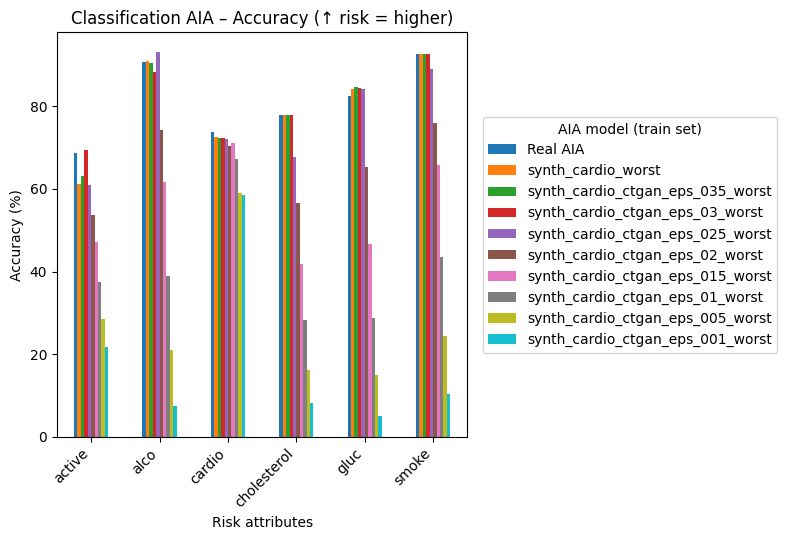

Saved: aia_cls_accuracy.png


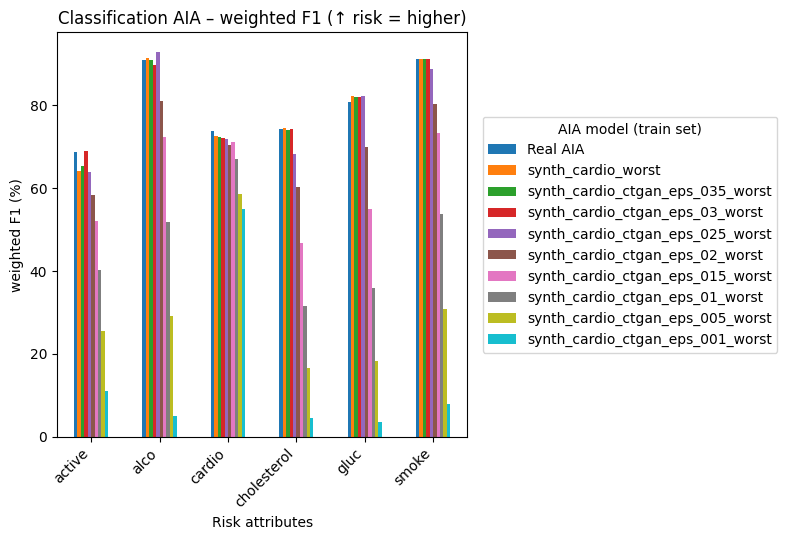

Saved: aia_cls_weighted_f1.png


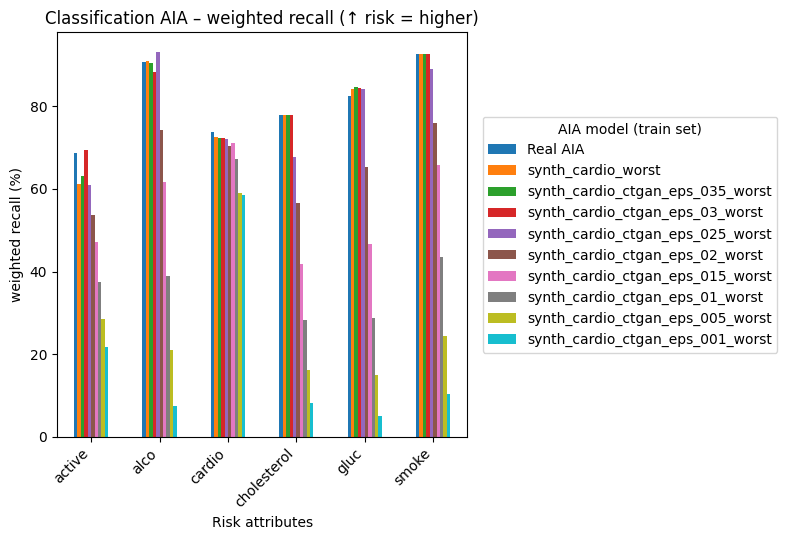

Saved: aia_cls_weighted_recall.png


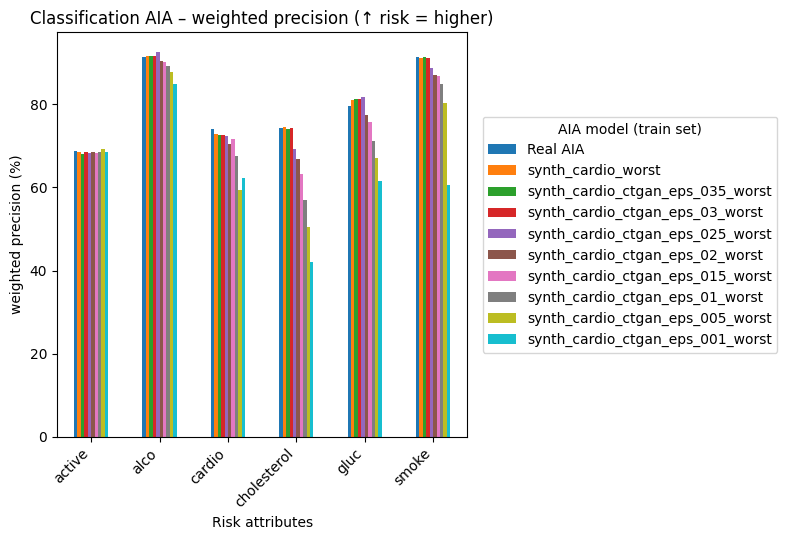

Saved: aia_cls_weighted_precision.png


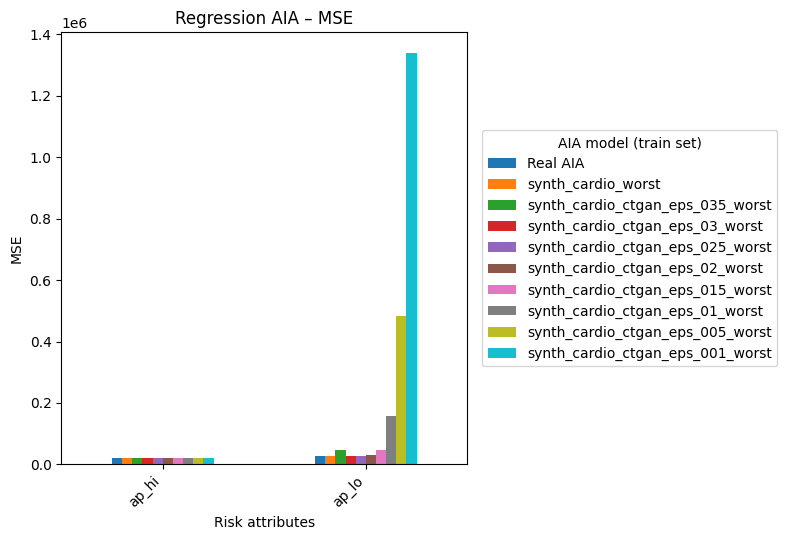

Saved: aia_reg_mse.png


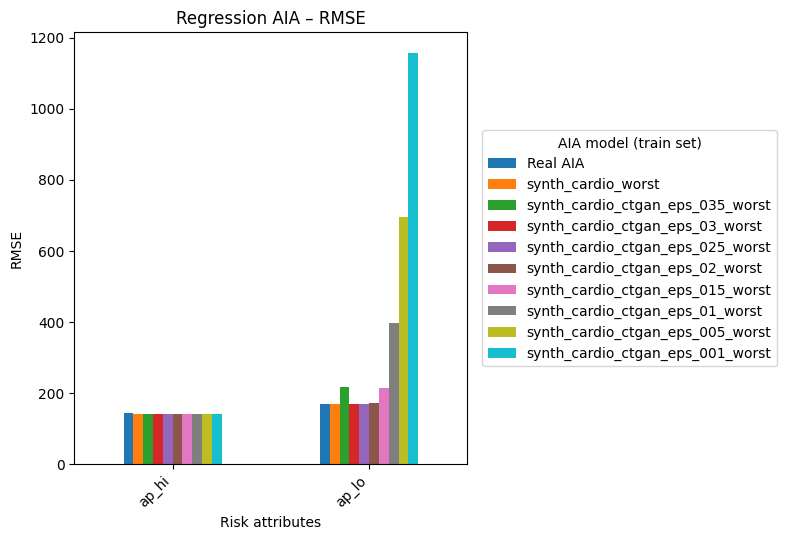

Saved: aia_reg_rmse.png


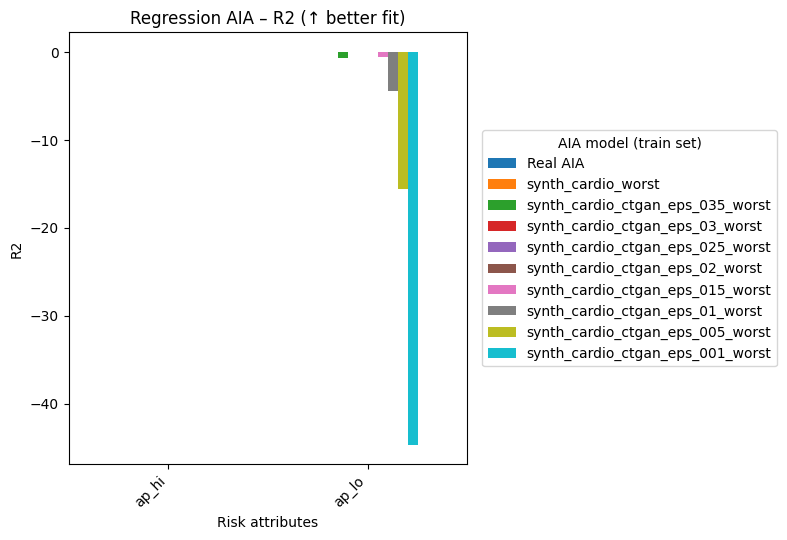

Saved: aia_reg_r2.png


In [15]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_cardio_worst.pkl", 'rb') as file:
    real_cardio_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_cardio_worst.pkl", 'rb') as file:
    synth_cardio_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_035_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_035_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_03_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_03_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_025_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_025_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_02_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_02_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_015_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_015_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_01_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_01_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_005_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_005_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_001_worst.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_001_worst = pickle.load(file)

synth = cardio_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_cardio)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_cardio_train, synth, df_real_cardio_test, None, cardio_risk_column, "none")

synth_data_list = [
    synth_cardio_worst, 
    synth_cardio_ctgan_eps_035_worst,
    synth_cardio_ctgan_eps_03_worst,
    synth_cardio_ctgan_eps_025_worst,
    synth_cardio_ctgan_eps_02_worst,
    synth_cardio_ctgan_eps_015_worst,
    synth_cardio_ctgan_eps_01_worst,
    synth_cardio_ctgan_eps_005_worst,
    synth_cardio_ctgan_eps_001_worst]

synth_data_name_list = [
    'synth_cardio_worst', 
    'synth_cardio_ctgan_eps_035_worst',
    'synth_cardio_ctgan_eps_03_worst',
    'synth_cardio_ctgan_eps_025_worst',
    'synth_cardio_ctgan_eps_02_worst',
    'synth_cardio_ctgan_eps_015_worst',
    'synth_cardio_ctgan_eps_01_worst',
    'synth_cardio_ctgan_eps_005_worst',
    'synth_cardio_ctgan_eps_001_worst']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_cardio_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


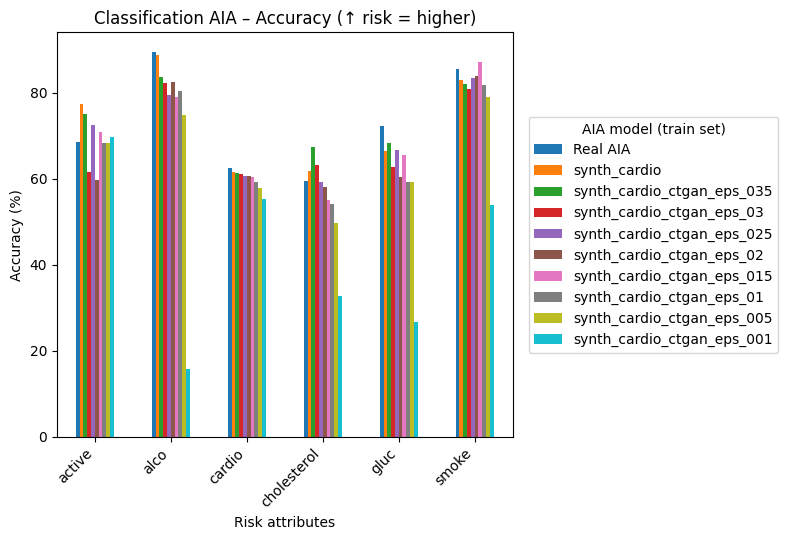

Saved: aia_cls_accuracy.png


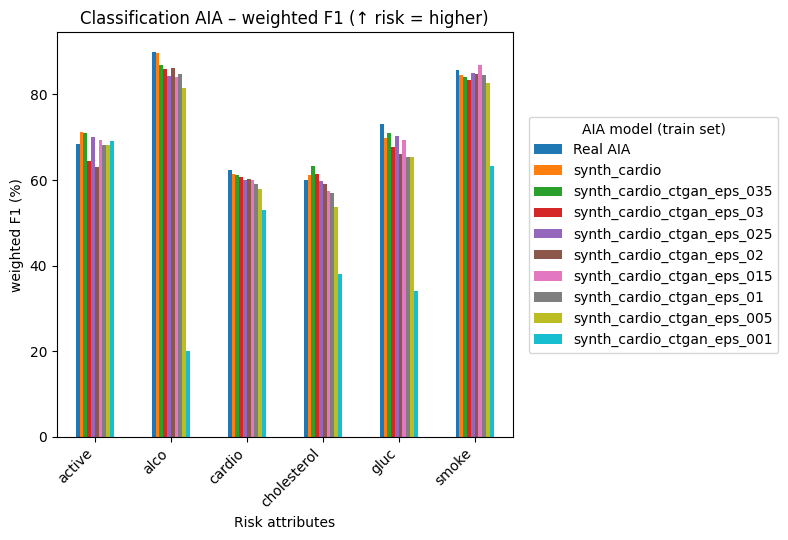

Saved: aia_cls_weighted_f1.png


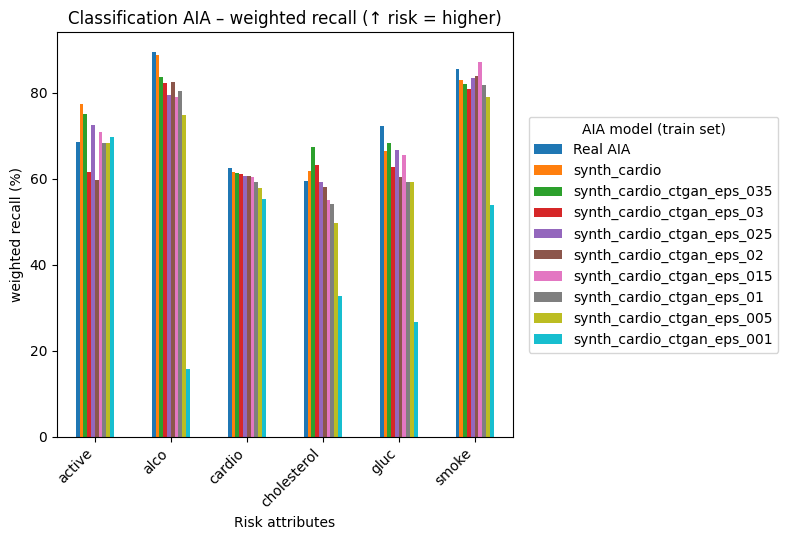

Saved: aia_cls_weighted_recall.png


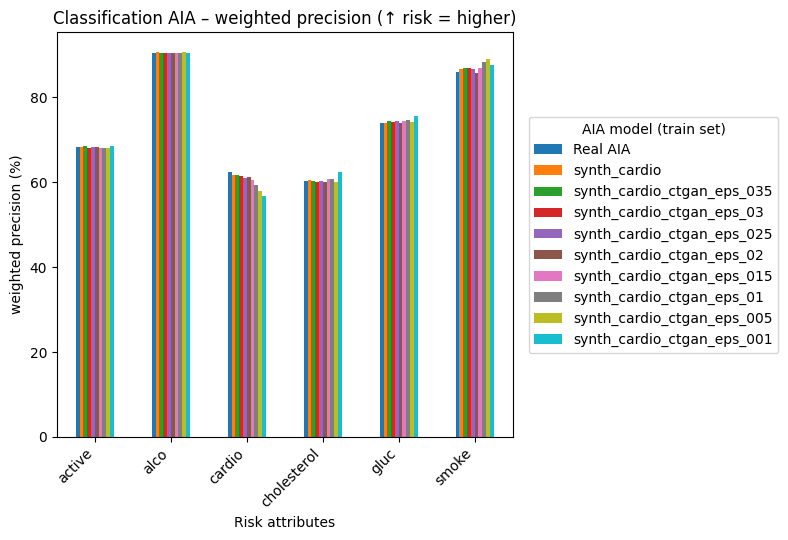

Saved: aia_cls_weighted_precision.png


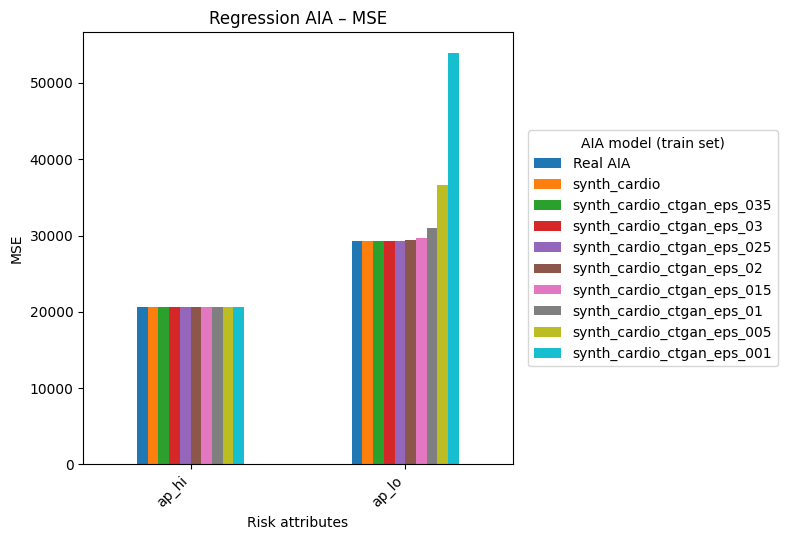

Saved: aia_reg_mse.png


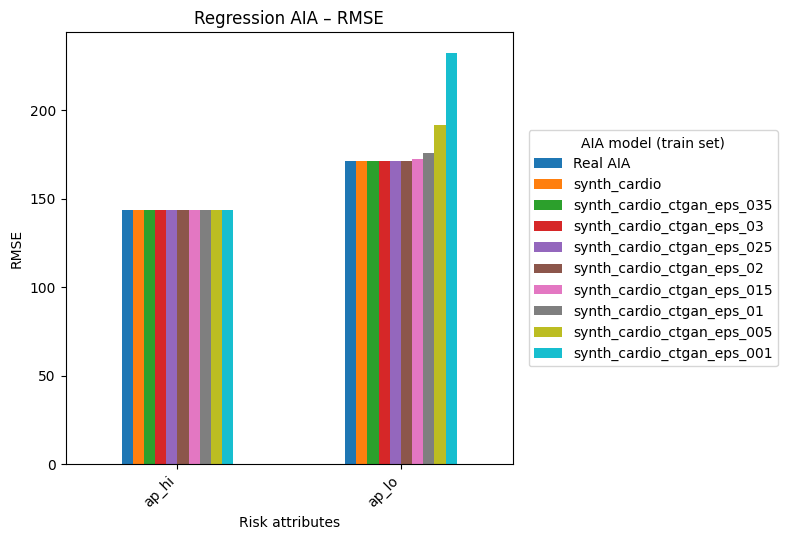

Saved: aia_reg_rmse.png


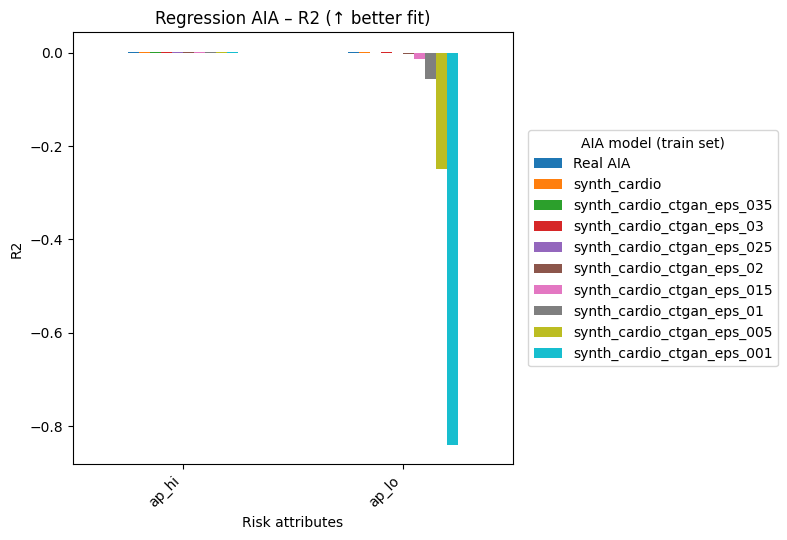

Saved: aia_reg_r2.png


In [12]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_cardio_qai.pkl", 'rb') as file:
    real_cardio = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_cardio_qai.pkl", 'rb') as file:
    synth_cardio = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_035.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_035 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_03.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_03 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_025.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_025 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_02.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_02 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_015.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_015 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_01.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_01 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_005.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_005 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_cardio_cardio_ctgan_eps_001.pkl", 'rb') as file:
    synth_cardio_ctgan_eps_001 = pickle.load(file)

synth = cardio_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_cardio)  
privacy_evaluator_synth = PrivacyEvaluator(df_real_cardio_train, synth, df_real_cardio_test, None, cardio_risk_column, "none")

synth_data_list = [
    synth_cardio, 
    synth_cardio_ctgan_eps_035,
    synth_cardio_ctgan_eps_03,
    synth_cardio_ctgan_eps_025,
    synth_cardio_ctgan_eps_02,
    synth_cardio_ctgan_eps_015,
    synth_cardio_ctgan_eps_01,
    synth_cardio_ctgan_eps_005,
    synth_cardio_ctgan_eps_001]

synth_data_name_list = [
    'synth_cardio', 
    'synth_cardio_ctgan_eps_035',
    'synth_cardio_ctgan_eps_03',
    'synth_cardio_ctgan_eps_025',
    'synth_cardio_ctgan_eps_02',
    'synth_cardio_ctgan_eps_015',
    'synth_cardio_ctgan_eps_01',
    'synth_cardio_ctgan_eps_005',
    'synth_cardio_ctgan_eps_001']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_synth,
    real_cardio,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


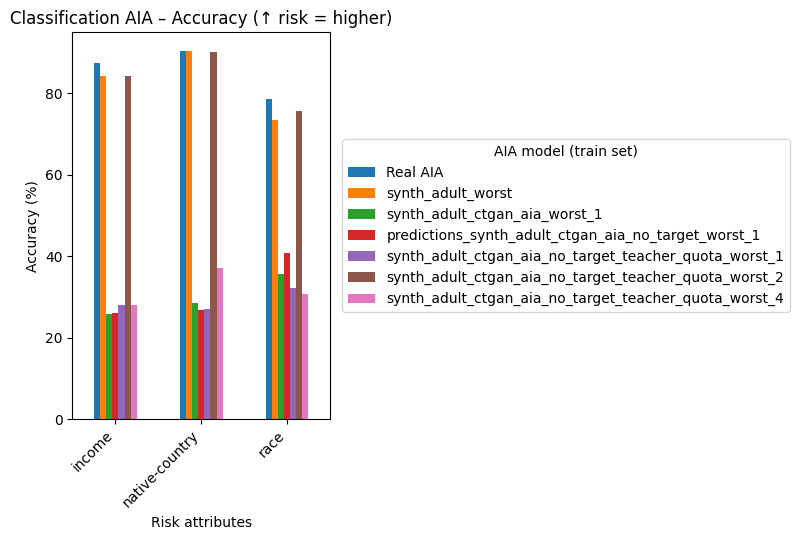

Saved: aia_cls_accuracy.png


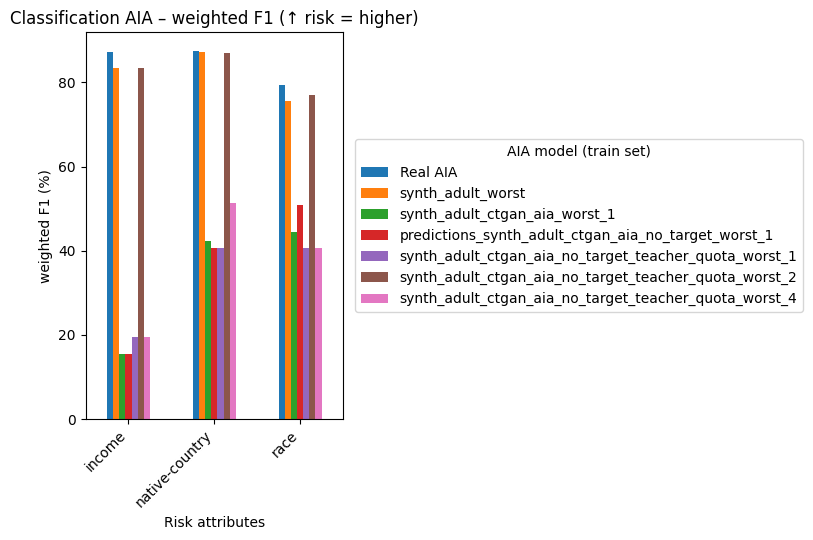

Saved: aia_cls_weighted_f1.png


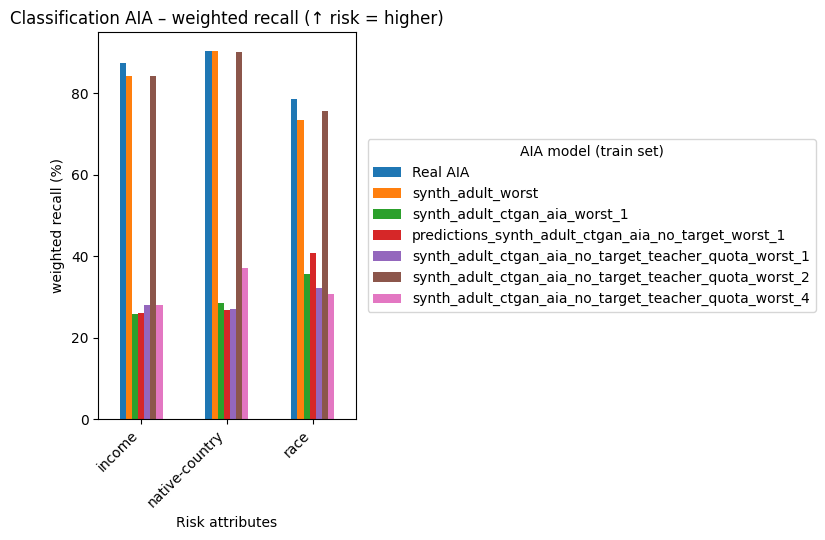

Saved: aia_cls_weighted_recall.png


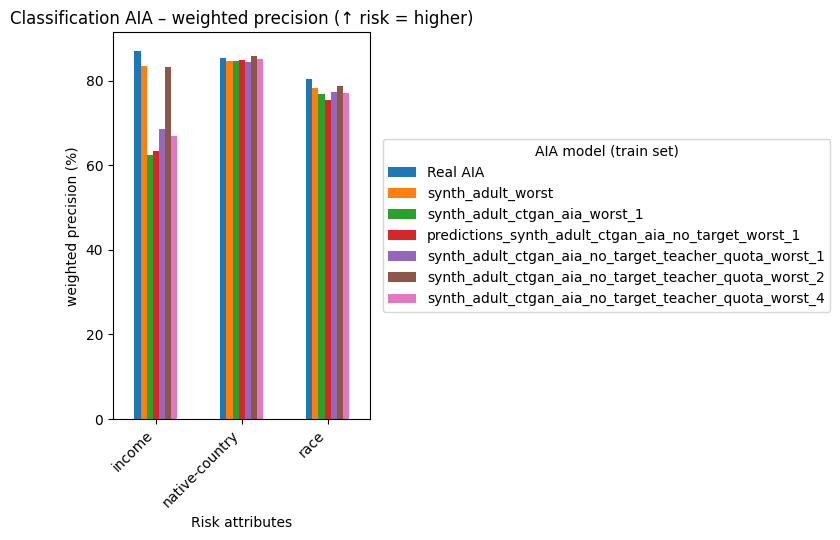

Saved: aia_cls_weighted_precision.png


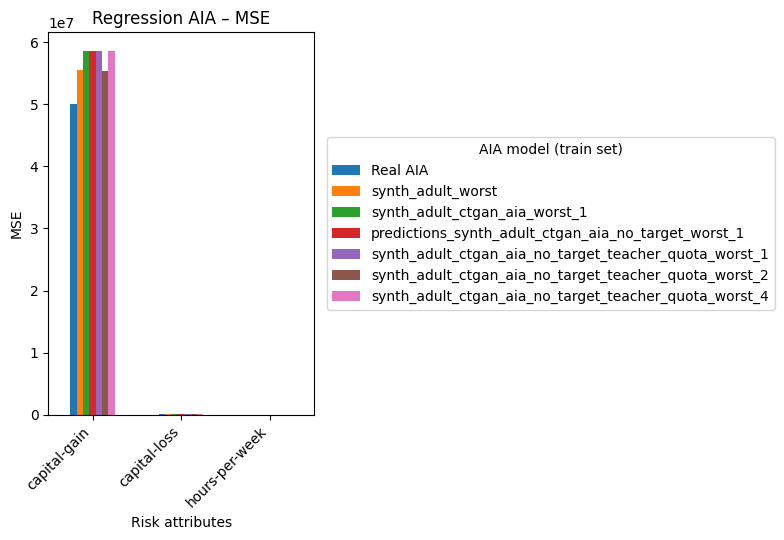

Saved: aia_reg_mse.png


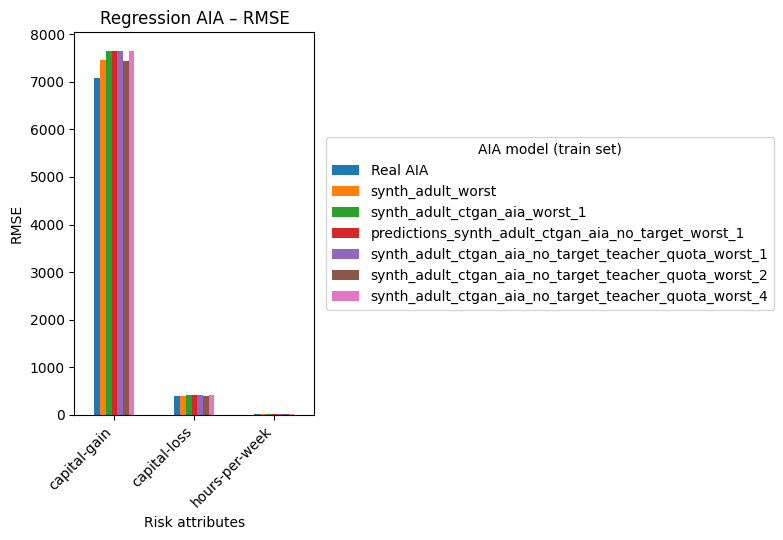

Saved: aia_reg_rmse.png


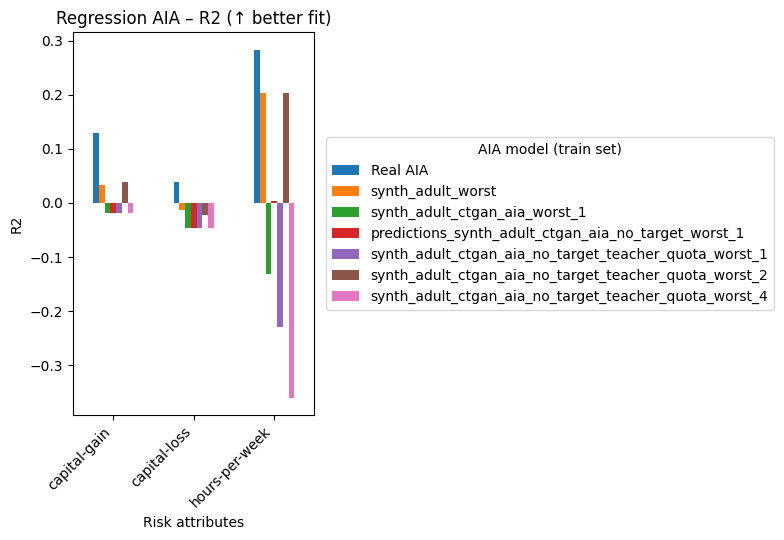

Saved: aia_reg_r2.png


In [ ]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_worst.pkl", 'rb') as file:
    real_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_worst.pkl", 'rb') as file:
    synth_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_worst_1.pkl", 'rb') as file:
    synth_adult_ctgan_aia_worst_1 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_teacher_quota_worst_1.pkl", 'rb') as file:
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_1 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_teacher_quota_worst_2.pkl", 'rb') as file:
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_2 = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_teacher_quota_worst_2_last.pkl", 'rb') as file:
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_2_last = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_teacher_quota_worst_4.pkl", 'rb') as file:
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_4 = pickle.load(file)


with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_worst_1.pkl", 'rb') as file:
    predictions_synth_adult_ctgan_aia_no_target_worst_1 = pickle.load(file)
synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_worst, 
    predictions_synth_adult_ctgan_aia_no_target_worst_1,
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_1,
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_2,
    synth_adult_ctgan_aia_no_target_teacher_quota_worst_4]

synth_data_name_list = [
    'synth_adult_worst', 
    'synth_adult_ctgan_aia_worst_1',
    'synth_adult_ctgan_aia_no_target_teacher_quota_worst_1',
    # 'synth_adult_ctgan_aia_no_target_teacher_quota_worst_2',
    'synth_adult_ctgan_aia_no_target_teacher_quota_worst_4']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_adult_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


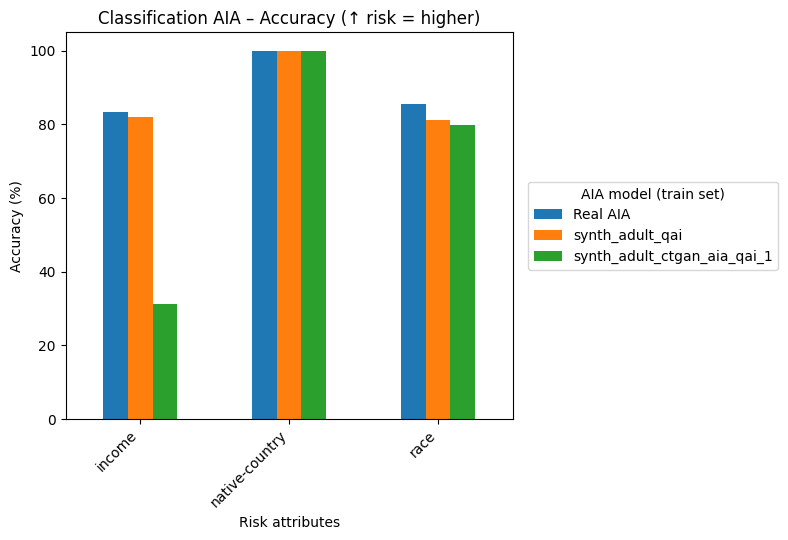

Saved: aia_cls_accuracy.png


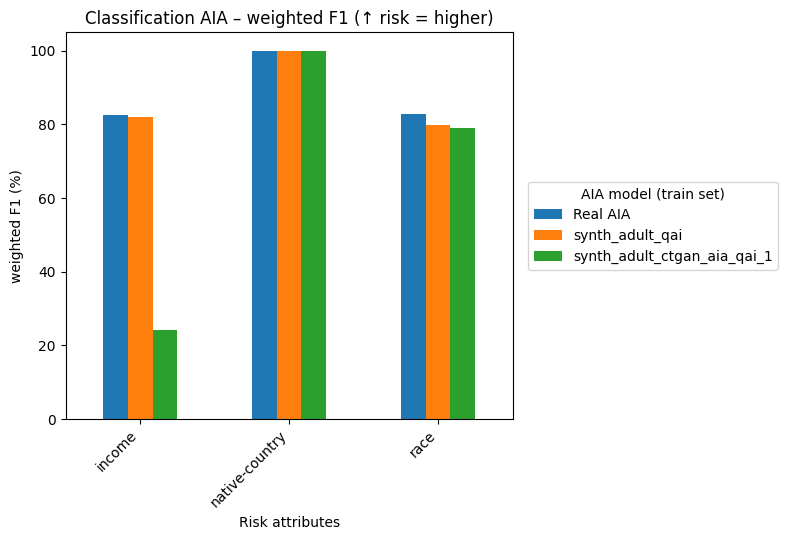

Saved: aia_cls_weighted_f1.png


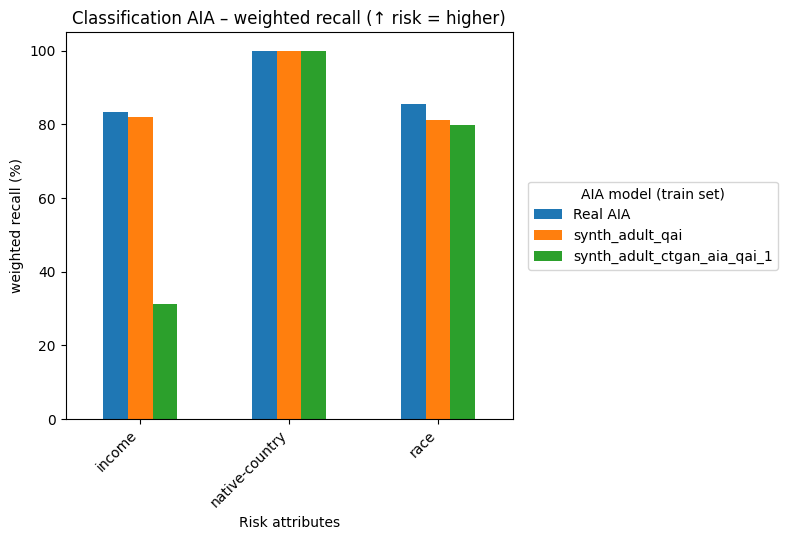

Saved: aia_cls_weighted_recall.png


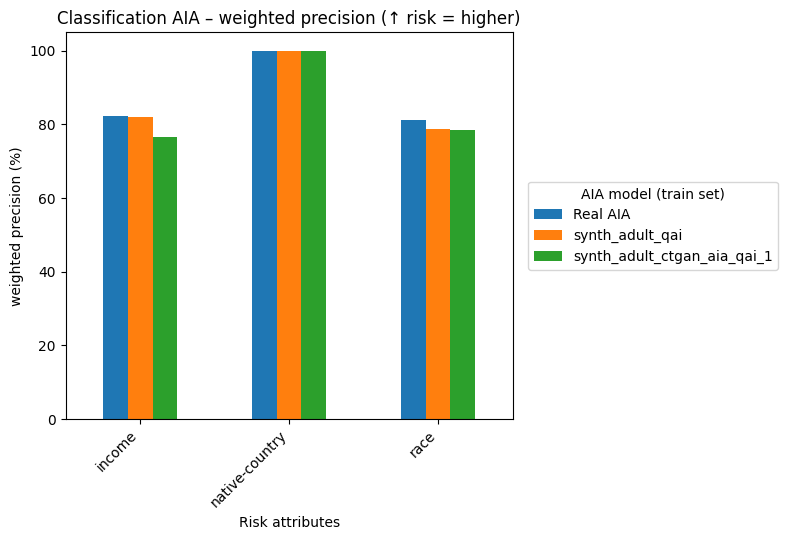

Saved: aia_cls_weighted_precision.png


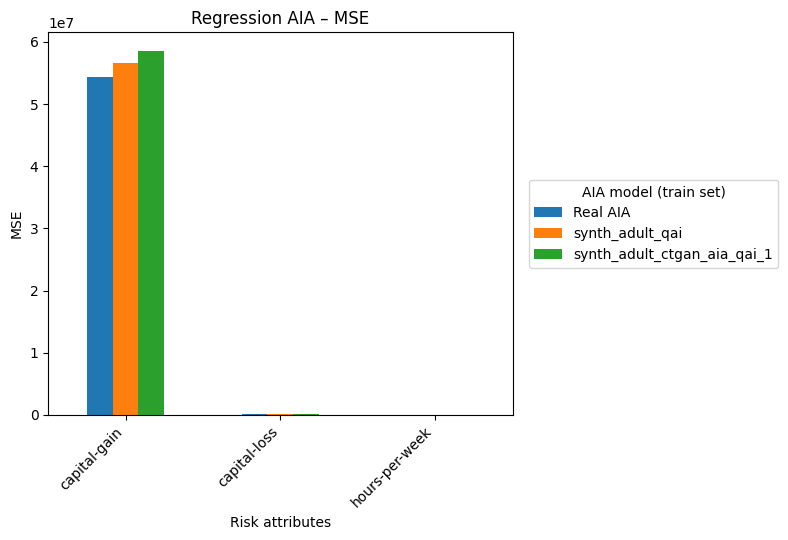

Saved: aia_reg_mse.png


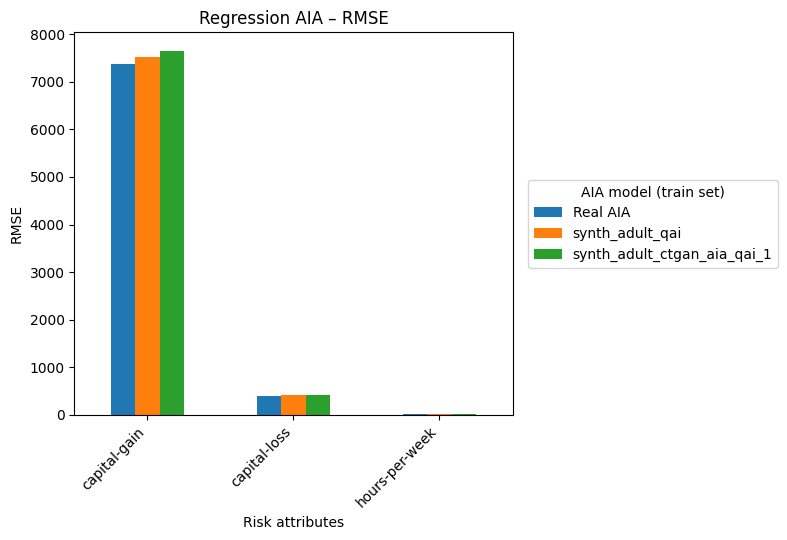

Saved: aia_reg_rmse.png


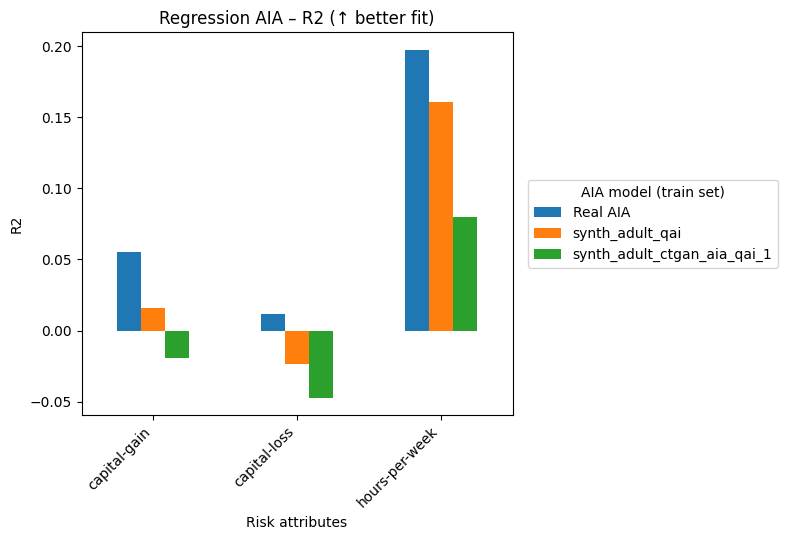

Saved: aia_reg_r2.png


In [15]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_qai.pkl", 'rb') as file:
    real_adult_qai = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_qai.pkl", 'rb') as file:
    synth_adult_qai = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_qai_1.pkl", 'rb') as file:
    synth_adult_ctgan_aia_qai_1 = pickle.load(file)
# predictions_synth_adult_ctgan_aia_qai_1
# with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_qai_1.pkl", 'rb') as file:
#     predictions_synth_adult_ctgan_aia_no_target_qai_1 = pickle.load(file)
# synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_qai_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_qai, 
    synth_adult_ctgan_aia_qai_1,]

synth_data_name_list = [
    'synth_adult_qai', 
    'synth_adult_ctgan_aia_qai_1']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_qai_synth,
    real_adult_qai,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


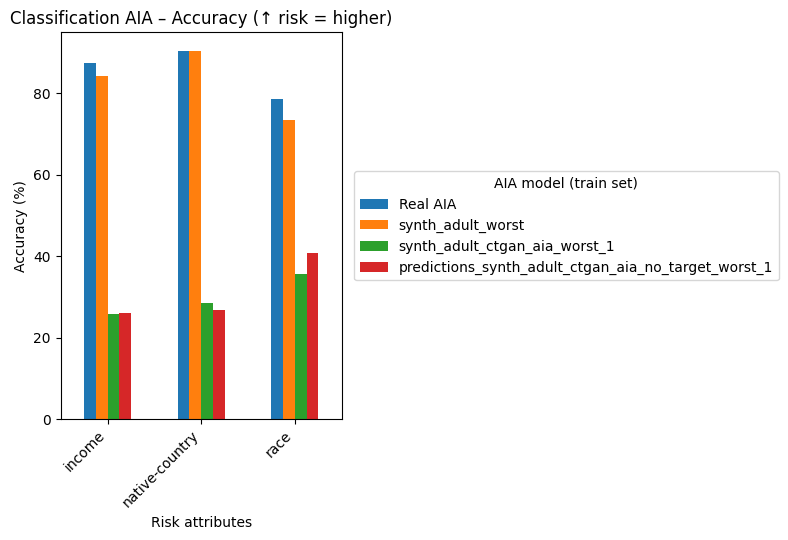

Saved: aia_cls_accuracy.png


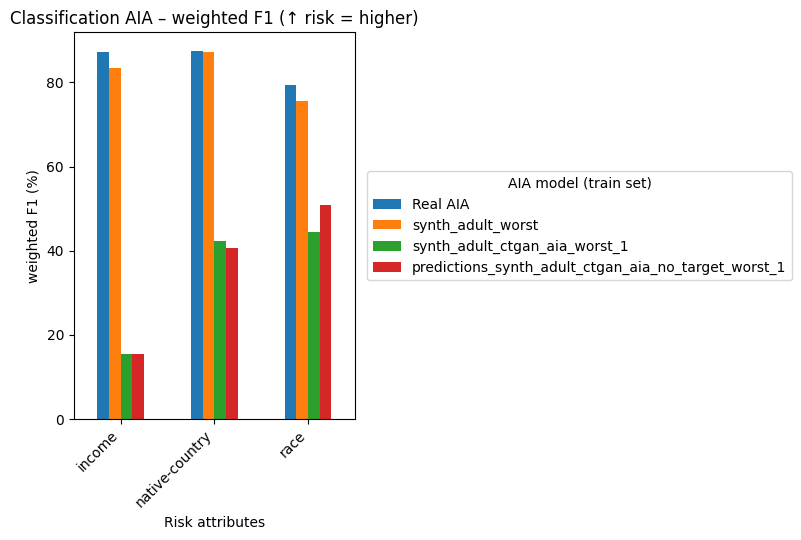

Saved: aia_cls_weighted_f1.png


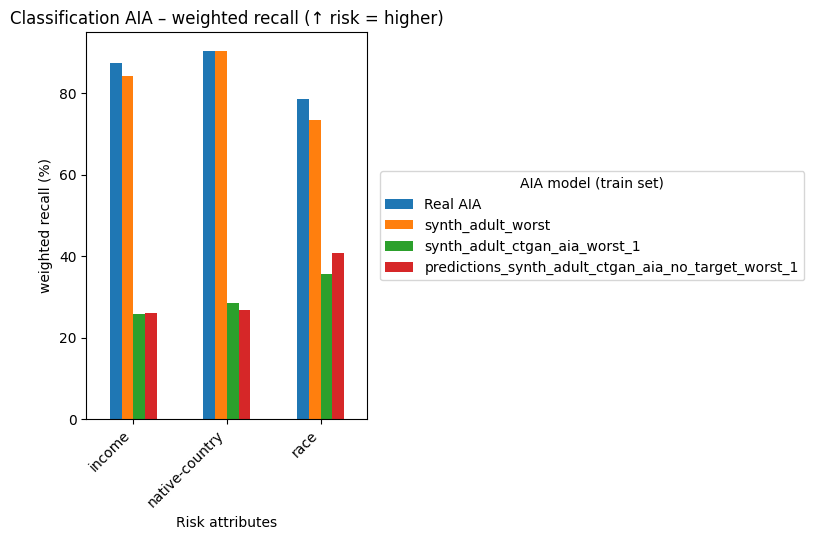

Saved: aia_cls_weighted_recall.png


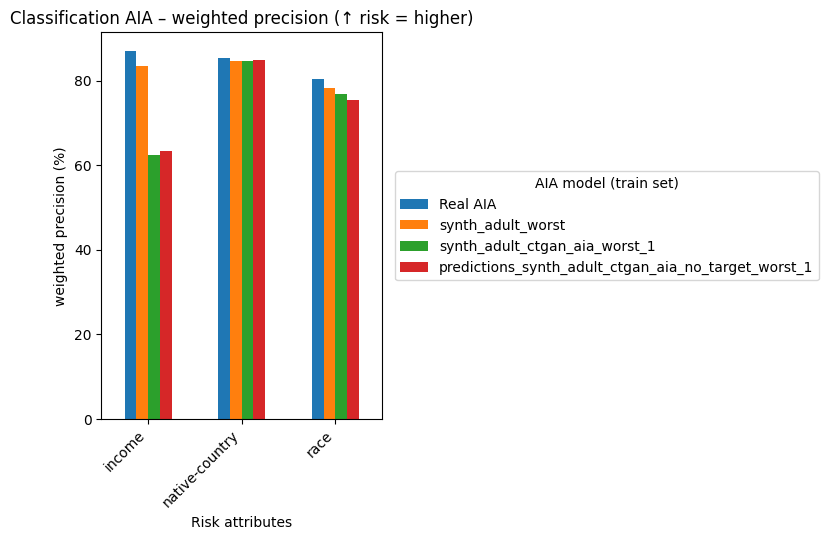

Saved: aia_cls_weighted_precision.png


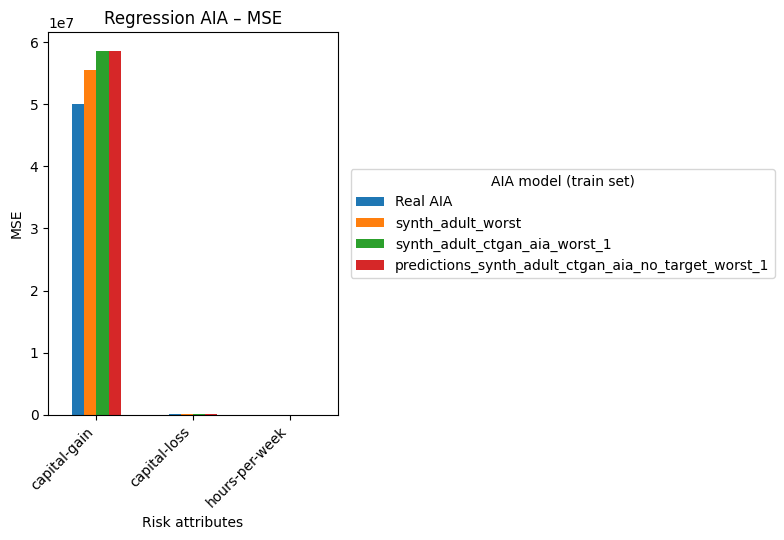

Saved: aia_reg_mse.png


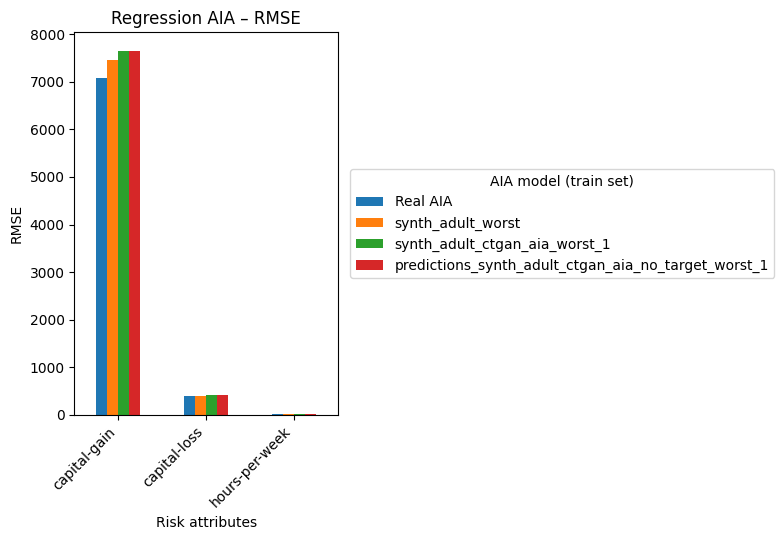

Saved: aia_reg_rmse.png


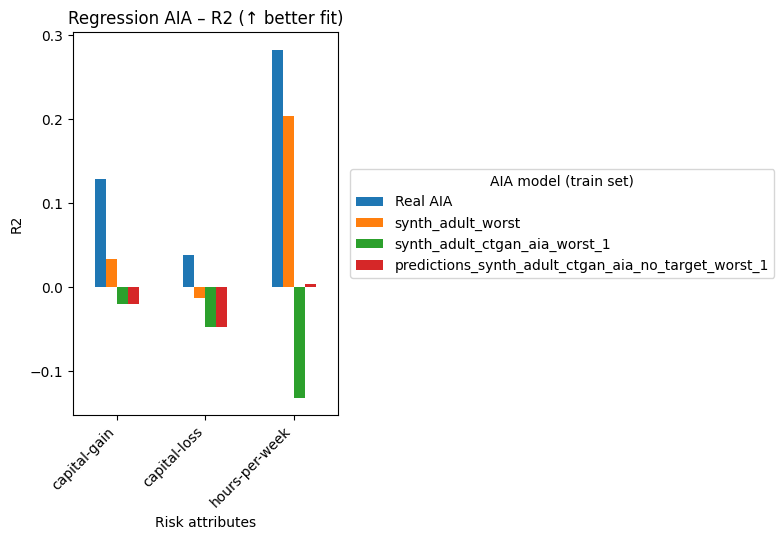

Saved: aia_reg_r2.png


In [30]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_worst.pkl", 'rb') as file:
    real_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_worst.pkl", 'rb') as file:
    synth_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_worst_1.pkl", 'rb') as file:
    synth_adult_ctgan_aia_worst_1 = pickle.load(file)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_ctgan_aia_no_target_worst_1.pkl", 'rb') as file:
    predictions_synth_adult_ctgan_aia_no_target_worst_1 = pickle.load(file)
synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_worst, 
    synth_adult_ctgan_aia_worst_1,
    predictions_synth_adult_ctgan_aia_no_target_worst_1]

synth_data_name_list = [
    'synth_adult_worst', 
    'synth_adult_ctgan_aia_worst_1',
    'predictions_synth_adult_ctgan_aia_no_target_worst_1']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_adult_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


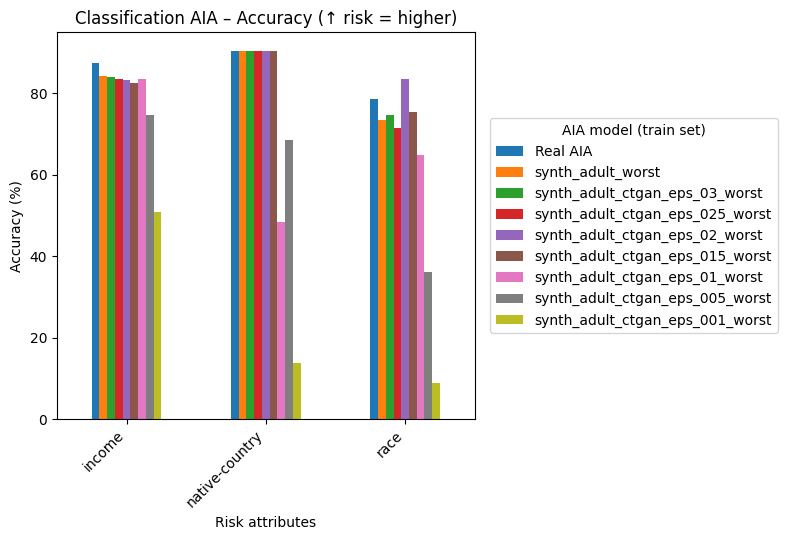

Saved: aia_cls_accuracy.png


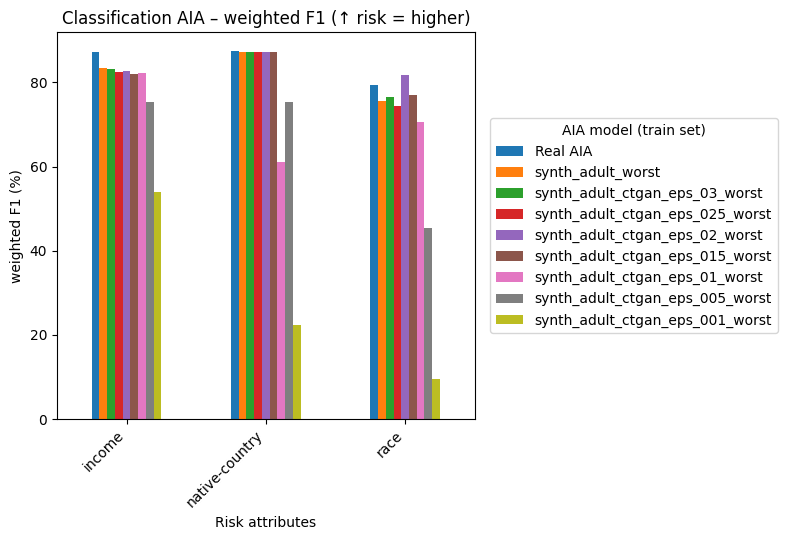

Saved: aia_cls_weighted_f1.png


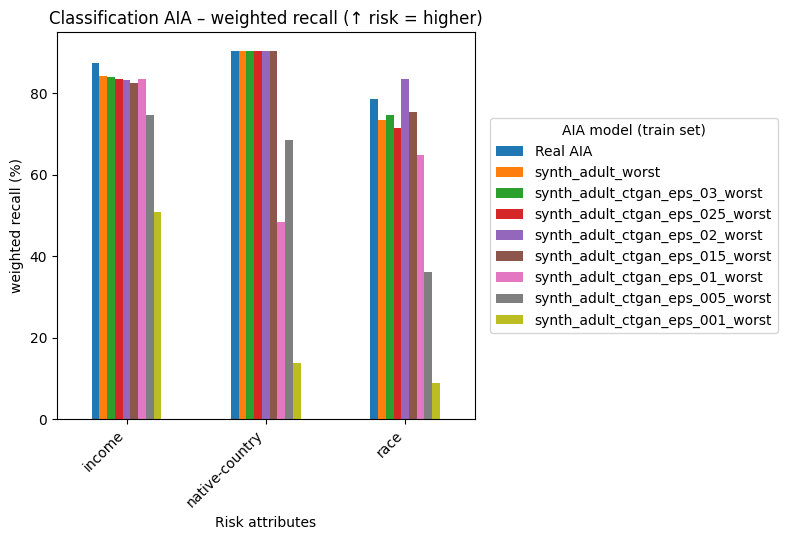

Saved: aia_cls_weighted_recall.png


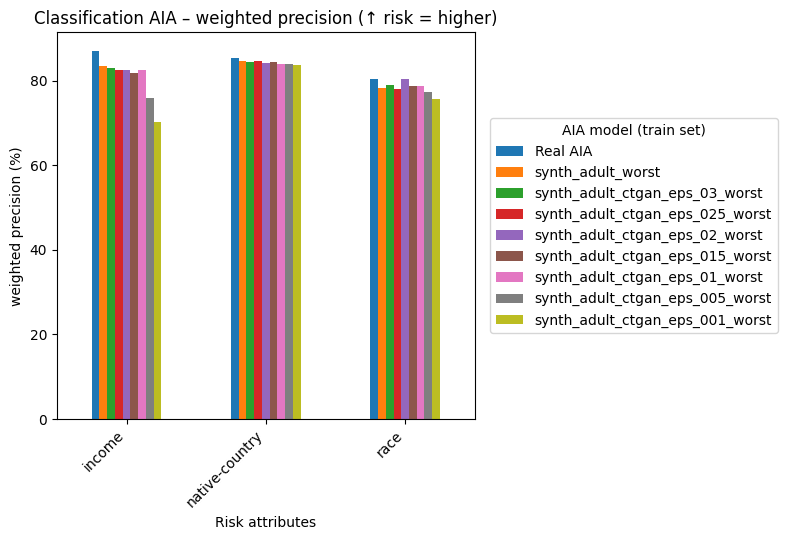

Saved: aia_cls_weighted_precision.png


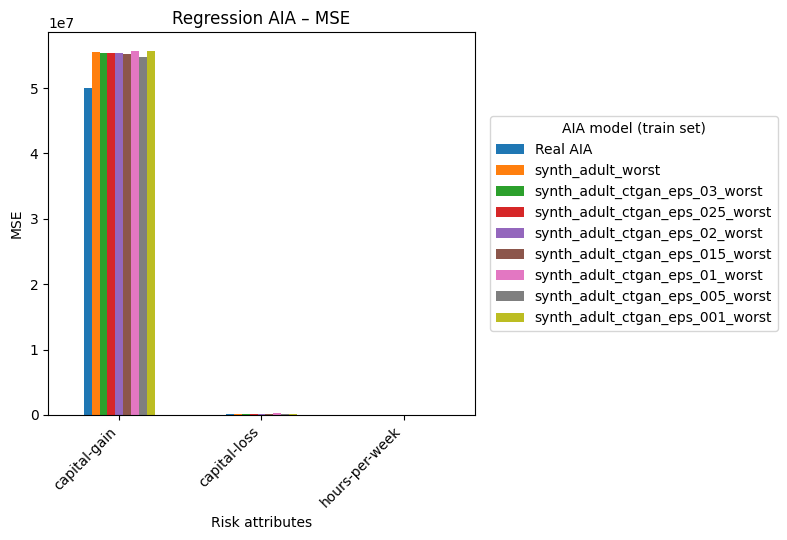

Saved: aia_reg_mse.png


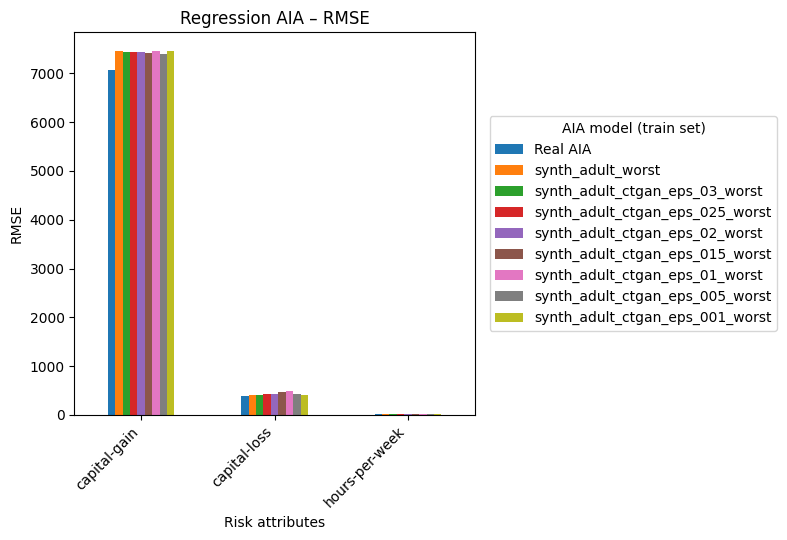

Saved: aia_reg_rmse.png


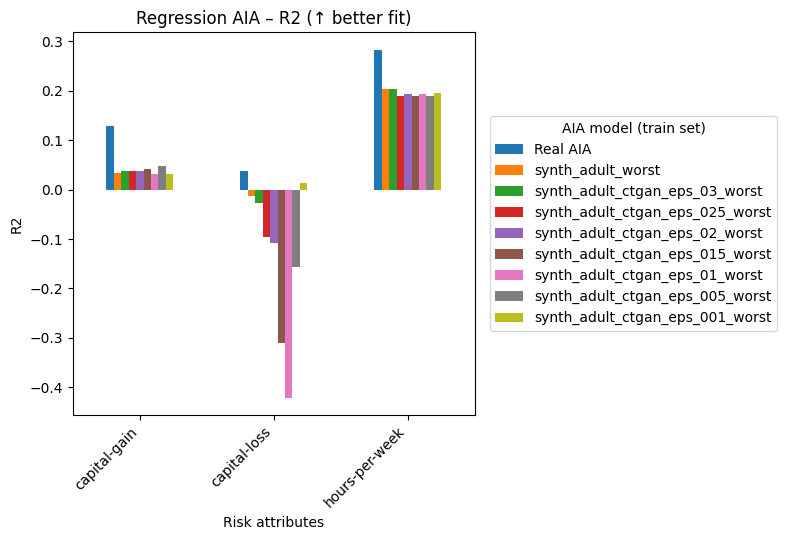

Saved: aia_reg_r2.png


In [ ]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_worst.pkl", 'rb') as file:
    real_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_worst.pkl", 'rb') as file:
    synth_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_03_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_03_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_025_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_025_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_02_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_02_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_015_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_015_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_01_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_01_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_005_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_005_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_adult_ctgan_eps_001_worst.pkl", 'rb') as file:
    synth_adult_ctgan_eps_001_worst = pickle.load(file)
synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_worst, 
    synth_adult_ctgan_eps_03_worst,
    synth_adult_ctgan_eps_025_worst,
    synth_adult_ctgan_eps_02_worst,
    synth_adult_ctgan_eps_015_worst,
    synth_adult_ctgan_eps_01_worst,
    synth_adult_ctgan_eps_005_worst,
    synth_adult_ctgan_eps_001_worst]

synth_data_name_list = [
    'synth_adult_worst', 
    'synth_adult_ctgan_eps_03_worst',
    'synth_adult_ctgan_eps_025_worst',
    'synth_adult_ctgan_eps_02_worst',
    'synth_adult_ctgan_eps_015_worst',
    'synth_adult_ctgan_eps_01_worst',
    'synth_adult_ctgan_eps_005_worst',
    'synth_adult_ctgan_eps_001_worst']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_adult_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


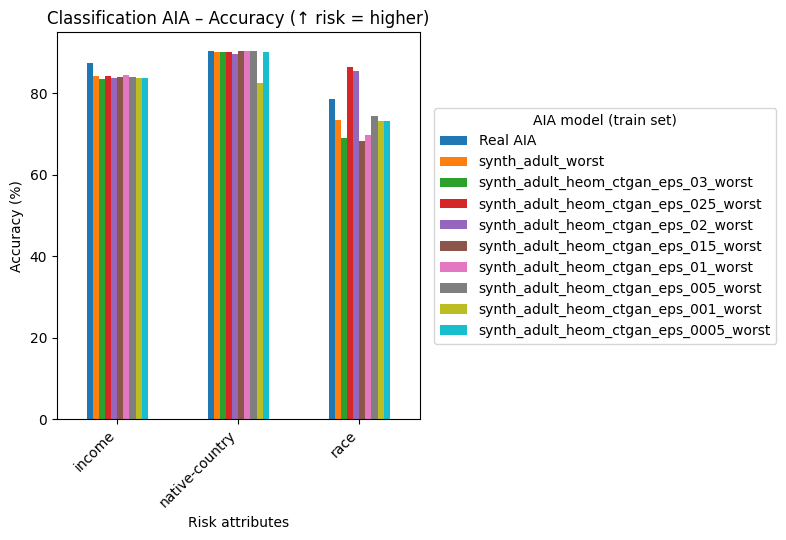

Saved: aia_cls_accuracy.png


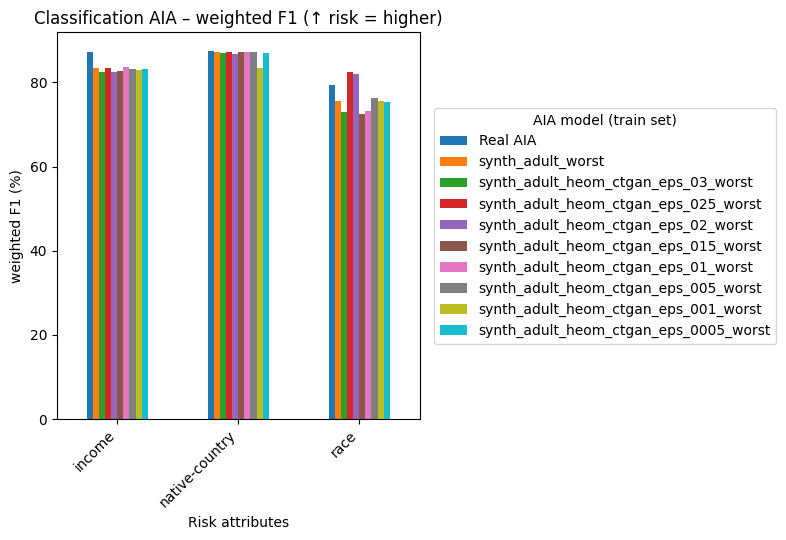

Saved: aia_cls_weighted_f1.png


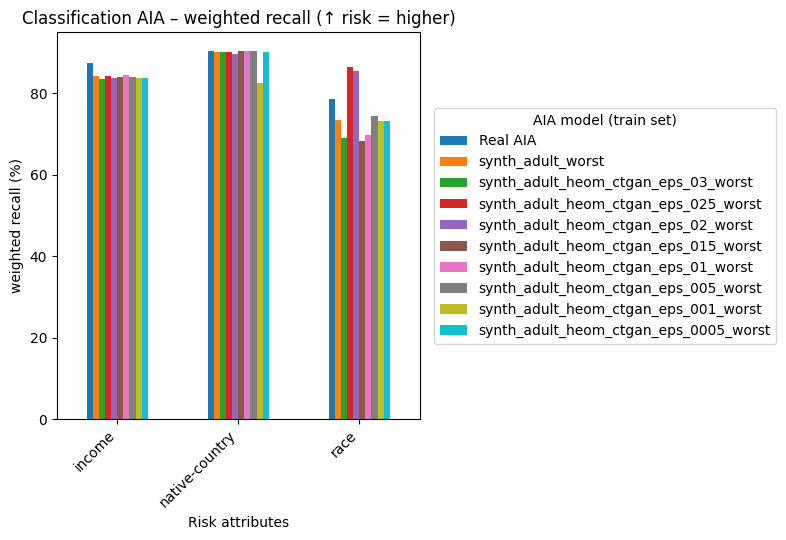

Saved: aia_cls_weighted_recall.png


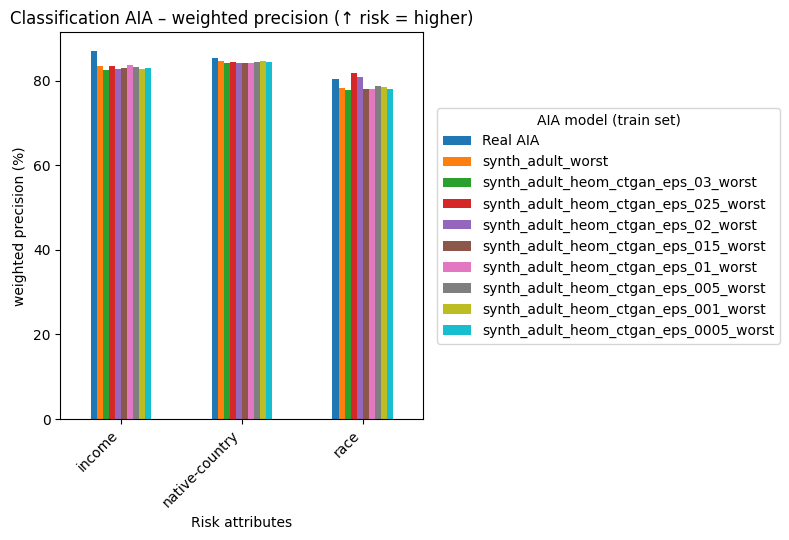

Saved: aia_cls_weighted_precision.png


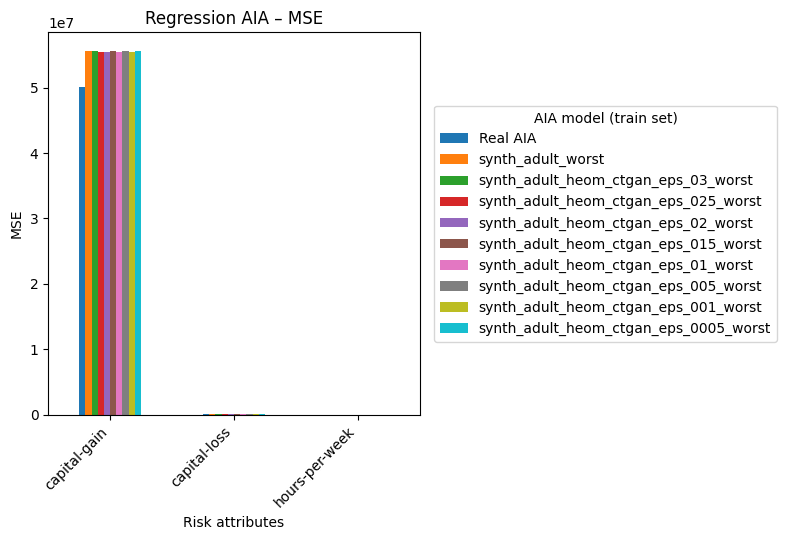

Saved: aia_reg_mse.png


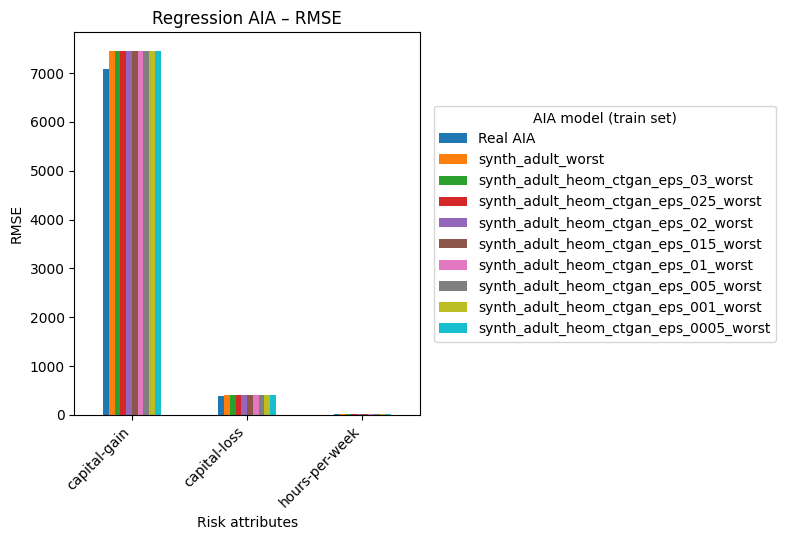

Saved: aia_reg_rmse.png


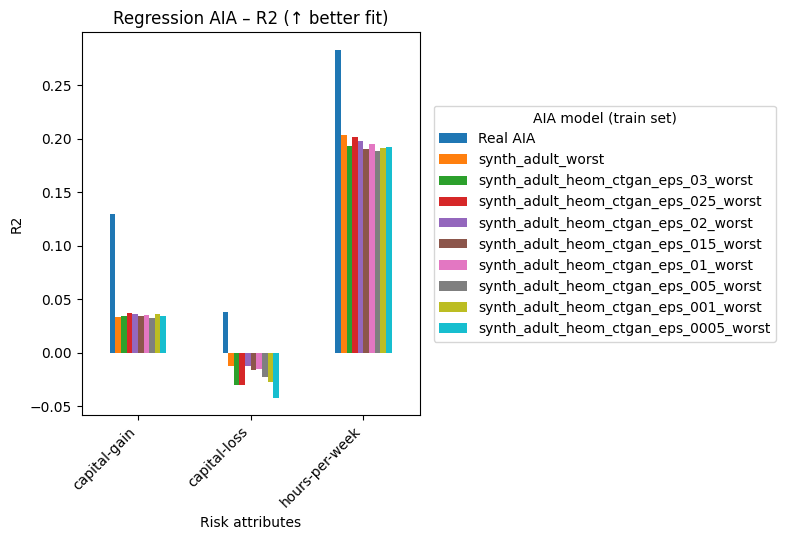

Saved: aia_reg_r2.png


In [24]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_worst.pkl", 'rb') as file:
    real_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_worst.pkl", 'rb') as file:
    synth_adult_worst = pickle.load(file)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_0005_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_0005_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_001_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_001_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_005_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_005_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_01_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_01_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_015_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_015_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_02_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_02_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_025_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_025_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_adult_ctgan_eps_03_worst.pkl", 'rb') as file:
    synth_adult_heom_ctgan_eps_03_worst = pickle.load(file)

synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_worst, 
    synth_adult_heom_ctgan_eps_03_worst,
    synth_adult_heom_ctgan_eps_025_worst,
    synth_adult_heom_ctgan_eps_02_worst,
    synth_adult_heom_ctgan_eps_015_worst,
    synth_adult_heom_ctgan_eps_01_worst,
    synth_adult_heom_ctgan_eps_005_worst,
    synth_adult_heom_ctgan_eps_001_worst,
    synth_adult_heom_ctgan_eps_0005_worst]

synth_data_name_list = [
    'synth_adult_worst', 
    'synth_adult_heom_ctgan_eps_03_worst',
    'synth_adult_heom_ctgan_eps_025_worst',
    'synth_adult_heom_ctgan_eps_02_worst',
    'synth_adult_heom_ctgan_eps_015_worst',
    'synth_adult_heom_ctgan_eps_01_worst',
    'synth_adult_heom_ctgan_eps_005_worst',
    'synth_adult_heom_ctgan_eps_001_worst',
    'synth_adult_heom_ctgan_eps_0005_worst']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_adult_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


actual self._dedup_policy : DedupPolicy.NONE


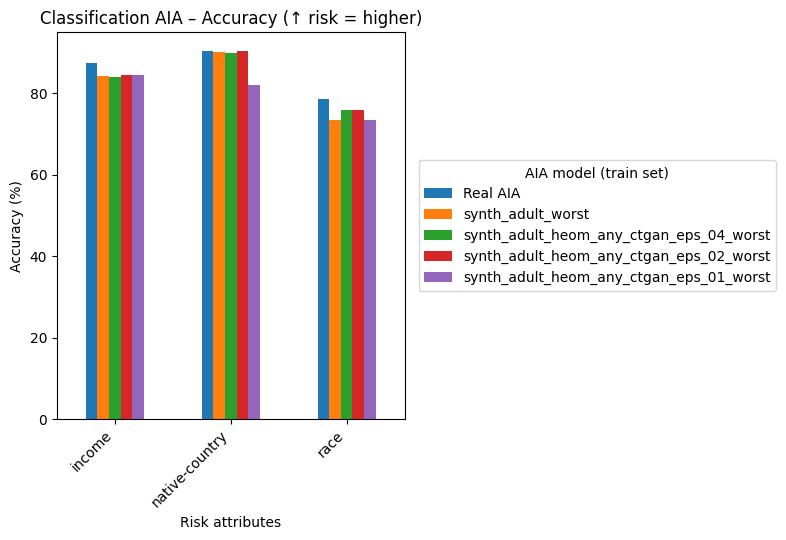

Saved: aia_cls_accuracy.png


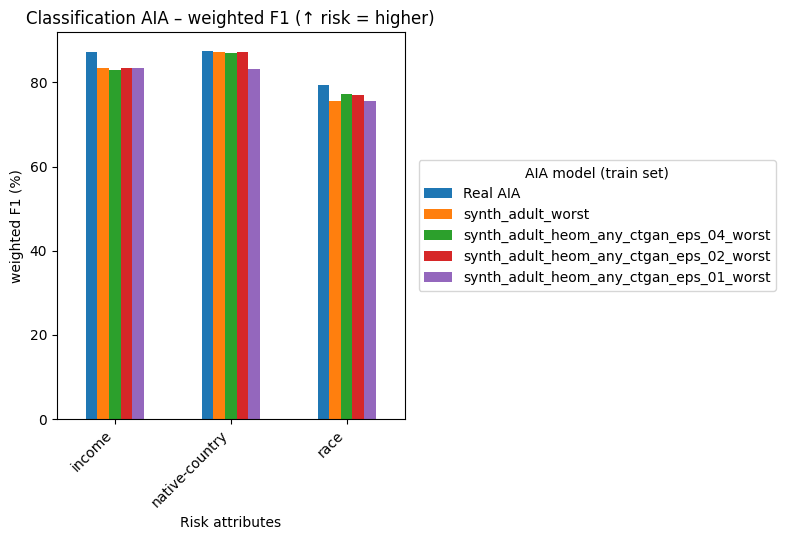

Saved: aia_cls_weighted_f1.png


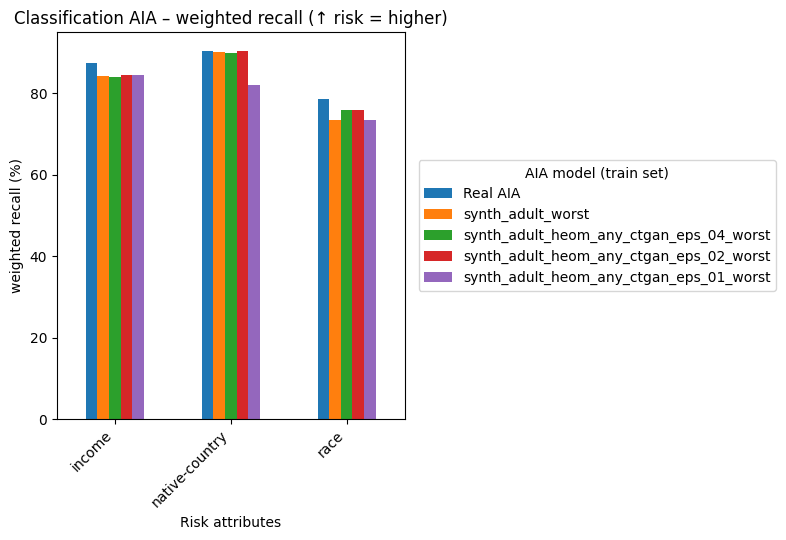

Saved: aia_cls_weighted_recall.png


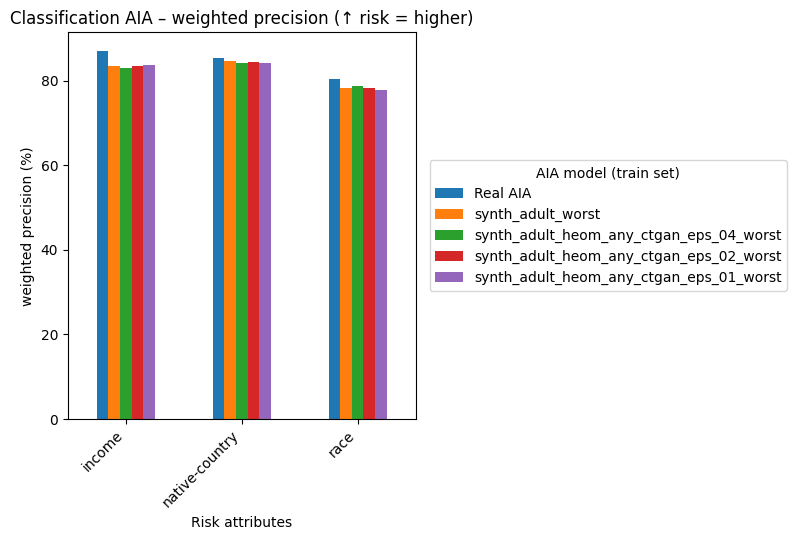

Saved: aia_cls_weighted_precision.png


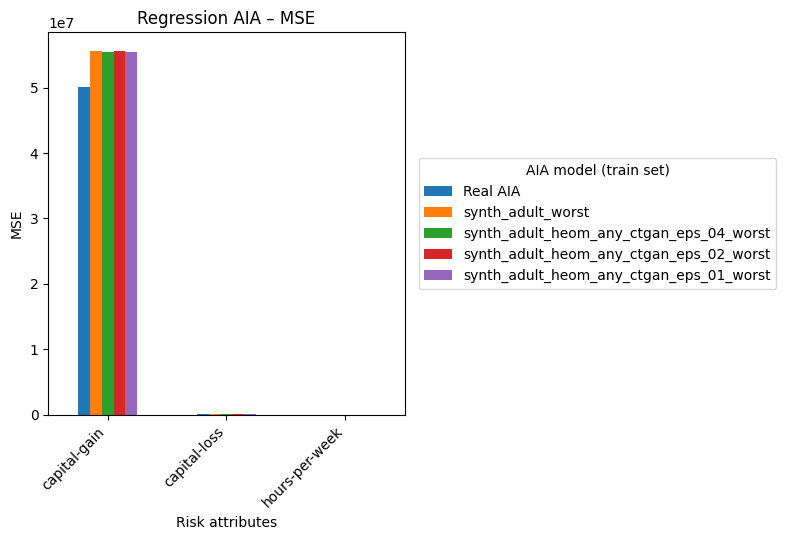

Saved: aia_reg_mse.png


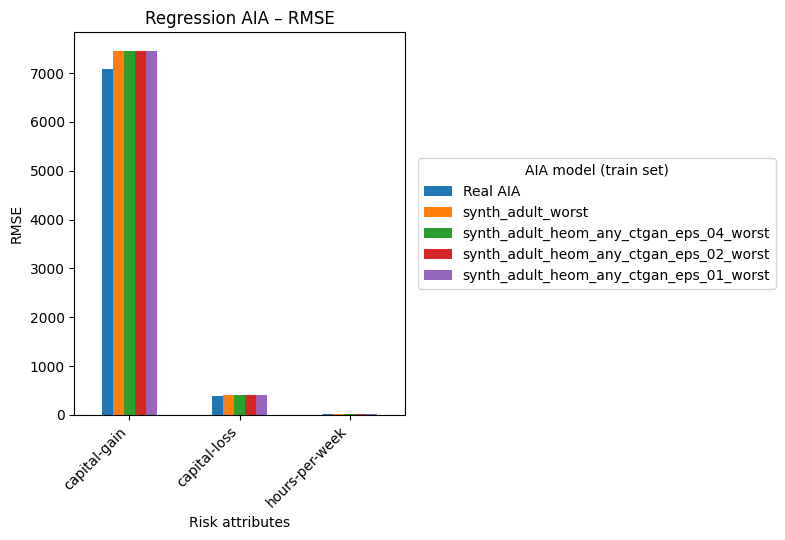

Saved: aia_reg_rmse.png


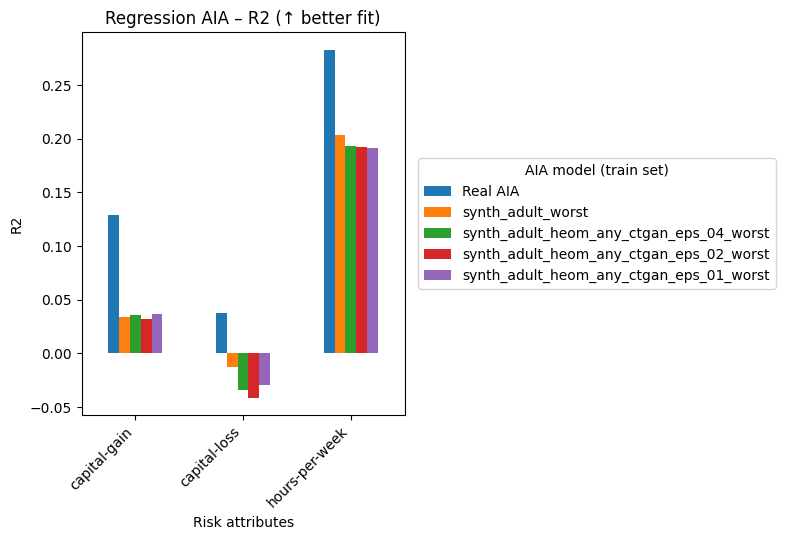

Saved: aia_reg_r2.png


In [17]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

df_real_adult_train = DataLoader('../../data/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader('../../data/adult_test.csv').get_dataframe(cat_list_adult)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_adult_worst.pkl", 'rb') as file:
    real_adult_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_adult_worst.pkl", 'rb') as file:
    synth_adult_worst = pickle.load(file)

with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_04_worst.pkl", 'rb') as file:
    synth_adult_heom_any_ctgan_eps_04_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_02_worst.pkl", 'rb') as file:
    synth_adult_heom_any_ctgan_eps_02_worst = pickle.load(file)
with open("../scripts/privacy_evaluation_withno_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_01_worst.pkl", 'rb') as file:
    synth_adult_heom_any_ctgan_eps_01_worst = pickle.load(file)

synth = adult_ctgan["generation_results"]["synthetic_data"]
synth = DataLoader(dataset=synth).get_dataframe(cat_list_adult)  
privacy_evaluator_worst_synth = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, None, adult_risk_column, "none")

synth_data_list = [
    synth_adult_worst, 
    synth_adult_heom_any_ctgan_eps_04_worst,
    synth_adult_heom_any_ctgan_eps_02_worst,
    synth_adult_heom_any_ctgan_eps_01_worst]

synth_data_name_list = [
    'synth_adult_worst', 
    'synth_adult_heom_any_ctgan_eps_04_worst',
    'synth_adult_heom_any_ctgan_eps_02_worst',
    'synth_adult_heom_any_ctgan_eps_01_worst']

cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator_worst_synth,
    real_adult_worst,
    synth_data_list,
    synth_labels=synth_data_name_list,
    label_real="Real AIA",
    save_excel=False,
    excel_out="aia_metrics_many.xlsx"
)


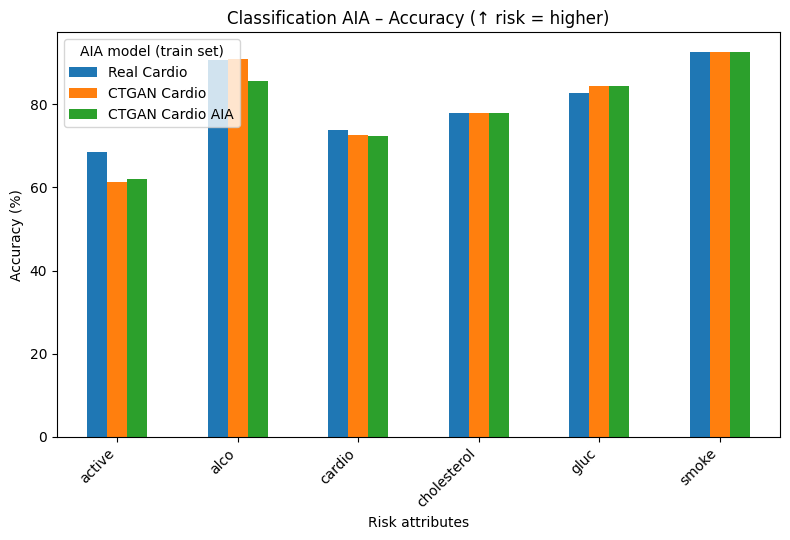

Saved: aia_cls_accuracy.png


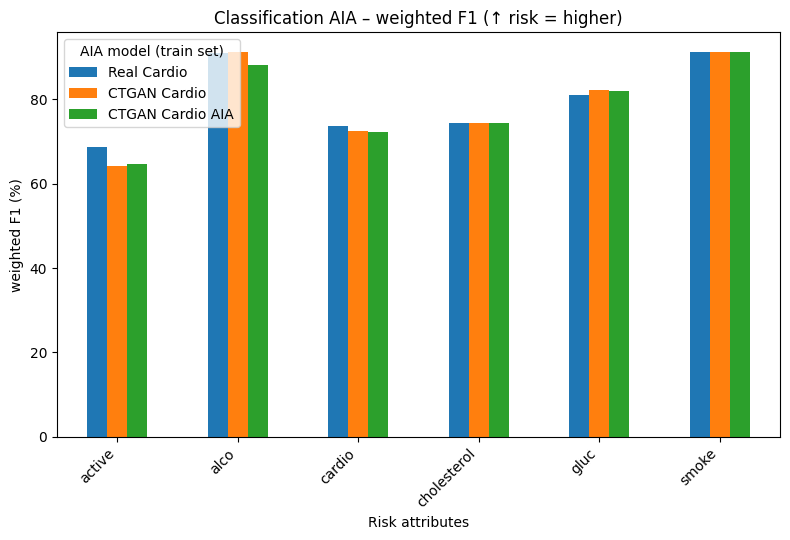

Saved: aia_cls_weighted_f1.png


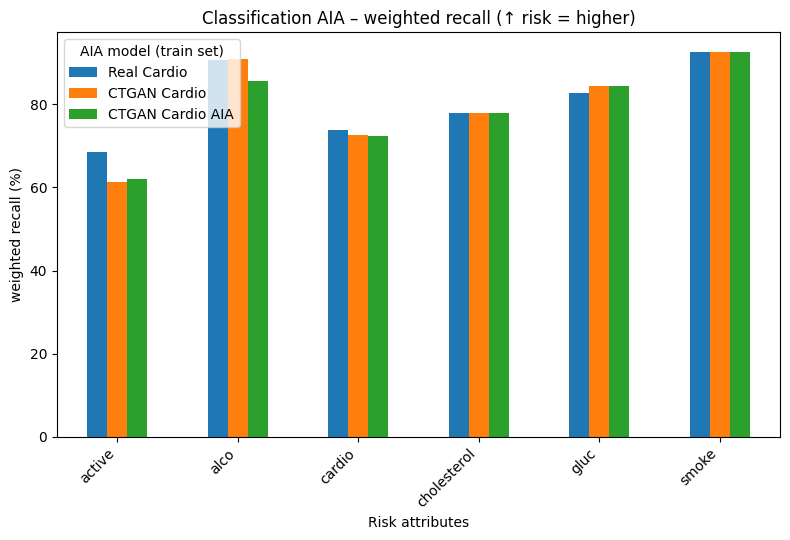

Saved: aia_cls_weighted_recall.png


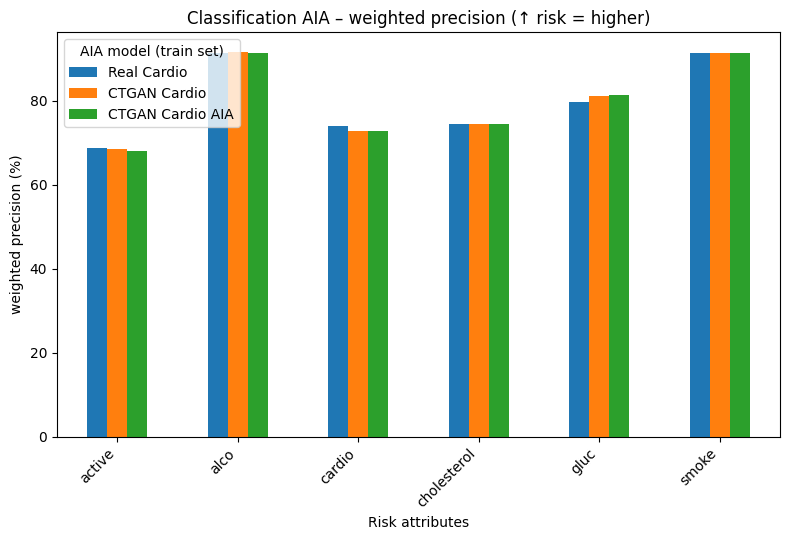

Saved: aia_cls_weighted_precision.png


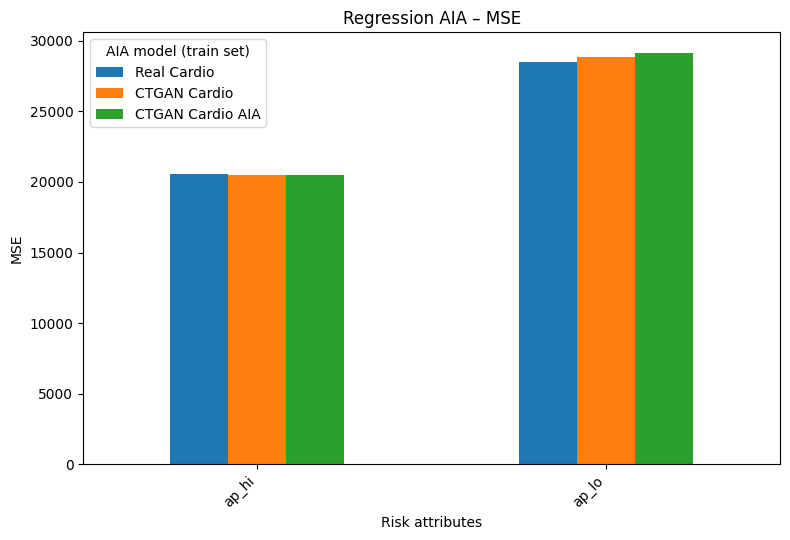

Saved: aia_reg_mse.png


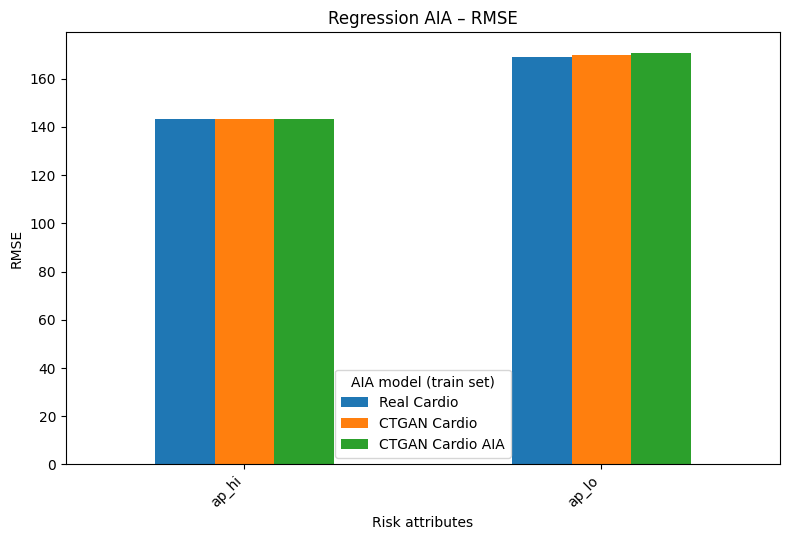

Saved: aia_reg_rmse.png


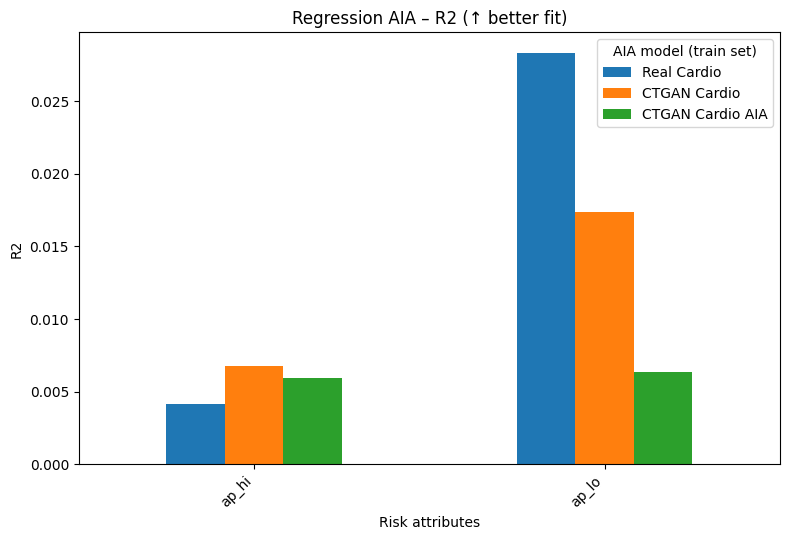

Saved: aia_reg_r2.png


In [14]:
cls_wide, reg_wide = compare_aia_with_predictions(
    privacy_evaluator     = privacy_evaluator,  # any evaluator that holds the same _attacker_non_qid_data
    predictions_dict_real = predictions_dict_real_cardio,
    predictions_dict_synthA = predictions_dict_synth_cardio,
    predictions_dict_synthB = predictions_dict_synth_cardio_aia,
    label_real  = "Real Cardio",
    label_synthA= "CTGAN Cardio",
    label_synthB= "CTGAN Cardio AIA",
    excel_out   = "aia_metrics_from_predictions.xlsx"
)

## Visualization of $\epsilon$ versus privacy

### Utilities

In [9]:
from typing import Any, Dict, Hashable, Iterable, Sequence

def _pluck_nested(d: Dict[str, Any], path: Sequence[Hashable]) -> Any:

    current: Any = d
    for key in path:
        try:
            current = current[key]
        except (KeyError, TypeError) as exc:
            raise KeyError(f"Missing key {key!r} in path {path}") from exc
    return current

def collect_nested(
    data: Dict[str, Dict[str, Any]],
    path: Sequence[Hashable],
) -> Dict[str, Any]:

    return {k: _pluck_nested(v, path) for k, v in data.items()}


def map_share(
    results: Dict[str, Dict[str, Any]],
    ordered_keys: Iterable[Hashable],
) -> Dict[Hashable, Any]:
    share_values = list(
        collect_nested(results, ("privacy_evaluation_results", "share")).values()
    )

    ordered_keys = list(ordered_keys)  # supports any iterable input

    if len(ordered_keys) != len(share_values):
        raise ValueError(
            f"{len(ordered_keys)=} does not match {len(share_values)=}"
        )

    return dict(zip(ordered_keys, share_values))

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_share(datasets):

    fig, axes = plt.subplots(
        nrows=len(datasets), ncols=1,
        figsize=(8, 2.8 * len(datasets)),
        sharex=True
    )

    for ax, (ds_name, models) in zip(axes, datasets.items()):
        for model_name, res in models.items():
            eps    = np.array(sorted(res, reverse=True))
            shares = np.array([res[e] for e in eps])

            # main curve -------------------------------------------------
            (ln,) = ax.plot(eps, shares, "o-", label=model_name)
            curve_color = ln.get_color()

            # baseline star ---------------------------------------------
            eps_max   = eps[0]
            share_max = res[eps_max]

            ax.scatter(
                eps_max, share_max,
                marker="*", s=120,
                color=curve_color,
                edgecolor="black",
                zorder=3,
                label=f"baseline (no constraint)\nε = {eps_max:g}",
            )

        # row styling
        ax.set_title(ds_name, loc="left", fontweight="bold")
        ax.axhline(50, ls="--", lw=0.8, color="grey", alpha=0.7)
        ax.set_ylabel("DCR share (%)")
        ax.grid(True, which="both", ls=":", lw=0.5)

        # put legend outside (right side)
        ax.legend(
            bbox_to_anchor=(1.05, 1),  # anchor legend box
            loc="upper left",          # position relative to anchor
            borderaxespad=0.
        )

    axes[-1].set_xlabel("ε (privacy radius)  ↓ stricter   ↑ looser")
    for ax in axes:
        ax.set_xscale("log")
        ax.invert_xaxis()

    fig.suptitle("Accepted-sample share vs. ε  ·  CTGAN vs TVAE", y=1.02, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on the right for legends
    plt.show()


In [11]:
import itertools

def plot_share_2(datasets):
    linestyles = {"CTGAN": "-", "TVAE": "--", "CTGAN Heom" : ":", "CTGAN TabNet" : "o"}
    colors     = dict(zip(datasets, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

    fig, ax = plt.subplots(figsize=(8, 5))

    for ds_name, models in datasets.items():
        for model_name, res in models.items():
            eps    = np.array(sorted(res, reverse=True))
            shares = np.array([res[e] for e in eps])

            ax.plot(
                eps, shares,
                linestyle=linestyles[model_name],
                marker="o",
                color=colors[ds_name],
                label=f"{ds_name} · {model_name}",
            )

            # baseline marker + annotation
            eps_max   = eps[0]
            share_max = res[eps_max]
            ax.scatter(eps_max, share_max,
           s=120, marker="*", color=colors[ds_name],edgecolor="black",
           label=f"baseline (no constraint)\nε = {eps_max:g}")


    ax.axhline(50, ls="--", lw=0.8, color="grey", alpha=0.7)
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("ε (privacy radius)  ↓ stricter   ↑ looser")
    ax.set_ylabel("DCR share (%)")
    ax.set_title("DCR share vs. ε  ·  All datasets & models")
    ax.grid(True, which="both", ls=":", lw=0.6)
    ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

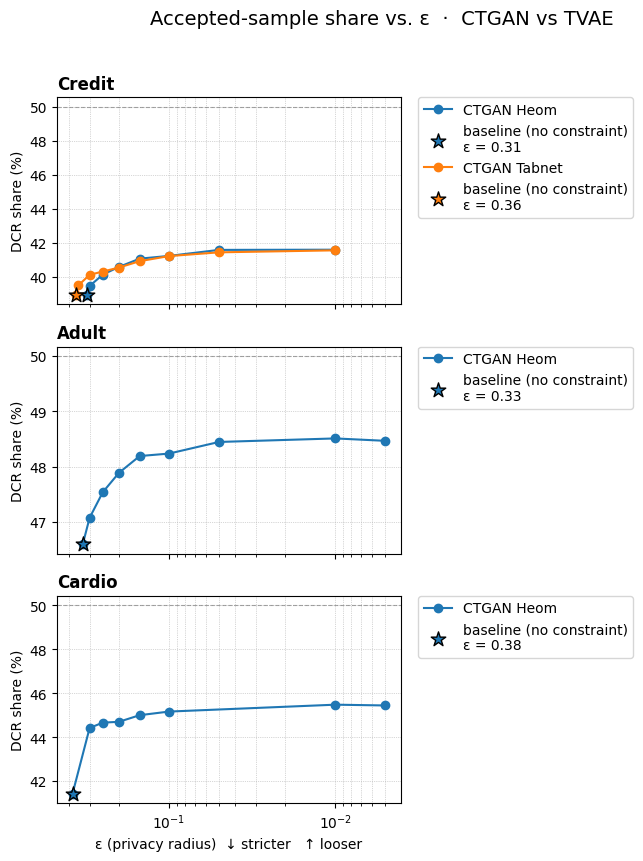

In [20]:
datasets = {
    "Credit":  {
        "CTGAN Heom": map_share(dict_results_credit_ctgan_heom, [0.31, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]),
        "CTGAN Tabnet": map_share(dict_results_credit_ctgan_tabnet, [0.36, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]),
    },
        "Adult":  {
        "CTGAN Heom": map_share(dict_results_adult_ctgan_heom, [0.33,  0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01, 0.005]),
        
    },
    "Cardio" :{
        "CTGAN Heom" : map_share(dict_results_cardio_ctgan_heom, [0.38,  0.3, 0.25, 0.2, 0.15, 0.1, 0.01, 0.005])
    }

}

plot_share(datasets)

In [32]:
for key, value in dict_results_credit_ctgan_tabnet.items() :
    synth_data = value['generation_results']['synthetic_data']
    epsilon_identifiability = get_epsilon_tabnet(
                df_real_credit_card_train, synth_data, embed_fn)
    print('key : ', key, ' : ', epsilon_identifiability)

key :  credit CTGAN  :  0.3730833333333333
key :  credit CTGAN 0.35  :  0.3499583333333333
key :  credit CTGAN 0.3  :  0.2999583333333333
key :  credit CTGAN 0.25  :  0.24995833333333334
key :  credit CTGAN 0.2  :  0.2
key :  credit CTGAN 0.15  :  0.15008333333333335
key :  credit CTGAN 0.1  :  0.10008333333333333
key :  credit CTGAN 0.05  :  0.050208333333333334
key :  credit CTGAN 0.01  :  0.01025


In [29]:
for key, value in dict_results_credit_ctgan_heom.items() :
    synth_data = value['generation_results']['synthetic_data']
    epsilon_identifiability = get_epsilon(
                df_real_credit_card_train, synth_data, cat_list_credit_card, num_list_credit_card)
    print('key : ', key, ' : ', epsilon_identifiability)

key :  credit CTGAN  :  0.30233333333333334
key :  credit CTGAN 0.3  :  0.30483333333333335
key :  credit CTGAN 0.25  :  0.30554166666666666
key :  credit CTGAN 0.2  :  0.310125
key :  credit CTGAN 0.15  :  0.30104166666666665
key :  credit CTGAN 0.1  :  0.2855
key :  credit CTGAN 0.05  :  0.26929166666666665
key :  credit CTGAN 0.01  :  0.25454166666666667


In [28]:
synth_data = credit_ctgan_eps_tabnet_001['generation_results']['synthetic_data']

for key, value in dict_results_credit_ctgan_tabnet.items() :
    synth_data = value['generation_results']['synthetic_data']
    epsilon_identifiability = get_epsilon(
                df_real_credit_card_train, synth_data, cat_list_credit_card, num_list_credit_card)
    print('key : ', key, ' : ', epsilon_identifiability)
    

key :  credit CTGAN  :  0.30233333333333334
key :  credit CTGAN 0.35  :  0.30591666666666667
key :  credit CTGAN 0.3  :  0.30954166666666666
key :  credit CTGAN 0.25  :  0.3202083333333333
key :  credit CTGAN 0.2  :  0.32745833333333335
key :  credit CTGAN 0.15  :  0.3237083333333333
key :  credit CTGAN 0.1  :  0.3107083333333333
key :  credit CTGAN 0.05  :  0.29220833333333335
key :  credit CTGAN 0.01  :  0.27608333333333335


In [15]:

for key, value in dict_results_credit_ctgan_tabnet_aiagard.items() :
    synth_data = value['generation_results']['synthetic_data']
    epsilon_identifiability = get_epsilon(
                df_real_credit_card_train, synth_data, cat_list_credit_card, num_list_credit_card)
    print('key : ', key, ' : ', epsilon_identifiability)

key :  credit CTGAN  :  0.30233333333333334
key :  credit CTGAN 0.35  :  0.30983333333333335
key :  credit CTGAN 0.3  :  0.325


In [27]:
epsilon_identifiability

0.27608333333333335

### Analyse Attribute Inference Attack

#### Utility

In [8]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator

def get_privacy_evaluator(df_train, df_test, synth_data, cat_list_cardio, cardio_qai_columns, cardio_risk_column) :


    df_train = DataLoader(dataset=df_train).get_dataframe(cat_list_cardio)
    synth_data = DataLoader(dataset=synth_data).get_dataframe(cat_list_cardio)
    df_test = DataLoader(dataset=df_test).get_dataframe(cat_list_cardio)
    return PrivacyEvaluator(df_train, synth_data, df_test, cardio_qai_columns, cardio_risk_column, "none")

In [10]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error


def result_regression(privacy_evaluator, predictions_dict_real, num_feat):
    results = {}

    results['MSE'] = mean_squared_error(privacy_evaluator._attacker_non_qid_data[num_feat], predictions_dict_real[num_feat])
    results['RMSE'] = root_mean_squared_error(privacy_evaluator._attacker_non_qid_data[num_feat], predictions_dict_real[num_feat])
    results['R2'] = r2_score(privacy_evaluator._attacker_non_qid_data[num_feat], predictions_dict_real[num_feat])

    return results

In [11]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.dummy import DummyRegressor


def result_classification(privacy_evaluator, predictions_dict_real, cat_feat):
    results = {}

    results['Accuracy'] = accuracy_score(privacy_evaluator._attacker_non_qid_data[cat_feat], predictions_dict_real[cat_feat])
    results['weighted F1'] = f1_score(privacy_evaluator._attacker_non_qid_data[cat_feat], predictions_dict_real[cat_feat], average='weighted')
    results['weighted recall'] = recall_score(privacy_evaluator._attacker_non_qid_data[cat_feat], predictions_dict_real[cat_feat], average='weighted')
    results['weighted precision'] = precision_score(privacy_evaluator._attacker_non_qid_data[cat_feat], predictions_dict_real[cat_feat], average='weighted')

    return results

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results_regression(results_regression: dict) -> None:
    # -- 1. Wide → tidy -----------------------------------------------------
    tidy = (
        pd.DataFrame(results_regression)     # keys ➜ columns
          .T                                 # keys ➜ rows
          .rename_axis("orig")               # row index = full key string
          .reset_index()
          .melt(id_vars="orig",
                var_name="metric",
                value_name="value")          # one row per metric/value
    )

    # -- 2. Parse the "orig" column safely ---------------------------------
    split = tidy["orig"].str.rsplit(" - ", n=2, expand=True)
    # Columns: [gen_type, target, maybe_dummy]  (maybe_dummy may be NaN)
    tidy["gen_type"] = split[0]                    # real / synthetic
    tidy["target"]   = split[1]                    # e.g. capital-gain
    tidy["dummy"]    = split[2].eq("dummy")        # True / False
    tidy = tidy.drop(columns="orig")

    # -- 3. Plot one panel per metric --------------------------------------
    for metric, sub in tidy.groupby("metric"):
        fig, ax = plt.subplots(figsize=(10, 4))

        # pivot_table tolerates duplicates; here there are none,
        # but pivot_table is still convenient for automatic NaN filling
        (
            sub.pivot_table(index="target",
                            columns=["gen_type", "dummy"],
                            values="value",
                            aggfunc="first")       # no aggregation needed
               .plot(kind="bar", ax=ax, rot=0)
        )

        ax.set_xlabel("")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend(title="gen_type / dummy", bbox_to_anchor=(1.02, 1),
                  loc="upper left", borderaxespad=0)
        plt.tight_layout()
        plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results_classification(results_cls: dict) -> None:
    """
    Visualise classification metrics stored in a nested dict like
        {'real - PAY_0':                {'Accuracy': 0.34, 'F1': 0.35},
         'real - PAY_0 - dummy':        {'Accuracy': ...},
         'synthetic - PAY_0':           {...},
         'synthetic - PAY_0 - dummy':   {...},
         ...}

    Produces one bar-chart panel per metric.
    """
    # ------------------------------------------------------------------ tidy ―――
    wide = pd.DataFrame(results_cls)

    tidy = (
        wide.stack()                                 # metric  orig-key  value
            .rename_axis(['metric', 'orig'])
            .reset_index()
            .assign(parts=lambda d: d['orig'].str.split(r'\s*-\s*'))
            .assign(gen_type=lambda d: d['parts'].str[0],           # real / synthetic
                    target  =lambda d: d['parts'].str[1],           # PAY_0, …
                    dummy   =lambda d: d['parts'].str[-1].eq('dummy'))
            .drop(columns=['orig', 'parts'])
            .rename(columns={0: 'value'})
    )

    # ----------------------------------------------------------------- plot ―――
    for metric, sub in tidy.groupby('metric'):
        df = (sub.pivot_table(index='target',
                              columns=['gen_type', 'dummy'],
                              values='value',
                              aggfunc='first')
                 .sort_index())                        # keeps targets in alpha order

        ax = df.plot(kind='bar', figsize=(12, 4), rot=0,
                     title=f'{metric} by target / data source')

        ax.set_xlabel('')
        ax.set_ylabel(metric)
        ax.legend(title='Source | Dummy', bbox_to_anchor=(1.04, 1),
                  loc='upper left', borderaxespad=0)
        plt.tight_layout()
        plt.show()


In [14]:

def get_result_classifiaction_over_epsilon(dict_results, df_real_train, df_real_test, cat_list, qai_column, risk_column, risk_score) :
    
    results_regression_dict = {}
    first_time = True
    df_train = DataLoader(dataset=df_real_train).get_dataframe(cat_list)
    df_test = DataLoader(dataset=df_real_test).get_dataframe(cat_list)
    
    for key, synth_data in dict_results.items():
        
        synth_data_loaded = DataLoader(dataset=synth_data['generation_results']['synthetic_data']).get_dataframe(cat_list)

        privacy_evaluator = get_privacy_evaluator(df_train, df_test, synth_data_loaded, cat_list, qai_column, risk_column)
        results_real, results_std_real, results_std_att_real,results_acc_att_real, predictions_dict_real = privacy_evaluator.evaluate_attribute_real_prediction()
        results_synth, results_std_synth, results_std_att_synth,results_acc_att_synth, predictions_dict_synth = privacy_evaluator.evaluate_attribute_synthetic_prediction() #after test be sure to return the only rigth value


        results_regression = {}

        for num_feat in risk_score :
            if first_time :
                results_regression[f"real - {num_feat}"] = result_classification(privacy_evaluator, predictions_dict_real, num_feat)
                results_regression[f"synthetic - {num_feat}"] = result_classification(privacy_evaluator, predictions_dict_synth, num_feat)
            else :
                results_regression[f"synthetic - {num_feat}"] = result_classification(privacy_evaluator, predictions_dict_synth, num_feat)
        first_time = False
        results_regression_dict[key] = results_regression

    return results_regression_dict

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def print_classification_result(results_classification) : 

    # --------------------------
    # 1) Flatten the results dict
    # --------------------------
    rows = []
    for synth_name, attrs in results_classification.items():               # outer‐level key
        for k, metric_dict in attrs.items():                # “real - chol”, etc.
            src, target_attr = k.split(" - ", 1)            # → (“real”, “cholesterol”)
            for metric, score in metric_dict.items():       # Accuracy, F1, …
                rows.append(
                    {
                        "metric": metric,
                        "target_attr": target_attr,
                        "model": f"{synth_name} ({src})",   # e.g. “cardio CTGAN 0.25 (real)”
                        "score": score,
                    }
                )

    long_df = pd.DataFrame(rows)
    # long_df.head()
    #    metric target_attr                model     score
    # 0 Accuracy cholesterol  cardio CTGAN (real)  0.59461
    # 1 Accuracy cholesterol  cardio CTGAN (synthetic) 0.55293
    # …

    # -----------------------------------------
    # 2) One grouped-bar figure per *metric*
    # -----------------------------------------
    unique_metrics = long_df["metric"].unique()
    for m in unique_metrics:
        df_m = long_df[long_df["metric"] == m]

        # ordered x-categories
        attrs = sorted(df_m["target_attr"].unique())
        x = np.arange(len(attrs))

        # ordered bar groups
        models = df_m["model"].unique()
        width = 0.8 / len(models)                          # leave 20 % padding

        fig, ax = plt.subplots(figsize=(10, 6))

        for i, model in enumerate(models):
            # grab (or NaN-fill) the scores in x-order
            scores = df_m[df_m["model"] == model]          \
                        .set_index("target_attr")           \
                        .reindex(attrs)["score"]            \
                        .values
            ax.bar(x + (i - (len(models) - 1) / 2) * width,
                scores,
                width,
                label=model)

        ax.set_title(m)
        ax.set_ylabel(m)
        ax.set_xticks(x)
        ax.set_xticklabels(attrs, rotation=45, ha="right")

        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.legend(title="dataset (source)",
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0.0,
                fontsize="small")

        plt.tight_layout()
        plt.show()


In [16]:
# --------------------------------------------------------------
#  Fast LightGBM Attribute‑Inference Attack (native categoricals)
# --------------------------------------------------------------
from typing import List
import time, joblib, numpy as np, pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor

def lgbm_aia_random(
        data_train: pd.DataFrame,
        data_test : pd.DataFrame,
        cat_cols  : List[str],        # names of categorical features
        num_cols  : List[str],        # names of numeric features
        target    : List[str],
        *,
        n_iter: int        = 30,
        early_stopping: int = 50,
        outer_jobs: int    = 8,
        random_state: int  = 42):

    # --------------------------- prepare X, y -------------------------------
    X_train = data_train.drop(columns=target).copy()
    X_test  = data_test.drop(columns=target).copy()

    # mark categoricals
    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_test[col]  = X_test[col].astype("category")

    y_train = data_train[target[0]] if len(target)==1 else data_train[target]
    y_test  = data_test[target[0]]  if len(target)==1 else data_test[target]

    # ------------- base LightGBM regressor ----------------------------------
    base = lgb.LGBMRegressor(
                objective="regression",
                random_state=random_state,
                n_jobs=1,               # avoid nested threads
                verbosity=-1,
                categorical_feature=cat_cols
           )
    model = base if len(target)==1 else MultiOutputRegressor(base)

    # ------------- hyper‑parameter search space -----------------------------
    prefix = "" if len(target)==1 else "estimator__"   # no Pipeline, but wrapper?
    param_dist = {
        f"{prefix}n_estimators"    : np.linspace(400, 1500, 8, dtype=int),
        f"{prefix}learning_rate"   : np.logspace(-2, -0.7, 10),
        f"{prefix}num_leaves"      : [31, 63, 127],
        f"{prefix}min_child_samples": [5, 15, 30, 60],
        f"{prefix}colsample_bytree": np.linspace(0.7, 1.0, 4),
    }

    # ------------- early‑stopping validation split --------------------------
    X_tr, X_val, y_tr, y_val = train_test_split(
                                    X_train, y_train,
                                    test_size=0.15,
                                    random_state=random_state)

    early_cb  = lgb.early_stopping(stopping_rounds=early_stopping,
                                   first_metric_only=True)
    silent_cb = lgb.log_evaluation(period=0)

    fit_params = {
        f"{prefix}eval_set": [(X_val, y_val)],
        f"{prefix}callbacks": [early_cb, silent_cb],
    }

    # ------------- Randomised CV search -------------------------------------
    search = RandomizedSearchCV(
                model,
                param_distributions=param_dist,
                n_iter=n_iter,
                cv=5,
                n_jobs=outer_jobs,
                scoring="neg_mean_absolute_error",
                verbose=2,
                random_state=random_state)

    t0 = time.time()
    search.fit(X_tr, y_tr, **fit_params)
    mins = (time.time()-t0)/60

    print("Best params:", search.best_params_)
    print("CV MAE   :", -search.best_score_)
    print(f"Elapsed  : {mins:.1f} min")

    y_pred = search.predict(X_test)
    print("Test MAE :", mean_absolute_error(y_test, y_pred))

    fname = f"lgb_attack_{'_'.join(target)}.pkl"
    joblib.dump(search.best_estimator_, fname)
    return search.best_estimator_


In [17]:
import re
from math import isfinite
from typing import Dict, List

import matplotlib.pyplot as plt
from matplotlib import cm


# ─────────────────────────────────────────────────────────────────────────────
def _parse_epsilon(raw: str) -> float:
    if "." in raw:
        return float(raw)
    val = int(raw.lstrip("0") or "0")
    return val / 10 ** (len(raw) - 1)
# ─────────────────────────────────────────────────────────────────────────────


def plot_metrics_all_eps(
    results: dict,
    *,
    mode: str = "overlay",      # "overlay" | "facet" | "dt" | "lgbm"
    order_mode: str = "tight-to-loose",
    palette: str = "tab10",
    yscale: str = "auto",
    normalise: bool = False,
    left_margin: float = 0.32,
):
    """
    Draw error bars across ε runs.

    mode
    ----
    overlay : original behaviour (all families together)
    facet   : one separate figure per family
    dt      : only Decision‑Tree attackers (real + synthetic)
    lgbm    : only LightGBM attackers   (real + synthetic)
    """

    allowed = {"overlay", "facet", "dt", "lgbm"}
    if mode not in allowed:
        raise ValueError(f"`mode` must be one of {allowed}")

    # ------------------------------------------------------------------
    # 1) identify baseline key and ε ordering  (unchanged)  ------------
    # ------------------------------------------------------------------
    import re, matplotlib.pyplot as plt
    from matplotlib import cm
    from math import isfinite

    baseline_key = next(k for k in results if not re.search(r"\d", k.split()[-1]))
    eps_keys, eps_vals = [], []
    for k in results:
        if k == baseline_key:
            continue
        m = re.search(r"(\d+\.?\d*)\s*$", k)
        if m:
            eps_vals.append(_parse_epsilon(m.group(1)))
            eps_keys.append(k)
    eps_keys.insert(0, baseline_key)
    eps_vals.insert(0, 0.0)
    rev = order_mode == "loose-to-tight"
    pairs = sorted(zip(eps_vals[1:], eps_keys[1:]), key=lambda p: p[0], reverse=rev)
    if pairs:
        eps_vals[1:], eps_keys[1:] = zip(*pairs)

    # ------------------------------------------------------------------
    # 2) figure out target cols present in every ε ---------------------
    # ------------------------------------------------------------------
    tgt_base = {k.split(" - ", 1)[1]
                for k in results[baseline_key]
                if k.startswith("decision_tree_real - ")}
    targets = sorted(t for t in tgt_base
                     if all(f"decision_tree - {t}" in results[e] for e in eps_keys))
    if not targets:
        raise ValueError("No common target column across ε runs.")

    # ------------------------------------------------------------------
    # 3) collect rms / mse / r2 for each family ------------------------
    # ------------------------------------------------------------------
    fam_list = ["dt", "lgbm"] if mode in {"overlay", "facet"} else [mode]

    mets = ["MSE", "RMSE", "R2"]
    data = {fam: {"real": {m: [] for m in mets},
                  "syn":  {m: [[] for _ in eps_keys] for m in mets}}
            for fam in fam_list}

    for tgt in targets:
        dt_real_vals = results[baseline_key][f"decision_tree_real - {tgt}"]
        lg_real_vals = results[baseline_key][f"real - {tgt}"]

        for m in mets:
            if "dt" in fam_list:
                data["dt"]["real"][m].append(
                    1 if normalise and m != "R2" else dt_real_vals[m])
            if "lgbm" in fam_list:
                data["lgbm"]["real"][m].append(
                    1 if normalise and m != "R2" else lg_real_vals[m])

        for j, e in enumerate(eps_keys):
            dt_syn = results[e][f"decision_tree - {tgt}"]
            lg_syn = results[e][f"lightgbm - {tgt}"]
            for m in mets:
                denom = dt_real_vals[m] if (normalise and m != "R2") else 1
                if "dt" in fam_list:
                    v = dt_syn[m] / denom if denom else float("nan")
                    data["dt"]["syn"][m][j].append(v)
                if "lgbm" in fam_list:
                    v = lg_syn[m] / denom if denom else float("nan")
                    data["lgbm"]["syn"][m][j].append(v)

    # ------------------------------------------------------------------
    # 4) decide how many figures to draw -------------------------------
    # ------------------------------------------------------------------
    families_to_plot = fam_list if mode == "facet" else ["combined"]

    for fig_idx, fam in enumerate(families_to_plot, start=1):

        # mapping for overlay mode
        fams_in_fig = fam_list if fam == "combined" else [fam]

        n_eps = len(eps_keys)
        bar_w = 0.8 / (n_eps + 1)
        x = range(len(targets))
        cmap = cm.get_cmap(palette, n_eps)

        fig, axes = plt.subplots(3, 1,
                                 figsize=(2 + 2.5 * len(targets), 12),
                                 sharex=True)

        for ax, m in zip(axes, mets):

            # choose scale
            vals_flat = []
            for f in fams_in_fig:
                vals_flat += data[f]["real"][m]
                for row in data[f]["syn"][m]:
                    vals_flat += row
            if m != "R2":
                vmax, vmin = max(vals_flat), max(min(vals_flat), 1e-12)
                if yscale == "log" or (yscale == "auto" and vmax / vmin > 100):
                    ax.set_yscale("log")

            # baseline bars first
            pos_shift = -0.4
            if "dt" in fams_in_fig:
                ax.bar([i + pos_shift for i in x],
                       data["dt"]["real"][m],
                       width=bar_w,
                       color="grey",
                       edgecolor="black",
                       label="DT‑real" if m == "MSE" else None)
            if "lgbm" in fams_in_fig:
                ax.bar([i + pos_shift + bar_w/2 for i in x],
                       data["lgbm"]["real"][m],
                       width=bar_w/2,
                       color="grey",
                       edgecolor="black",
                       hatch="//",
                       label="LGBM‑real" if m == "MSE" else None)

            # ε‑dependent bars
            for j, eps_val in enumerate(eps_vals):
                off = -0.4 + (j + 1) * bar_w
                if "dt" in fams_in_fig:
                    ax.bar([i + off for i in x],
                           data["dt"]["syn"][m][j],
                           width=bar_w,
                           color=cmap(j),
                           edgecolor="black",
                           label=(f"ε = {eps_val:g}" if m == "MSE" else None))
                if "lgbm" in fams_in_fig:
                    ax.bar([i + off + bar_w/2 for i in x],
                           data["lgbm"]["syn"][m][j],
                           width=bar_w/2,
                           color=cmap(j),
                           edgecolor="black",
                           hatch="//",
                           label=("LGBM synth." if m == "MSE" and j == 0 else None))

            ax.set_ylabel(m + (" (ratio)" if normalise and m != "R2" else ""))
            ax.set_title(f"{m} across target columns")

        # legend
        h, l = axes[0].get_legend_handles_labels()
        uniq = dict(zip(l, h))
        fig.subplots_adjust(left=left_margin)
        fig.legend(list(uniq.values()), list(uniq.keys()),
                   loc="center left", bbox_to_anchor=(-0.02, 0.5), frameon=False)

        axes[-1].set_xticks(list(x))
        axes[-1].set_xticklabels(targets, rotation=45, ha="right")
        axes[-1].set_xlabel("Target column")

        if mode == "facet":          # distinguish files/figures
            fig.suptitle(fam.upper(), y=0.98)

        plt.tight_layout(rect=[left_margin, 0, 1, 1])
        plt.show()


# ──────────────────────────────────────────────────────────────────────────
# 3. Aggregator – run the privacy evaluation *once per risk column* and merge
# ──────────────────────────────────────────────────────────────────────────
def collect_results_all_risks(
    dict_results,
    df_train,
    df_test,
    cat_list,
    num_list,
    qai_dict,       # mapping: risk_column → list-of-QAI-columns
    get_result_fn   # normally get_result_regressions_over_epsilon
):
    """
    Returns a `results` dictionary compatible with plot_metrics_all_eps()
    even when every risk column has its own QAI feature set.
    """
    combined = {}

    lgbm_models = {}

    for  risk_col, qais in qai_dict.items():
        # train the attacker on *this* column only
        best = lgbm_aia_random(
                df_train,
                df_test,
                cat_cols = cat_list,
                num_cols = [c for c in num_list if c != risk_col],
                target   = [risk_col])

        fixed_params = best.get_params()

        models = {}
        X_tr = df_train.drop(columns=[risk_col])
        y_tr = df_train[risk_col]
        models['real'] = lgb.LGBMRegressor(**fixed_params).fit(X_tr, y_tr)
        
        for eps_key, synth in dict_results.items():
            X_tr = synth["generation_results"]["synthetic_data"].drop(columns=[risk_col])
            y_tr = synth["generation_results"]["synthetic_data"][risk_col]

            models[eps_key] = lgb.LGBMRegressor(**fixed_params).fit(X_tr, y_tr)
        lgbm_models[risk_col] = models

    for risk_col, qais in qai_dict.items():
        
        # -------------------------------------------------
        #  run the user‑supplied evaluator for *this* risk
        # -------------------------------------------------
        partial = get_result_fn(
            dict_results,
            df_train,
            df_test,
            cat_list,
            qais,
            [risk_col],      # risk_column argument
            [risk_col],      # risk_score argument
            lgbm_models
        )

        # -------------------------------------------------
        #  merge with already‑seen risk columns
        # -------------------------------------------------
        for model_key, metrics in partial.items():
            combined.setdefault(model_key, {}).update(metrics)

    return combined



In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# ------------------------------------------------------------------
# helper: predict → Series with index      (unchanged, but returns pd.Series)
# ------------------------------------------------------------------
def _predict_with_lgbm(model, X_df, risk_cols):
    preds = model.predict(X_df)
    if preds.ndim == 1:
        return {risk_cols[0]: pd.Series(preds, index=X_df.index)}
    return {c: pd.Series(preds[:, i], index=X_df.index)
            for i, c in enumerate(risk_cols)}


# ------------------------------------------------------------------
# main
# ------------------------------------------------------------------
def get_result_regressions_over_epsilon(
    dict_results : dict,
    df_train     : pd.DataFrame,
    df_test      : pd.DataFrame,
    cat_list     : list,
    qai_columns  : list,
    risk_column  : list,
    risk_score   : list,
    lgbm_models  : dict          # hierarchical dict just described
) -> dict:
    """
    Returns a nested dict

        ε_key ─► { "decision_tree_real - ap_hi": {...},
                   "decision_tree - ap_hi":      {...},
                   "real - ap_hi":               {...},   # LightGBM on real
                   "lightgbm - ap_hi":           {...},   # LightGBM on synth‑ε
                   ... for each risk attribute }
    """

    # --------------------------------------------------------------
    #  Pre‑process real / test frames once
    # --------------------------------------------------------------
    df_train_pre = DataLoader(dataset=df_train).get_dataframe(cat_list)
    df_test_pre  = DataLoader(dataset=df_test ).get_dataframe(cat_list)

    # --------------------------------------------------------------
    #  Pre‑compute LightGBM‑real predictions (once per attribute)
    # --------------------------------------------------------------
    lgbm_real_pred = {}
    for attr in risk_score:
        mdl_real = lgbm_models.get(attr, {}).get("real")
        if mdl_real is None:
            continue
        X_real = df_test_pre.drop(columns=[attr])
        lgbm_real_pred.update(
            _predict_with_lgbm(mdl_real, X_real, [attr])
        )

    # --------------------------------------------------------------
    results_regression_dict = {}

    for eps_key, synth_bundle in dict_results.items():

        # ---- synthetic table for this ε
        synth_df = DataLoader(
            dataset=synth_bundle["generation_results"]["synthetic_data"]
        ).get_dataframe(cat_list)

        # ---- instantiate privacy evaluator (decision‑tree attacker)
        peval = get_privacy_evaluator(
            df_train_pre,
            df_test_pre,
            synth_df,
            cat_list,
            qai_columns,
            risk_column
        )

        # decision‑tree predictions
        _, _, _, _, dt_real_pred   = peval.evaluate_attribute_real_prediction()
        _, _, _, _, dt_synth_pred  = peval.evaluate_attribute_synthetic_prediction()

        # ---- prepare LightGBM synthetic‑ε predictions for each attr
        lgbm_synth_pred = {}
        for attr in risk_score:
            mdl = lgbm_models.get(attr, {}).get(eps_key)
            if mdl is None:
                continue
            X_feat = df_test_pre.drop(columns=[attr])
            ser = _predict_with_lgbm(mdl, X_feat, [attr])[attr]
            lgbm_synth_pred[attr] = ser.reindex(peval._attacker_non_qid_data.index)

        # also align real‑LightGBM predictions to current evaluator index
        lgbm_real_pred_aligned = {
            attr: ser.reindex(peval._attacker_non_qid_data.index)
            for attr, ser in lgbm_real_pred.items()
        }

        # ---- aggregate metrics
        res_per_attr = {}

        for attr in risk_score:

            res_per_attr[f"decision_tree_real - {attr}"] = result_regression(
                peval, dt_real_pred, attr)

            res_per_attr[f"decision_tree - {attr}"] = result_regression(
                peval, dt_synth_pred, attr)

            if attr in lgbm_real_pred_aligned:
                res_per_attr[f"real - {attr}"] = result_regression(
                    peval, {attr: lgbm_real_pred_aligned[attr]}, attr)

            if attr in lgbm_synth_pred:
                res_per_attr[f"lightgbm - {attr}"] = result_regression(
                    peval, {attr: lgbm_synth_pred[attr]}, attr)

        results_regression_dict[eps_key] = res_per_attr

    return results_regression_dict


##### utility only for LGBM

In [19]:
def collect_results_all_risks(
    dict_results: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    cat_list: list,
    num_list: list,
    qai_dict: dict,                # {risk_attr: list‑of‑QAI‑cols}
    get_result_fn                  # -> normally get_result_regressions_over_epsilon
) -> dict:

    # ------------------------------------------------------------–
    # 1.  Train every LightGBM model once
    # ------------------------------------------------------------–
    lgbm_models = {}              # {attr: {"real": mdl, eps_key: mdl_ε, …}}
    df_train = DataLoader(dataset=df_train).get_dataframe(cat_list)
    df_test  = DataLoader(dataset=df_test ).get_dataframe(cat_list)

    for attr in qai_dict.keys():
        # ── 1a.  tune / fit on *real* data ───────────────────────
        tuner = lgbm_aia_random(
            df_train, df_test,
            cat_cols=cat_list,
            num_cols=[c for c in num_list if c != attr],
            target=[attr],
        )
        fixed_params = tuner.get_params()

        models_for_attr = {}

        #   real‑data model
        Xr = df_train.drop(columns=[attr])
        yr = df_train[attr]
        models_for_attr["real"] = lgb.LGBMRegressor(**fixed_params).fit(Xr, yr)

        #   one synthetic model per ε key
        for eps_key, synth in dict_results.items():
            Xs = synth["generation_results"]["synthetic_data"].drop(columns=[attr])
            ys = synth["generation_results"]["synthetic_data"][attr]
            models_for_attr[eps_key] = lgb.LGBMRegressor(**fixed_params).fit(Xs, ys)

        lgbm_models[attr] = models_for_attr

    # ------------------------------------------------------------–
    # 2.  Run the ε‑loop evaluator once per risk attribute
    # ------------------------------------------------------------–
    combined = {}
    for attr, qais in qai_dict.items():
        partial = get_result_fn(
            dict_results,
            df_train,
            df_test,
            cat_list,
            qais,
            [attr],        # risk_column
            [attr],        # risk_score
            lgbm_models,
        )
        for model_key, metrics in partial.items():
            combined.setdefault(model_key, {}).update(metrics)

    return combined


In [20]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import pandas as pd

def _predict_series(model, X, attr):
    """LightGBM → pd.Series keeping index."""
    return pd.Series(model.predict(X), index=X.index)

def result_reg(ground, pred):
    return {
        "MSE":  mean_squared_error(ground, pred),
        "RMSE": root_mean_squared_error(ground, pred),
        "R2":   r2_score(ground, pred),
    }

def get_result_regressions_over_epsilon(
    dict_results: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    cat_list: list,
    qai_columns: list,          # ← still needed by PrivacyEvaluator
    risk_column: list,
    risk_score: list,           # list with one element (attr)
    lgbm_models: dict           # {attr: {"real": mdl, eps_key: mdl_ε}}
) -> dict:

    # Data preparation once
    df_train_p = DataLoader(dataset=df_train).get_dataframe(cat_list)
    df_test_p  = DataLoader(dataset=df_test ).get_dataframe(cat_list)

    attr = risk_score[0]                  # single target in this call
    mdl_real = lgbm_models[attr]["real"]  # LightGBM on real‑train
    X_real   = df_test_p.drop(columns=[attr])
    y_true   = df_test_p[attr]            # will be re‑indexed later

    # Predict with the real‑trained model once
    y_pred_real = _predict_series(mdl_real, X_real, attr)

    results = {}

    for eps_key, synth_bundle in dict_results.items():

        # privacy evaluator only to compute filtered index (duplicates removed)
        synth_df = DataLoader(
            dataset=synth_bundle["generation_results"]["synthetic_data"]
        ).get_dataframe(cat_list)

        peval = get_privacy_evaluator(
            df_train_p, df_test_p, synth_df,
            cat_list, qai_columns, risk_column
        )
        idx = peval._attacker_non_qid_data.index
        y_true_eps = y_true.loc[idx]

        # ---- LightGBM model trained on this ε synthetic set
        mdl_eps = lgbm_models[attr][eps_key]
        y_pred_eps = _predict_series(mdl_eps, X_real, attr).loc[idx]

        # ---- align real‑model preds to same index
        y_pred_real_eps = y_pred_real.loc[idx]

        results[eps_key] = {
            f"real - {attr}":      result_reg(y_true_eps, y_pred_real_eps),
            f"lightgbm - {attr}":  result_reg(y_true_eps, y_pred_eps),
        }

    return results


In [21]:
# helper unchanged
def _parse_epsilon(raw: str) -> float:
    if "." in raw:
        return float(raw)
    val = int(raw.lstrip("0") or "0")
    return val / 10 ** (len(raw) - 1)


# ──────────────────────────────────────────────────────────────────────────
def plot_metrics_all_eps(
    results: dict,
    *,
    mode: str = "overlay",          # "overlay" | "facet" | "dt" | "lgbm"
    order_mode: str = "tight-to-loose",
    palette: str = "tab10",
    yscale: str = "auto",
    normalise: bool = False,
    left_margin: float = 0.32,
):
    import re, matplotlib.pyplot as plt
    from matplotlib import cm
    from math import isfinite

    allowed = {"overlay", "facet", "dt", "lgbm"}
    if mode not in allowed:
        raise ValueError(f"`mode` must be one of {allowed}")

    # ------------------------------------------------------------------
    # 1) ε keys (same as before)
    # ------------------------------------------------------------------
    baseline_key = next(k for k in results if not re.search(r"\d", k.split()[-1]))

    eps_keys, eps_vals = [], []
    for k in results:
        if k == baseline_key:
            continue
        m = re.search(r"(\d+\.?\d*)\s*$", k)
        if m:
            eps_vals.append(_parse_epsilon(m.group(1)))
            eps_keys.append(k)

    eps_keys.insert(0, baseline_key)
    eps_vals.insert(0, 0.0)

    rev = order_mode == "loose-to-tight"
    pairs = sorted(zip(eps_vals[1:], eps_keys[1:]), key=lambda p: p[0], reverse=rev)
    if pairs:
        eps_vals[1:], eps_keys[1:] = zip(*pairs)

    # ------------------------------------------------------------------
    # 2) decide which families actually exist in the dict --------------
    # ------------------------------------------------------------------
    family_specs = {
        "dt":   ("decision_tree_real - ", "decision_tree - "),
        "lgbm": ("real - ",               "lightgbm - "),
    }

    fam_list = []
    for fam, (pref_real, pref_syn) in family_specs.items():
        sample_key = next(iter(results.values()))
        if any(k.startswith(pref_real) for k in sample_key):
            fam_list.append(fam)

    if mode in {"dt", "lgbm"}:
        if mode not in fam_list:
            raise ValueError(f"{mode} keys not found in this results dict.")
        fam_list = [mode]
    elif mode == "overlay":
        # keep whatever exists (1 or 2 families)
        pass
    elif mode == "facet":
        if not fam_list:
            raise ValueError("No recognised metric families in results.")
        # will iterate later family by family
    else:
        raise RuntimeError("unexpected mode branch")

    # ------------------------------------------------------------------
    # 3) collect common targets ----------------------------------------
    # ------------------------------------------------------------------
    # take first family's real‑prefix as reference to find targets
    pref_real_ref, pref_syn_ref = family_specs[fam_list[0]]

    tgt_base = {k.split(" - ", 1)[1]
                for k in results[baseline_key]
                if k.startswith(pref_real_ref)}

    targets = sorted(t for t in tgt_base if all(
        pref_syn_ref + t in results[e] for e in eps_keys))
    if not targets:
        raise ValueError("No common target column across ε runs.")

    # ------------------------------------------------------------------
    # 4) gather numbers -------------------------------------------------
    # ------------------------------------------------------------------
    mets = ["MSE", "RMSE", "R2"]
    data = {fam: {"real": {m: [] for m in mets},
                  "syn":  {m: [[] for _ in eps_keys] for m in mets}}
            for fam in fam_list}

    for tgt in targets:
        for fam in fam_list:
            pref_real, pref_syn = family_specs[fam]

            base_vals_real = results[baseline_key][pref_real + tgt]

            for m in mets:
                data[fam]["real"][m].append(
                    1 if normalise and m != "R2" else base_vals_real[m])

            for j, e in enumerate(eps_keys):
                syn_vals = results[e][pref_syn + tgt]
                for m in mets:
                    v = syn_vals[m]
                    if normalise and m != "R2":
                        denom = base_vals_real[m]
                        v = v / denom if isfinite(denom) and denom else float("nan")
                    data[fam]["syn"][m][j].append(v)

    # ------------------------------------------------------------------
    # 5) plotting -------------------------------------------------------
    # ------------------------------------------------------------------
    fams_to_show = fam_list if mode == "facet" else ["combined"]

    for fig_idx, fam_panel in enumerate(fams_to_show, 1):
        fams_in_fig = fam_list if fam_panel == "combined" else [fam_panel]

        n_eps  = len(eps_keys)
        bar_w  = 0.8 / (n_eps + 1)
        x      = range(len(targets))
        cmap   = cm.get_cmap(palette, n_eps)

        fig, axes = plt.subplots(3, 1,
                                 figsize=(2 + 2.5 * len(targets), 12),
                                 sharex=True)

        for ax, m in zip(axes, mets):

            # scale choice
            all_vals = []
            for fam in fams_in_fig:
                all_vals += data[fam]["real"][m]
                for row in data[fam]["syn"][m]:
                    all_vals += row
            if m != "R2":
                vmax, vmin = max(all_vals), max(min(all_vals), 1e-12)
                if yscale == "log" or (yscale == "auto" and vmax / vmin > 100):
                    ax.set_yscale("log")

            # baseline bars
            pos_shift = -0.4
            for fam in fams_in_fig:
                pref_real, _ = family_specs[fam]
                bar_args = dict(width=bar_w/2 if fam == "lgbm" else bar_w,
                                color="grey",
                                edgecolor="black",
                                hatch="//" if fam == "lgbm" else None,
                                label=(f"{fam.upper()}‑real" if m == "MSE" else None))
                x_shift = pos_shift if fam == "dt" else pos_shift + bar_w/2
                ax.bar([i + x_shift for i in x], data[fam]["real"][m], **bar_args)

            # ε‑dependent bars
            for j, eps_val in enumerate(eps_vals):
                off = -0.4 + (j + 1) * bar_w
                for fam in fams_in_fig:
                    _, pref_syn = family_specs[fam]
                    bar_args = dict(width=bar_w/2 if fam == "lgbm" else bar_w,
                                    color=cmap(j),
                                    edgecolor="black",
                                    hatch="//" if fam == "lgbm" else None,
                                    label=(f"ε = {eps_val:g}" + (" (LGBM)" if fam == "lgbm" else "")
                                           if m == "MSE" else None))
                    x_shift = 0 if fam == "dt" else bar_w/2
                    ax.bar([i + off + x_shift for i in x],
                           data[fam]["syn"][m][j],
                           **bar_args)

            ax.set_ylabel(m + (" (ratio)" if normalise and m != "R2" else ""))
            ax.set_title(f"{m} across target columns")

        # legend
        h, l = axes[0].get_legend_handles_labels()
        uniq = dict(zip(l, h))
        fig.subplots_adjust(left=left_margin)
        fig.legend(list(uniq.values()), list(uniq.keys()),
                   loc="center left", bbox_to_anchor=(-0.02, 0.5), frameon=False)

        axes[-1].set_xticks(list(x))
        axes[-1].set_xticklabels(targets, rotation=45, ha="right")
        axes[-1].set_xlabel("Target column")

        if mode == "facet":
            fig.suptitle(fam_panel.upper(), y=0.98)

        plt.tight_layout(rect=[left_margin, 0, 1, 1])
        plt.show()


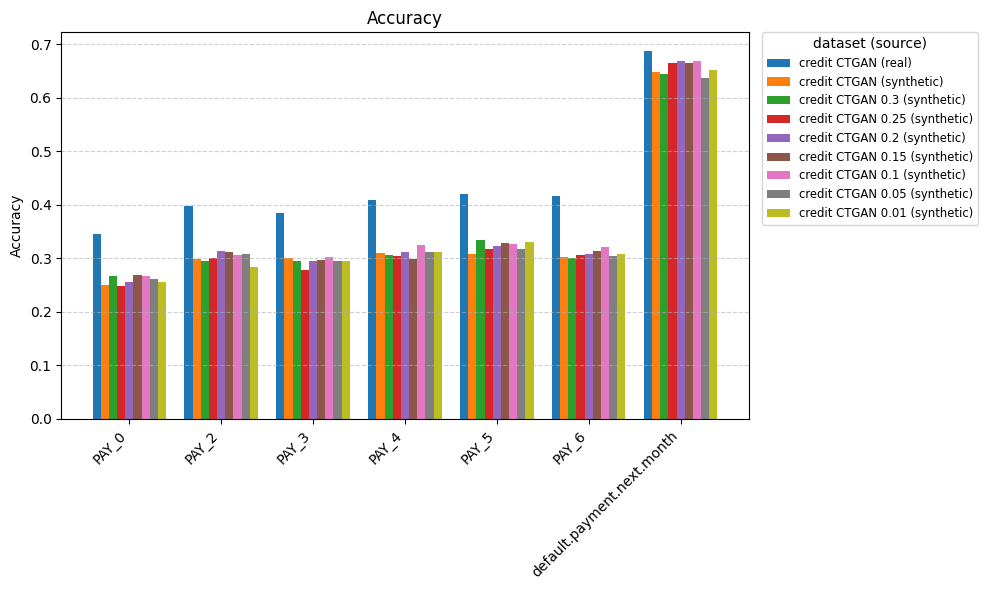

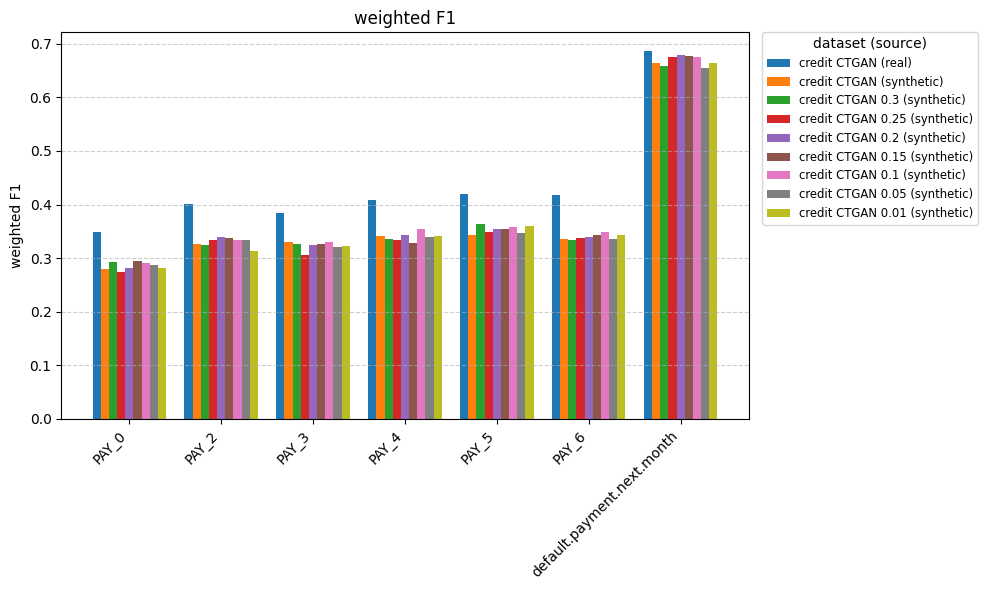

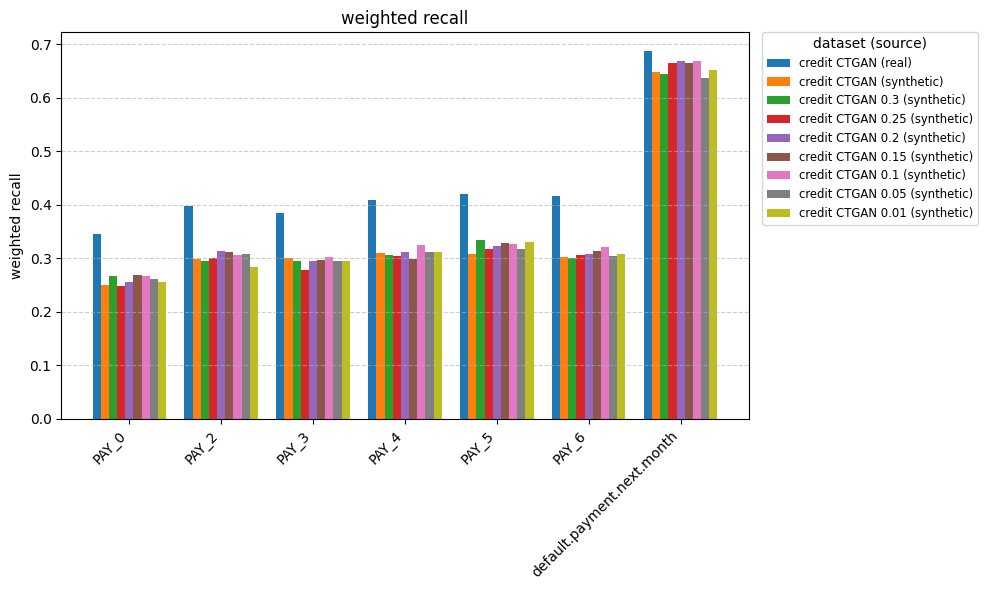

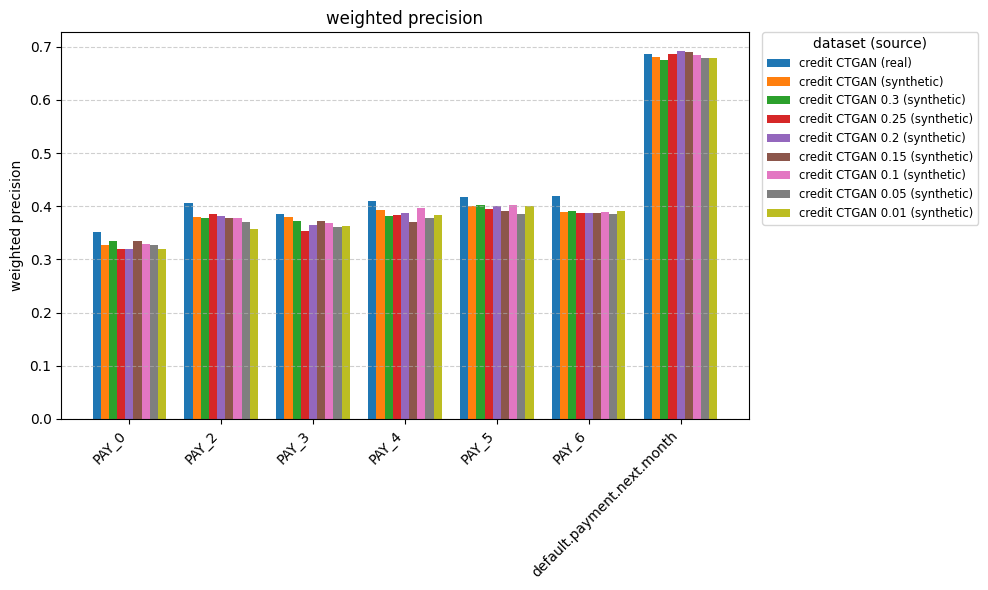

In [17]:
import numpy as np

credit_risk_score = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','default.payment.next.month']

results_classification_credit_ctgan = get_result_classifiaction_over_epsilon(dict_results_credit_ctgan_heom, df_real_credit_card_train, df_real_credit_card_test, cat_list_credit_card, credit_qai_columns, credit_risk_column, credit_risk_score)
print_classification_result(results_classification_credit_ctgan)

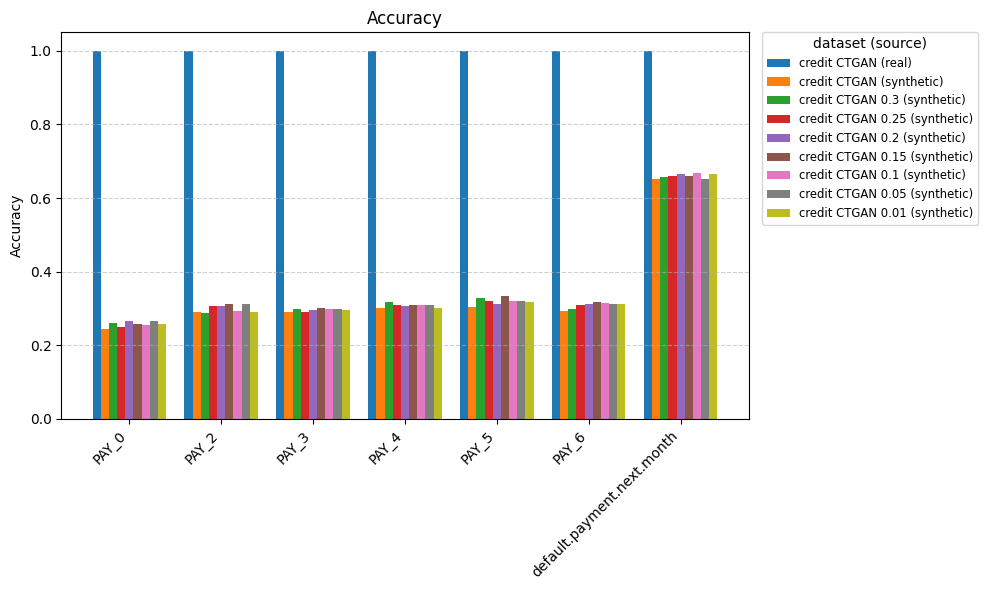

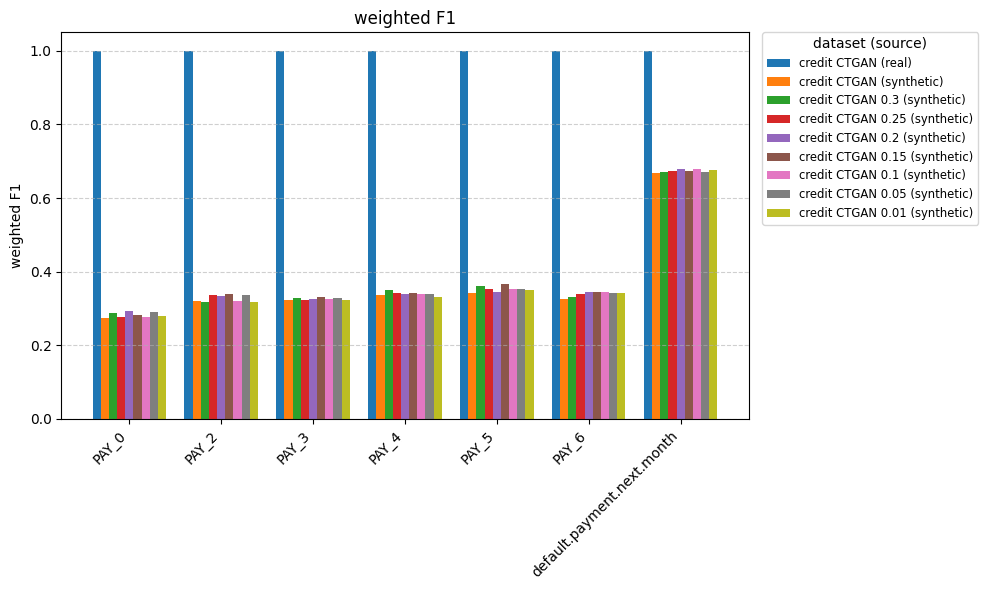

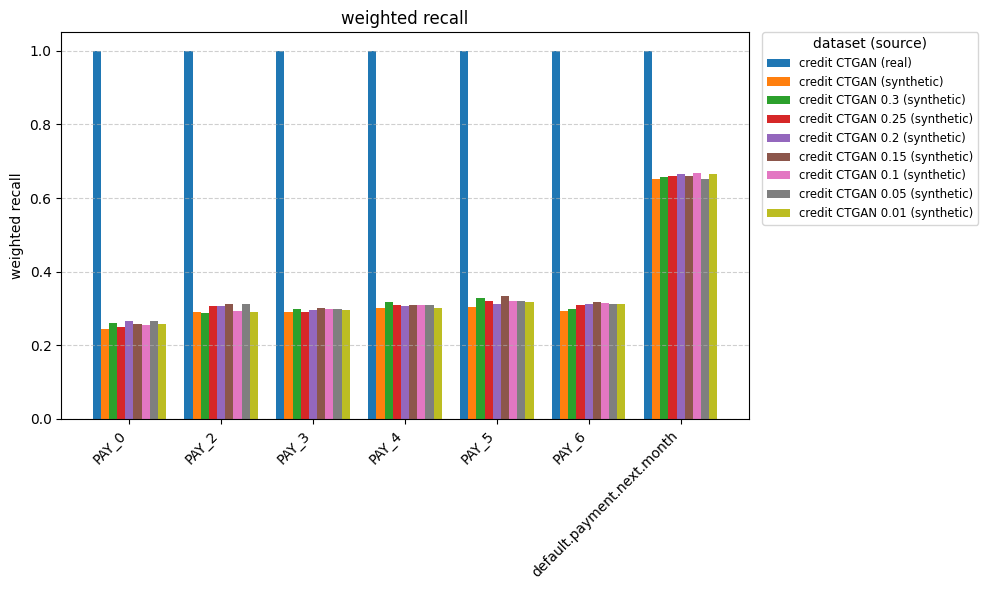

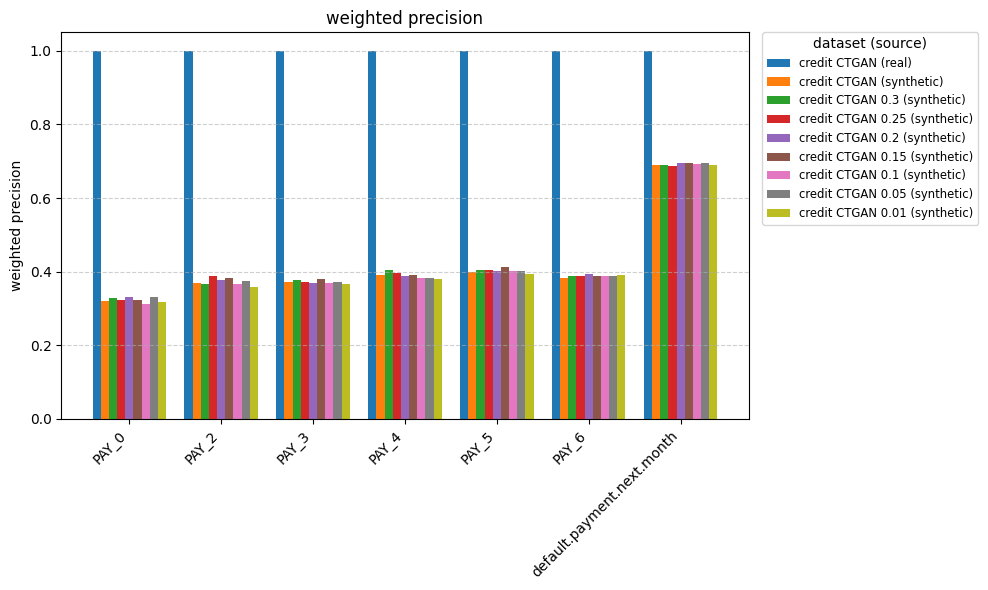

In [26]:
import numpy as np

credit_risk_score = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','default.payment.next.month']

results_classification_credit_ctgan = get_result_classifiaction_over_epsilon(dict_results_credit_ctgan_heom, df_real_credit_card_train, df_real_credit_card_train, cat_list_credit_card, credit_qai_columns, credit_risk_column, credit_risk_score)
print_classification_result(results_classification_credit_ctgan)

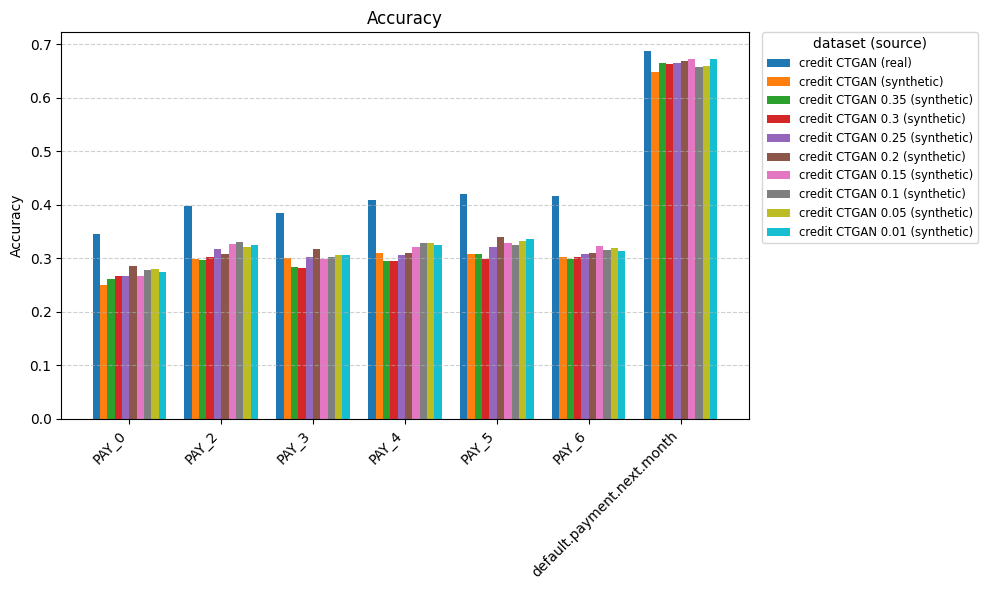

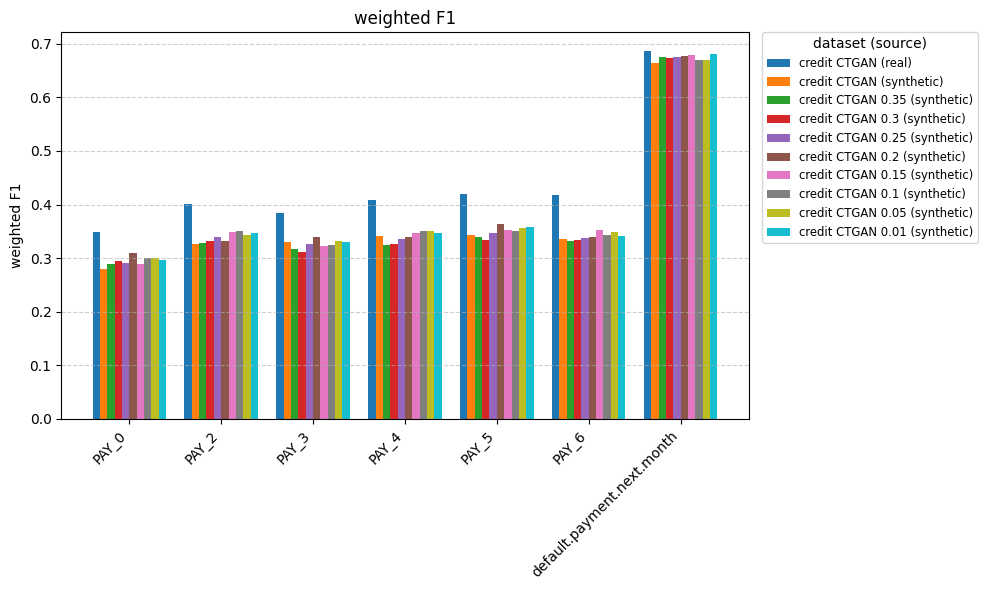

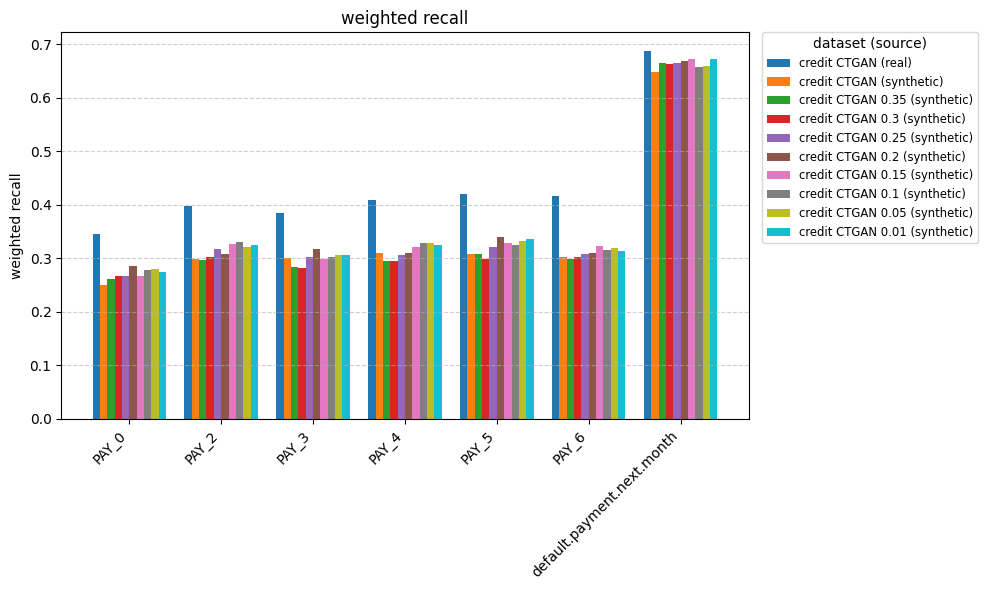

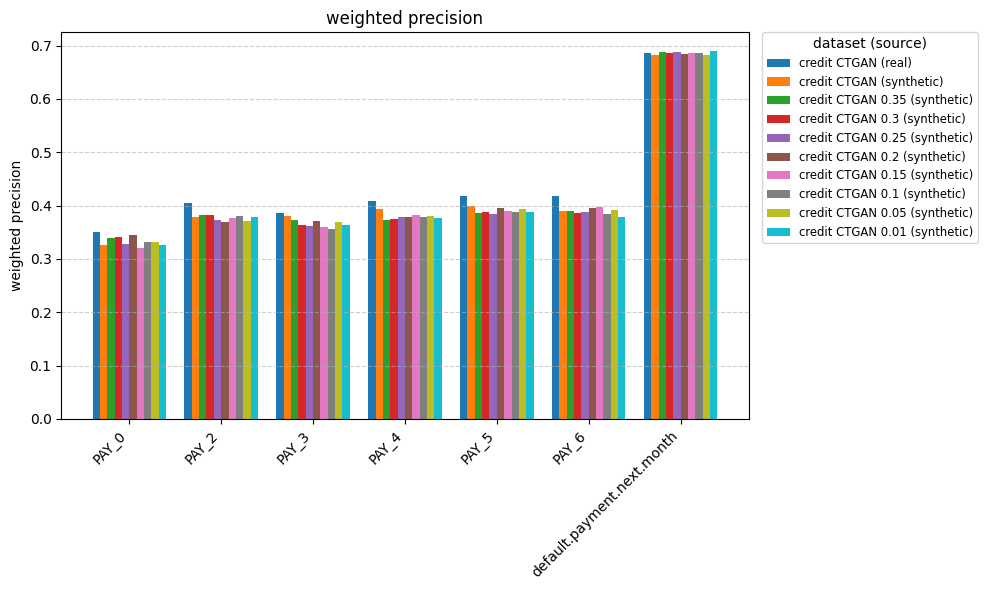

In [23]:
import numpy as np

credit_risk_score = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','default.payment.next.month']

results_classification_credit_ctgan = get_result_classifiaction_over_epsilon(dict_results_credit_ctgan_tabnet, df_real_credit_card_train, df_real_credit_card_test, cat_list_credit_card, credit_qai_columns, credit_risk_column, credit_risk_score)
print_classification_result(results_classification_credit_ctgan)

In [31]:
synth = dict_results_credit_ctgan_tabnet_aiagard['credit CTGAN 0.1']['generation_results']['synthetic_data']
synth = DataLoader(dataset=synth).get_dataframe(cat_list_credit_card, str)
dict_results_credit_ctgan_tabnet_aiagard['credit CTGAN 0.1']['generation_results']['synthetic_data'] = synth

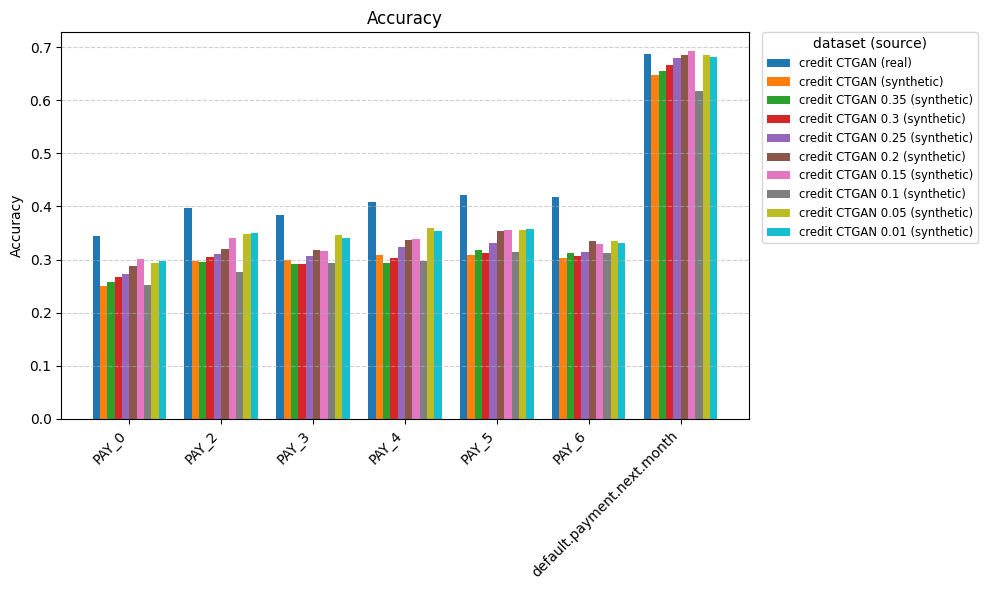

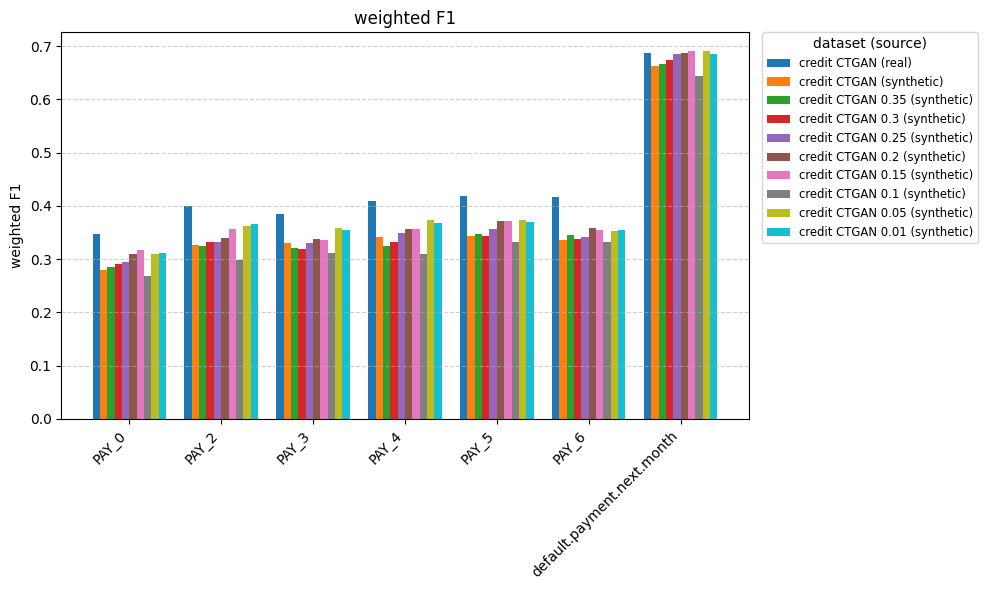

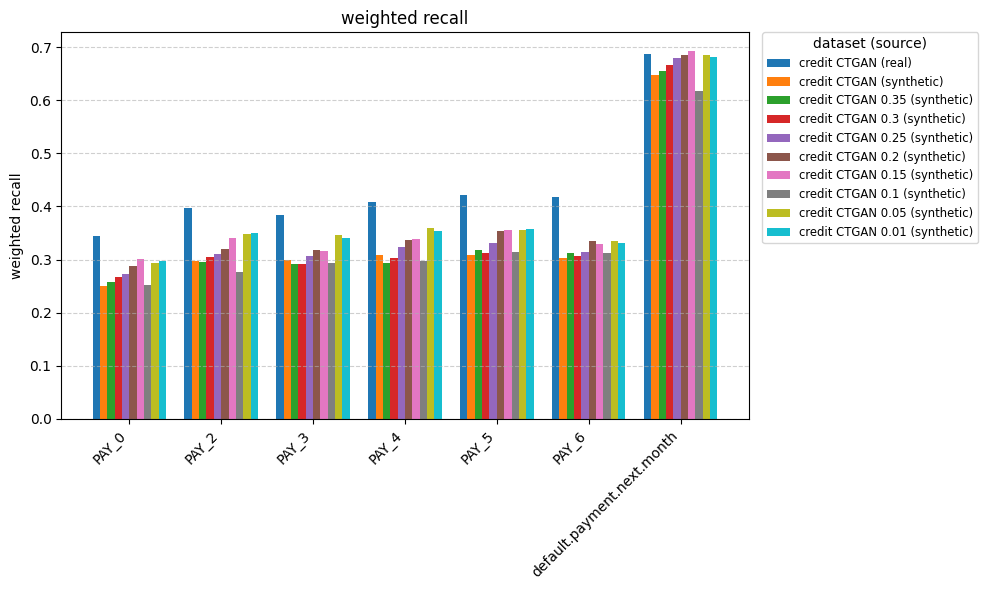

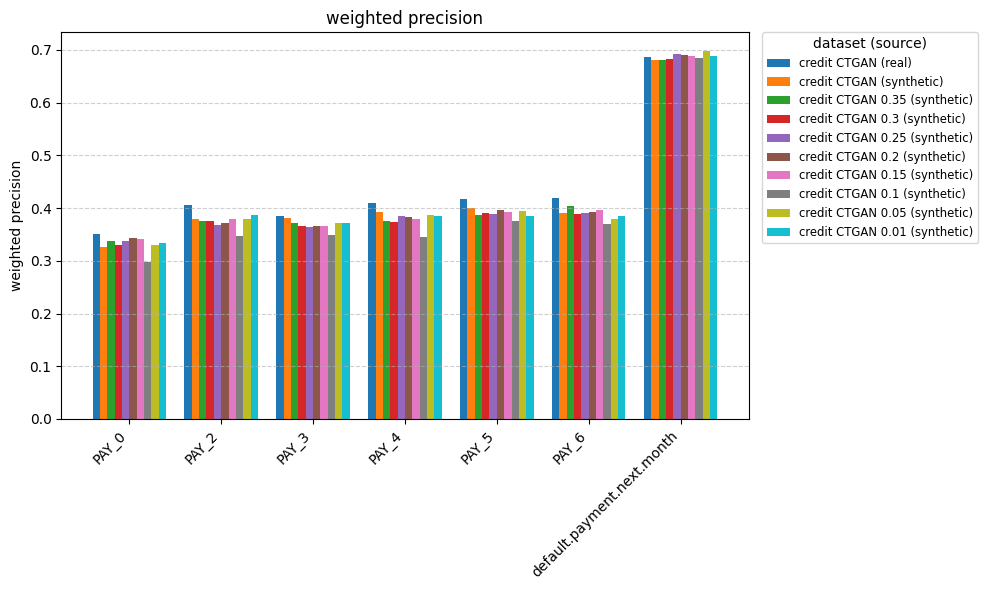

In [33]:
import numpy as np

credit_risk_score = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','default.payment.next.month']

synth = dict_results_credit_ctgan_tabnet_aiagard['credit CTGAN 0.1']['generation_results']['synthetic_data']
synth = DataLoader(dataset=synth).get_dataframe(cat_list_credit_card, str)
dict_results_credit_ctgan_tabnet_aiagard['credit CTGAN 0.1']['generation_results']['synthetic_data'] = synth


results_classification_credit_ctgan = get_result_classifiaction_over_epsilon(dict_results_credit_ctgan_tabnet_aiagard, df_real_credit_card_train, df_real_credit_card_test, cat_list_credit_card, credit_qai_columns, credit_risk_column, credit_risk_score)
print_classification_result(results_classification_credit_ctgan)

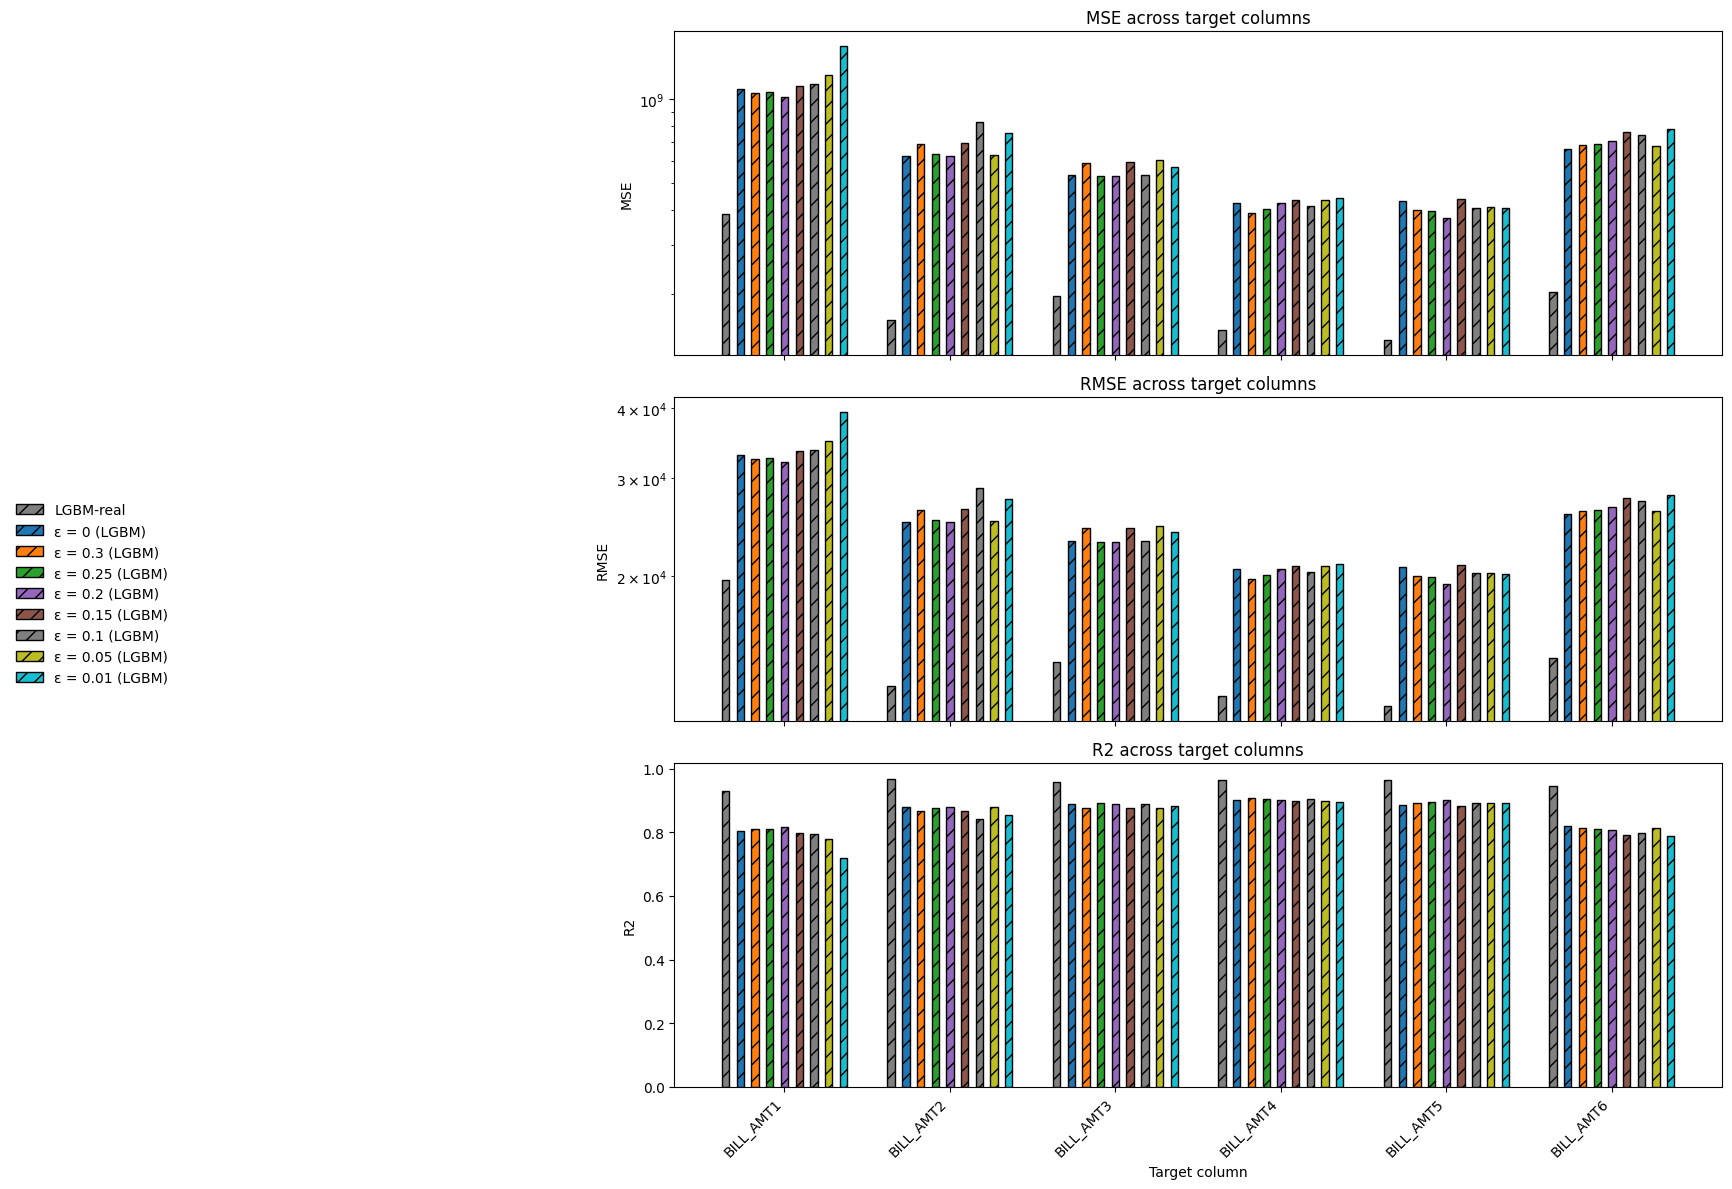

In [41]:
plot_metrics_all_eps(
    cardio_results_multi,   # or whatever variable
    mode="lgbm",            # LightGBM bars only
    order_mode="loose-to-tight",
    yscale="log",
)